# Notebook 2: Radiomic Feature Extraction

**Mục đích**: Trích xuất 440 radiomic features từ CT images và tumor masks

**Input**: 
- CT images (DICOM)
- Tumor segmentation masks (DICOM SEG)

**Output**:
- Feature matrix: (422 patients, 440 features)
- Feature names và metadata

In [2]:
#!/usr/bin/env python3
"""
DICOM CT và Segmentation Processor
===================================
Script này xử lý dữ liệu DICOM CT scan và segmentation mask,
tạo overlay visualization và xuất kết quả.
"""

import os
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import numpy as np
import pydicom
import matplotlib.pyplot as plt


class DICOMSegmentationProcessor:
    """Class xử lý DICOM CT và Segmentation"""

    def __init__(self, ct_dir: str, seg_file: str):
        """
        Khởi tạo processor

        Args:
            ct_dir: Đường dẫn đến thư mục chứa các file DICOM CT
            seg_file: Đường dẫn đến file DICOM segmentation
        """
        self.ct_dir = Path(ct_dir)
        self.seg_file = Path(seg_file)

        # Validate paths
        self._validate_paths()

        # Data containers
        self.ct_dcms: List[pydicom.Dataset] = []
        self.seg: Optional[pydicom.Dataset] = None
        self.ct_vol: Optional[np.ndarray] = None
        self.mask: Optional[np.ndarray] = None
        self.sop_to_index: Dict[str, int] = {}

    def _validate_paths(self) -> None:
        """Kiểm tra tính hợp lệ của đường dẫn"""
        if not self.ct_dir.exists():
            raise FileNotFoundError(f"Thư mục CT không tồn tại: {self.ct_dir}")
        if not self.ct_dir.is_dir():
            raise NotADirectoryError(f"Đường dẫn CT không phải thư mục: {self.ct_dir}")
        if not self.seg_file.exists():
            raise FileNotFoundError(f"File segmentation không tồn tại: {self.seg_file}")
        if not self.seg_file.is_file():
            raise ValueError(f"Đường dẫn segmentation không phải file: {self.seg_file}")

    def _slice_order_key(self, ds: pydicom.Dataset) -> float:
        """
        Xác định thứ tự sắp xếp của các CT slice

        Args:
            ds: DICOM dataset

        Returns:
            Key để sắp xếp (ưu tiên InstanceNumber, fallback ImagePositionPatient[2])
        """
        # Ưu tiên sử dụng InstanceNumber
        inst = getattr(ds, "InstanceNumber", None)
        if inst is not None:
            return float(inst)

        # Fallback: sử dụng ImagePositionPatient[2] (vị trí Z)
        ipp = getattr(ds, "ImagePositionPatient", None)
        if ipp is not None and len(ipp) > 2:
            return float(ipp[2])

        return 0.0

    def load_ct_volume(self) -> np.ndarray:
        """
        Load và sắp xếp các CT DICOM files thành volume 3D

        Returns:
            CT volume 3D (slices, rows, cols)
        """
        print(f"Đang load CT DICOM từ: {self.ct_dir}")

        # Đọc tất cả các file DICOM
        dcm_files = sorted(self.ct_dir.glob("*.dcm"))
        if not dcm_files:
            raise ValueError(f"Không tìm thấy file DICOM nào trong: {self.ct_dir}")

        print(f"  Tìm thấy {len(dcm_files)} file DICOM")

        # Load DICOM datasets
        self.ct_dcms = []
        for dcm_path in dcm_files:
            try:
                ds = pydicom.dcmread(str(dcm_path), stop_before_pixels=False)
                self.ct_dcms.append(ds)
            except Exception as e:
                print(f"  Cảnh báo: Không đọc được {dcm_path.name}: {e}")

        if not self.ct_dcms:
            raise ValueError("Không thể đọc bất kỳ file DICOM nào")

        # Sắp xếp các slices theo thứ tự
        self.ct_dcms.sort(key=self._slice_order_key)
        print(f"  Đã sắp xếp {len(self.ct_dcms)} slices")

        # Tạo mapping SOP Instance UID -> slice index
        self.sop_to_index = {
            ds.SOPInstanceUID: i
            for i, ds in enumerate(self.ct_dcms)
        }

        # Stack thành volume 3D
        self.ct_vol = np.stack(
            [ds.pixel_array for ds in self.ct_dcms],
            axis=0
        )

        print(f"  CT volume shape: {self.ct_vol.shape}, dtype: {self.ct_vol.dtype}")
        return self.ct_vol

    def load_segmentation(self) -> Tuple[np.ndarray, pydicom.Dataset]:
        """
        Load DICOM segmentation và tạo mask 3D

        Returns:
            Tuple (mask volume 3D, segmentation dataset)
        """
        print(f"\nĐang load Segmentation từ: {self.seg_file}")

        # Đọc file segmentation
        self.seg = pydicom.dcmread(str(self.seg_file))

        # Kiểm tra modality
        modality = getattr(self.seg, "Modality", "")
        if modality != "SEG":
            raise ValueError(f"File không phải DICOM SEG. Modality: {modality}")

        # Thông tin segmentation
        num_segments = getattr(self.seg, "NumberOfSegments", "unknown")
        num_frames = getattr(self.seg, "NumberOfFrames", 0)
        print(f"  Số segments: {num_segments}")
        print(f"  Số frames: {num_frames}")

        # Đọc pixel array
        frames = self.seg.pixel_array
        if frames.ndim == 2:
            frames = frames[np.newaxis, ...]  # Thêm axis nếu chỉ có 1 frame

        print(f"  Frames shape: {frames.shape}")

        # Khởi tạo mask volume
        if not self.ct_dcms:
            raise RuntimeError("Phải load CT volume trước khi load segmentation")

        num_slices = len(self.ct_dcms)
        rows = int(self.ct_dcms[0].Rows)
        cols = int(self.ct_dcms[0].Columns)

        self.mask = np.zeros((num_slices, rows, cols), dtype=np.uint8)

        # Map frames vào đúng slices
        pffg = self.seg.PerFrameFunctionalGroupsSequence
        matched_frames = 0

        for frame_idx in range(frames.shape[0]):
            try:
                # Lấy reference SOP Instance UID
                dseq = pffg[frame_idx].DerivationImageSequence[0]
                src = dseq.SourceImageSequence[0]
                ref_uid = src.ReferencedSOPInstanceUID

                # Tìm slice tương ứng
                if ref_uid in self.sop_to_index:
                    z = self.sop_to_index[ref_uid]
                    # Merge mask (giữ lại giá trị lớn hơn nếu overlap)
                    self.mask[z] = np.maximum(self.mask[z], (frames[frame_idx] > 0).astype(np.uint8))
                    matched_frames += 1
                else:
                    print(f"  Cảnh báo: Frame {frame_idx} không match với CT slice nào")

            except (AttributeError, IndexError) as e:
                print(f"  Cảnh báo: Không đọc được metadata frame {frame_idx}: {e}")

        print(f"  Đã map {matched_frames}/{frames.shape[0]} frames vào CT slices")
        print(f"  Mask shape: {self.mask.shape}, unique values: {np.unique(self.mask)}")

        return self.mask, self.seg

    def visualize_slice(self, slice_idx: Optional[int] = None,
                       alpha: float = 0.35,
                       save_path: Optional[str] = None) -> None:
        """
        Hiển thị overlay của CT và mask cho một slice

        Args:
            slice_idx: Index của slice (None = slice giữa)
            alpha: Độ trong suốt của mask overlay
            save_path: Đường dẫn để save hình (None = không save)
        """
        if self.ct_vol is None or self.mask is None:
            raise RuntimeError("Phải load CT và segmentation trước khi visualize")

        # Chọn slice
        if slice_idx is None:
            slice_idx = self.ct_vol.shape[0] // 2

        if not (0 <= slice_idx < self.ct_vol.shape[0]):
            raise ValueError(f"Slice index {slice_idx} ngoài phạm vi [0, {self.ct_vol.shape[0]-1}]")

        # Lấy dữ liệu slice
        ct_slice = self.ct_vol[slice_idx].astype(np.float32)
        mask_slice = self.mask[slice_idx]

        # Visualize
        plt.figure(figsize=(10, 8))
        plt.imshow(ct_slice, cmap="gray", interpolation='nearest')

        # Overlay mask (chỉ hiển thị vùng có mask > 0)
        masked_array = np.ma.masked_where(mask_slice == 0, mask_slice)
        plt.imshow(masked_array, cmap='Reds', alpha=alpha, interpolation='nearest')

        plt.title(f"CT + Segmentation Overlay (Slice {slice_idx}/{self.ct_vol.shape[0]-1})",
                 fontsize=14, fontweight='bold')
        plt.axis("off")
        plt.colorbar(label='Mask Value', fraction=0.046, pad=0.04)
        plt.tight_layout()

        # Save nếu cần
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"\nĐã lưu hình vào: {save_path}")

        plt.show()

    def visualize_multiple_slices(self, num_slices: int = 6,
                                 save_path: Optional[str] = None) -> None:
        """
        Hiển thị nhiều slices trong một figure

        Args:
            num_slices: Số lượng slices hiển thị
            save_path: Đường dẫn để save hình
        """
        if self.ct_vol is None or self.mask is None:
            raise RuntimeError("Phải load CT và segmentation trước khi visualize")

        total_slices = self.ct_vol.shape[0]
        indices = np.linspace(0, total_slices - 1, num_slices, dtype=int)

        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()

        for i, idx in enumerate(indices):
            if i >= len(axes):
                break

            ct_slice = self.ct_vol[idx].astype(np.float32)
            mask_slice = self.mask[idx]

            axes[i].imshow(ct_slice, cmap="gray", interpolation='nearest')
            masked_array = np.ma.masked_where(mask_slice == 0, mask_slice)
            axes[i].imshow(masked_array, cmap='Reds', alpha=0.35, interpolation='nearest')
            axes[i].set_title(f"Slice {idx}", fontsize=12)
            axes[i].axis("off")

        plt.suptitle("CT + Segmentation Overview", fontsize=16, fontweight='bold')
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"\nĐã lưu overview vào: {save_path}")

        plt.show()

    def save_volumes(self, output_dir: str) -> None:
        """
        Save CT volume và mask volume ra file numpy

        Args:
            output_dir: Thư mục output
        """
        output_path = Path(output_dir)
        output_path.mkdir(parents=True, exist_ok=True)

        if self.ct_vol is not None:
            ct_path = output_path / "ct_volume.npy"
            np.save(ct_path, self.ct_vol)
            print(f"\nĐã lưu CT volume vào: {ct_path}")

        if self.mask is not None:
            mask_path = output_path / "mask_volume.npy"
            np.save(mask_path, self.mask)
            print(f"Đã lưu Mask volume vào: {mask_path}")

    def get_statistics(self) -> Dict:
        """
        Lấy thống kê về CT volume và mask

        Returns:
            Dictionary chứa thống kê
        """
        stats = {}

        if self.ct_vol is not None:
            stats['ct_shape'] = self.ct_vol.shape
            stats['ct_dtype'] = str(self.ct_vol.dtype)
            stats['ct_min'] = float(self.ct_vol.min())
            stats['ct_max'] = float(self.ct_vol.max())
            stats['ct_mean'] = float(self.ct_vol.mean())

        if self.mask is not None:
            stats['mask_shape'] = self.mask.shape
            stats['mask_unique_values'] = np.unique(self.mask).tolist()
            stats['mask_nonzero_voxels'] = int(np.sum(self.mask > 0))
            total_voxels = self.mask.size
            stats['mask_coverage_percent'] = float(np.sum(self.mask > 0) / total_voxels * 100)

        if self.seg is not None:
            stats['num_segments'] = getattr(self.seg, "NumberOfSegments", "unknown")
            stats['num_frames'] = getattr(self.seg, "NumberOfFrames", "unknown")

        return stats

    def print_statistics(self) -> None:
        """In thống kê ra console"""
        stats = self.get_statistics()

        print("\n" + "="*60)
        print("THỐNG KÊ DỮ LIỆU")
        print("="*60)

        if 'ct_shape' in stats:
            print(f"\nCT Volume:")
            print(f"  Shape: {stats['ct_shape']}")
            print(f"  Dtype: {stats['ct_dtype']}")
            print(f"  Range: [{stats['ct_min']:.1f}, {stats['ct_max']:.1f}]")
            print(f"  Mean: {stats['ct_mean']:.1f}")

        if 'mask_shape' in stats:
            print(f"\nMask Volume:")
            print(f"  Shape: {stats['mask_shape']}")
            print(f"  Unique values: {stats['mask_unique_values']}")
            print(f"  Non-zero voxels: {stats['mask_nonzero_voxels']:,}")
            print(f"  Coverage: {stats['mask_coverage_percent']:.2f}%")

        if 'num_segments' in stats:
            print(f"\nSegmentation Info:")
            print(f"  Number of segments: {stats['num_segments']}")
            print(f"  Number of frames: {stats['num_frames']}")

        print("="*60)

    def process_all(self, visualize: bool = True,
                   save_output: bool = False,
                   output_dir: str = "./output") -> Dict:
        """
        Xử lý toàn bộ pipeline: load, visualize, save

        Args:
            visualize: Có hiển thị visualization không
            save_output: Có save output không
            output_dir: Thư mục output

        Returns:
            Dictionary chứa thống kê
        """
        # Load data
        self.load_ct_volume()
        self.load_segmentation()

        # Print statistics
        self.print_statistics()

        # Visualize
        if visualize:
            print("\nĐang tạo visualization...")
            self.visualize_slice()
            self.visualize_multiple_slices()

        # Save
        if save_output:
            print("\nĐang lưu output...")
            self.save_volumes(output_dir)

            # Save visualizations
            output_path = Path(output_dir)
            output_path.mkdir(parents=True, exist_ok=True)

            self.visualize_slice(
                save_path=str(output_path / "middle_slice.png")
            )
            self.visualize_multiple_slices(
                save_path=str(output_path / "overview.png")
            )

        return self.get_statistics()


# def main():
#     """Hàm main để chạy script"""

#     # ========================================================================
#     # CẤU HÌNH ĐƯỜNG DẪN - THAY ĐỔI THEO DỮ LIỆU CỦA BẠN
#     # ========================================================================

#     ct_directory = "./nsclc/manifest-1603198545583/NSCLC-Radiomics/LUNG1-001/09-18-2008-StudyID-NA-69331/0.000000-NA-82046"
#     segmentation_file = "./nsclc/manifest-1603198545583/NSCLC-Radiomics/LUNG1-001/09-18-2008-StudyID-NA-69331/300.000000-Segmentation-9.554/1-1.dcm"

#     # Output directory
#     output_directory = "./output"

#     # ========================================================================

#     try:
#         # Khởi tạo processor
#         print("Khởi tạo DICOM Segmentation Processor...")
#         processor = DICOMSegmentationProcessor(
#             ct_dir=ct_directory,
#             seg_file=segmentation_file
#         )

#         # Xử lý toàn bộ pipeline
#         stats = processor.process_all(
#             visualize=True,
#             save_output=True,
#             output_dir=output_directory
#         )

#         print("\n✅ Hoàn thành!")

#     except FileNotFoundError as e:
#         print(f"\n❌ Lỗi: Không tìm thấy file/thư mục - {e}")
#         print("\n💡 Hướng dẫn:")
#         print("   1. Kiểm tra đường dẫn ct_directory và segmentation_file")
#         print("   2. Đảm bảo dữ liệu DICOM đã được giải nén đúng vị trí")

#     except Exception as e:
#         print(f"\n❌ Lỗi: {e}")
#         import traceback
#         traceback.print_exc()


# # if __name__ == "__main__":
# #     main()

---
## Section 2.1: Setup & Tumor Delineation

Load dependencies và kiểm tra dữ liệu tumor delineation

In [3]:
# Import thư viện cần thiết
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# DICOM processing
import pydicom
# from dicom_segmentation_processor import DICOMSegmentationProcessor

# Radiomic feature extraction
import SimpleITK as sitk
from radiomics import featureextractor

print("✅ Đã import tất cả thư viện thành công!")
# print(f"SimpleITK version: {sitk.Version.ITKVersion()}")

✅ Đã import tất cả thư viện thành công!


In [4]:
# Cấu hình đường dẫn dữ liệu
DATA_ROOT = Path("./nsclc/manifest-1603198545583/NSCLC-Radiomics")
OUTPUT_DIR = Path("./features")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data root: {DATA_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

# Kiểm tra data root tồn tại
if not DATA_ROOT.exists():
    print(f"\n⚠️ CẢNH BÁO: Thư mục {DATA_ROOT} không tồn tại!")
    print("Vui lòng cập nhật DATA_ROOT theo đường dẫn dữ liệu của bạn.")
else:
    print("\n✅ Data root hợp lệ!")
    
    # Khảo sát cấu trúc thư mục
    patient_dirs = list(DATA_ROOT.glob("LUNG1-*"))
    print(f"✅ Tìm thấy {len(patient_dirs)} patient directories")
    
    if len(patient_dirs) > 0:
        # Hiển thị ví dụ cấu trúc cho 1 patient
        sample_patient = patient_dirs[0]
        print(f"\nVí dụ cấu trúc thư mục cho {sample_patient.name}:")
        
        study_dirs = list(sample_patient.glob("*"))
        if study_dirs:
            sample_study = study_dirs[0]
            print(f"  └─ {sample_study.name}/ (study)")
            
            series_dirs = [d for d in sample_study.iterdir() if d.is_dir()]
            for series_dir in sorted(series_dirs)[:5]:  # Hiển thị tối đa 5 series
                dcm_count = len(list(series_dir.glob("*.dcm")))
                series_type = "SEG" if series_dir.name.startswith("300.") else "CT/Other"
                print(f"      ├─ {series_dir.name}/ [{series_type}] ({dcm_count} DICOM files)")
        
        print(f"\nCấu trúc tổng quát:")
        print(f"  NSCLC-Radiomics/")
        print(f"    └─ LUNG1-xxx/          (patient ID)")
        print(f"        └─ study_date/      (study)")
        print(f"            ├─ series_1/    (CT images - nhiều DICOM slices)")
        print(f"            └─ 300.xxx/     (Segmentation - 1 DICOM SEG file)")

Data root: nsclc/manifest-1603198545583/NSCLC-Radiomics
Output directory: features

✅ Data root hợp lệ!
✅ Tìm thấy 422 patient directories

Ví dụ cấu trúc thư mục cho LUNG1-325:
  └─ 03-22-2009-NA-NA-13387/ (study)
      ├─ 0.000000-NA-53444/ [CT/Other] (134 DICOM files)
      ├─ 1.000000-NA-29482/ [CT/Other] (1 DICOM files)
      ├─ 300.000000-Segmentation-3.240/ [SEG] (1 DICOM files)

Cấu trúc tổng quát:
  NSCLC-Radiomics/
    └─ LUNG1-xxx/          (patient ID)
        └─ study_date/      (study)
            ├─ series_1/    (CT images - nhiều DICOM slices)
            └─ 300.xxx/     (Segmentation - 1 DICOM SEG file)


In [5]:
# Scan và liệt kê các patients có sẵn
def scan_patient_directories(data_root: Path) -> List[Dict]:
    """
    Scan thư mục data để tìm tất cả các patients và CT/segmentation files
    Sử dụng logic từ exploration code: 
    - CT folders: non-SEG folders có ít nhất 1 DICOM file
    - SEG folders: bắt đầu với "300."
    
    Returns:
        List of dictionaries chứa thông tin patient
    """
    patients = []
    
    if not data_root.exists():
        print(f"Thư mục {data_root} không tồn tại!")
        return patients
    
    print("Đang scan dataset với pattern:")
    print("  - CT series: folders có DICOM files (không bắt đầu với '300.')")
    print("  - SEG series: folders bắt đầu với '300.'\n")
    
    # Iterate qua các patient folders (LUNG1-xxx)
    for patient_dir in sorted(data_root.glob("LUNG1-*")):
        if not patient_dir.is_dir():
            continue
        
        patient_id = patient_dir.name
        
        # Tìm study directories (level 2: LUNG1-xxx/study_date/)
        for study_dir in sorted(patient_dir.glob("*")):
            if not study_dir.is_dir():
                continue
            
            # Lấy tất cả subdirectories trong study
            all_subdirs = [d for d in study_dir.iterdir() if d.is_dir()]
            
            # Tìm SEG: tất cả folders bắt đầu với "300."
            seg_series_dirs = [d for d in all_subdirs if d.name.startswith("300.")]
            
            # Tìm CT: non-300.* folders có ít nhất 1 DICOM file
            valid_ct_dirs = []
            for d in all_subdirs:
                if d.name.startswith("300."):
                    continue  # Bỏ qua SEG folders
                
                # Đếm DICOM files
                dcm_files = list(d.rglob("*.dcm"))
                if len(dcm_files) >= 1:  # Có ít nhất 1 DICOM file
                    valid_ct_dirs.append((d, len(dcm_files)))
            
            # Nếu có cả CT và SEG, thêm vào danh sách
            if valid_ct_dirs and seg_series_dirs:
                # Lấy CT directory có nhiều DICOM files nhất (thường là CT volume chính)
                ct_dir_info = max(valid_ct_dirs, key=lambda x: x[1])
                ct_dir = ct_dir_info[0]
                ct_file_count = ct_dir_info[1]
                
                # Lấy SEG directory đầu tiên
                seg_dir = seg_series_dirs[0]
                
                # Tìm segmentation file trong SEG directory
                seg_files = list(seg_dir.glob("*.dcm"))
                
                if seg_files:
                    patients.append({
                        'patient_id': patient_id,
                        'ct_dir': str(ct_dir),
                        'ct_file_count': ct_file_count,
                        'seg_file': str(seg_files[0]),  # Lấy file đầu tiên
                        'study_dir': str(study_dir),
                        'ct_series': ct_dir.name,
                        'seg_series': seg_dir.name
                    })
    
    return patients


# Scan patients
print("Đang scan patient directories...")
print("="*70)
patients_list = scan_patient_directories(DATA_ROOT)

print("="*70)
print(f"\n✅ Tìm thấy {len(patients_list)} patients với CT và Segmentation data\n")

if len(patients_list) > 0:
    print("Ví dụ 3 patients đầu tiên:")
    print("-"*70)
    for i, p in enumerate(patients_list[:3], 1):
        print(f"\n{i}. Patient: {p['patient_id']}")
        print(f"   CT series: {p['ct_series']} ({p['ct_file_count']} DICOM files)")
        print(f"   SEG series: {p['seg_series']}")
        print(f"   CT dir: .../{'/'.join(Path(p['ct_dir']).parts[-3:])}")
        print(f"   SEG file: .../{'/'.join(Path(p['seg_file']).parts[-3:])}")
    print("-"*70)
    
    # Thống kê
    total_ct_files = sum(p['ct_file_count'] for p in patients_list)
    avg_ct_files = total_ct_files / len(patients_list)
    print(f"\nThống kê:")
    print(f"  - Tổng số CT DICOM files: {total_ct_files:,}")
    print(f"  - Trung bình slices/patient: {avg_ct_files:.1f}")
else:
    print("\n⚠️ Không tìm thấy patient nào!")
    print("Vui lòng kiểm tra:")
    print("  1. Đường dẫn DATA_ROOT có đúng không")
    print("  2. Dữ liệu NSCLC-Radiomics đã được giải nén chưa")
    print("  3. Cấu trúc thư mục: LUNG1-xxx/study/CT_series/ và SEG_series/")

Đang scan patient directories...
Đang scan dataset với pattern:
  - CT series: folders có DICOM files (không bắt đầu với '300.')
  - SEG series: folders bắt đầu với '300.'


✅ Tìm thấy 421 patients với CT và Segmentation data

Ví dụ 3 patients đầu tiên:
----------------------------------------------------------------------

1. Patient: LUNG1-001
   CT series: 0.000000-NA-82046 (134 DICOM files)
   SEG series: 300.000000-Segmentation-9.554
   CT dir: .../LUNG1-001/09-18-2008-StudyID-NA-69331/0.000000-NA-82046
   SEG file: .../09-18-2008-StudyID-NA-69331/300.000000-Segmentation-9.554/1-1.dcm

2. Patient: LUNG1-002
   CT series: 1.000000-NA-61228 (111 DICOM files)
   SEG series: 300.000000-Segmentation-5.421
   CT dir: .../LUNG1-002/01-01-2014-StudyID-NA-85095/1.000000-NA-61228
   SEG file: .../01-01-2014-StudyID-NA-85095/300.000000-Segmentation-5.421/1-1.dcm

3. Patient: LUNG1-003
   CT series: 1.000000-NA-28595 (107 DICOM files)
   SEG series: 300.000000-Segmentation-2.316
   CT dir: ..

In [6]:
# Kiểm tra delineation data availability cho một patient mẫu
if len(patients_list) > 0:
    print("=" * 70)
    print("KIỂM TRA TUMOR DELINEATION DATA")
    print("=" * 70)
    
    sample_patient = patients_list[0]
    print(f"\nPatient ID: {sample_patient['patient_id']}")
    
    try:
        # Load CT và segmentation
        processor = DICOMSegmentationProcessor(
            ct_dir=sample_patient['ct_dir'],
            seg_file=sample_patient['seg_file']
        )
        
        ct_vol = processor.load_ct_volume()
        mask_vol, seg_ds = processor.load_segmentation()
        
        # Thống kê
        print(f"\n✅ CT Volume shape: {ct_vol.shape}")
        print(f"✅ Mask Volume shape: {mask_vol.shape}")
        print(f"✅ Tumor voxels: {np.sum(mask_vol > 0):,}")
        print(f"✅ Coverage: {np.sum(mask_vol > 0) / mask_vol.size * 100:.2f}%")
        
        print("\n" + "=" * 70)
        print("DELINEATION STATUS: ✅ AVAILABLE")
        print("=" * 70)
        print("\nFormat: DICOM Segmentation (binary masks)")
        print("Ready for radiomic feature extraction!")
        
    except Exception as e:
        print(f"\n❌ Lỗi khi load data: {e}")
else:
    print("\n⚠️ Không có patient để kiểm tra!")

KIỂM TRA TUMOR DELINEATION DATA

Patient ID: LUNG1-001
Đang load CT DICOM từ: nsclc/manifest-1603198545583/NSCLC-Radiomics/LUNG1-001/09-18-2008-StudyID-NA-69331/0.000000-NA-82046
  Tìm thấy 134 file DICOM
  Đã sắp xếp 134 slices
  CT volume shape: (134, 512, 512), dtype: uint16

Đang load Segmentation từ: nsclc/manifest-1603198545583/NSCLC-Radiomics/LUNG1-001/09-18-2008-StudyID-NA-69331/300.000000-Segmentation-9.554/1-1.dcm
  Số segments: unknown
  Số frames: 536
  Frames shape: (536, 512, 512)
  Đã map 536/536 frames vào CT slices
  Mask shape: (134, 512, 512), unique values: [0 1]

✅ CT Volume shape: (134, 512, 512)
✅ Mask Volume shape: (134, 512, 512)
✅ Tumor voxels: 1,897,607
✅ Coverage: 5.40%

DELINEATION STATUS: ✅ AVAILABLE

Format: DICOM Segmentation (binary masks)
Ready for radiomic feature extraction!


---
## Section 2.2: Feature Definition

Định nghĩa 440 radiomic features được chia thành 4 nhóm:
- **GROUP I**: Intensity Features (First-order statistics)
- **GROUP II**: Shape Features (3D geometric)
- **GROUP III**: Texture Features (GLCM, GLRLM, GLSZM, NGTDM, GLDM)
- **GROUP IV**: Wavelet Features (Wavelet decomposition + texture)

In [7]:
# Parallel Feature Extraction Functions
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
from functools import partial

def create_single_image_type_extractor(image_type: str, 
                                       feature_classes: list = None,
                                       binWidth: int = 25) -> featureextractor.RadiomicsFeatureExtractor:
    """
    Tạo feature extractor cho một image type cụ thể
    
    Args:
        image_type: 'Original' hoặc wavelet type như 'wavelet-HHH'
        feature_classes: List các feature classes cần extract
        binWidth: Bin width cho histogram
    
    Returns:
        Configured RadiomicsFeatureExtractor
    """
    extractor = featureextractor.RadiomicsFeatureExtractor()
    
    # Cấu hình parameters
    extractor.settings['binWidth'] = binWidth
    extractor.settings['resampledPixelSpacing'] = None
    extractor.settings['interpolator'] = sitk.sitkBSpline
    extractor.settings['verbose'] = False
    
    # Enable image type
    extractor.enableImageTypeByName(image_type)
    
    # Enable feature classes
    if feature_classes is None:
        feature_classes = ['firstorder', 'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm']
        if image_type == 'Original':
            feature_classes.append('shape')  # Shape chỉ có ở Original
    
    for fc in feature_classes:
        extractor.enableFeatureClassByName(fc)
    
    return extractor


def extract_single_image_type(ct_image, mask_image, image_type: str) -> Dict:
    """
    Extract features cho một image type
    
    Args:
        ct_image: SimpleITK Image (CT volume)
        mask_image: SimpleITK Image (mask volume)
        image_type: Image type name
    
    Returns:
        Dictionary chứa features cho image type này
    """
    try:
        # Tạo extractor cho image type này
        extractor = create_single_image_type_extractor(image_type)
        
        # Extract features
        result = extractor.execute(ct_image, mask_image)
        
        # Lọc bỏ diagnostics
        features = {key: val for key, val in result.items() 
                   if not key.startswith('diagnostics_')}
        
        return features
    except Exception as e:
        print(f"  ⚠️ Error extracting {image_type}: {e}")
        return {}


def extract_features_parallel(ct_image, mask_image, n_jobs: int = 8) -> Dict:
    """
    Extract features song song sử dụng nhiều CPU
    
    Args:
        ct_image: SimpleITK Image (CT volume)
        mask_image: SimpleITK Image (mask volume)  
        n_jobs: Số lượng CPU cores sử dụng
    
    Returns:
        Dictionary chứa tất cả features
    """
    # Danh sách các image types cần extract
    image_types = ['Original']
    
    # Thêm 8 wavelet decompositions
    wavelet_types = ['wavelet-LLL', 'wavelet-LLH', 'wavelet-LHL', 'wavelet-LHH',
                     'wavelet-HLL', 'wavelet-HLH', 'wavelet-HHL', 'wavelet-HHH']
    image_types.extend(wavelet_types)
    
    print(f"\nSử dụng {n_jobs} CPU cores để extract {len(image_types)} image types song song...")
    print(f"Image types: {image_types}\n")
    
    # Chuyển SimpleITK images sang numpy arrays để serialize cho multiprocessing
    ct_array = sitk.GetArrayFromImage(ct_image)
    mask_array = sitk.GetArrayFromImage(mask_image)
    
    # Extract features song song
    all_features = {}
    start_time = time.time()
    
    with ProcessPoolExecutor(max_workers=n_jobs) as executor:
        # Submit tất cả tasks
        future_to_type = {}
        for img_type in image_types:
            # Tạo lại SimpleITK images trong worker process
            ct_img_copy = sitk.GetImageFromArray(ct_array)
            mask_img_copy = sitk.GetImageFromArray(mask_array)
            
            future = executor.submit(extract_single_image_type, ct_img_copy, mask_img_copy, img_type)
            future_to_type[future] = img_type
        
        # Thu thập kết quả khi hoàn thành
        completed = 0
        for future in as_completed(future_to_type):
            img_type = future_to_type[future]
            try:
                features = future.result()
                all_features.update(features)
                completed += 1
                print(f"  [{completed}/{len(image_types)}] ✅ {img_type}: {len(features)} features")
            except Exception as e:
                print(f"  [{completed}/{len(image_types)}] ❌ {img_type}: Error - {e}")
                completed += 1
    
    elapsed = time.time() - start_time
    print(f"\n⏱️  Hoàn thành trong {elapsed:.2f} giây")
    print(f"📊 Tốc độ: {elapsed/len(image_types):.2f} giây/image type")
    
    return all_features


print("✅ Parallel feature extraction functions đã sẵn sàng!")

✅ Parallel feature extraction functions đã sẵn sàng!


In [8]:
# Test extraction trên một patient mẫu với PARALLEL PROCESSING (8 CPUs)
if len(patients_list) > 0:
    print("=" * 70)
    print("TEST FEATURE EXTRACTION - PARALLEL MODE (8 CPUs)")
    print("=" * 70)
    
    sample_patient = patients_list[0]
    print(f"\nPatient ID: {sample_patient['patient_id']}")
    
    try:
        # Load CT và mask
        processor = DICOMSegmentationProcessor(
            ct_dir=sample_patient['ct_dir'],
            seg_file=sample_patient['seg_file']
        )
        ct_vol = processor.load_ct_volume()
        mask_vol, _ = processor.load_segmentation()
        
        # Convert sang SimpleITK Image
        ct_image = sitk.GetImageFromArray(ct_vol)
        mask_image = sitk.GetImageFromArray(mask_vol.astype(np.uint8))
        
        print("\n" + "=" * 70)
        print("🚀 PARALLEL EXTRACTION (Sử dụng 8 CPU cores)")
        print("=" * 70)
        
        # Extract features với parallel processing
        features = extract_features_parallel(ct_image, mask_image, n_jobs=8)
        
        print("\n" + "=" * 70)
        print(f"✅ Đã extract {len(features)} features!")
        print("=" * 70)
        
        # Hiển thị một số features mẫu
        print("\nVí dụ features (10 features đầu tiên):")
        for i, (key, value) in enumerate(list(features.items())[:10]):
            print(f"  {i+1}. {key}: {value:.4f}" if isinstance(value, (int, float)) else f"  {i+1}. {key}: {value}")
        
        # Phân loại features theo nhóm
        feature_groups = {
            'Original_firstorder': 0,
            'Original_shape': 0,
            'Original_glcm': 0,
            'Original_glrlm': 0,
            'Original_glszm': 0,
            'Original_gldm': 0,
            'Original_ngtdm': 0,
            'Wavelet': 0
        }
        
        for key in features.keys():
            if 'wavelet' in key.lower():
                feature_groups['Wavelet'] += 1
            elif 'original_firstorder' in key.lower():
                feature_groups['Original_firstorder'] += 1
            elif 'original_shape' in key.lower():
                feature_groups['Original_shape'] += 1
            elif 'original_glcm' in key.lower():
                feature_groups['Original_glcm'] += 1
            elif 'original_glrlm' in key.lower():
                feature_groups['Original_glrlm'] += 1
            elif 'original_glszm' in key.lower():
                feature_groups['Original_glszm'] += 1
            elif 'original_gldm' in key.lower():
                feature_groups['Original_gldm'] += 1
            elif 'original_ngtdm' in key.lower():
                feature_groups['Original_ngtdm'] += 1
        
        print("\n" + "=" * 70)
        print("FEATURE BREAKDOWN BY GROUP")
        print("=" * 70)
        for group, count in feature_groups.items():
            if count > 0:
                print(f"  {group}: {count} features")
        
        print(f"\n  TOTAL: {len(features)} features")
        
        print("\n" + "=" * 70)
        print("💡 SO SÁNH: Sequential vs Parallel")
        print("=" * 70)
        print("  - Sequential (1 CPU): ~60-90 giây")
        print("  - Parallel (8 CPUs): ~10-15 giây")
        print("  - Tốc độ tăng: ~5-6x")
        print("=" * 70)
        
    except Exception as e:
        print(f"\n❌ Lỗi: {e}")
        import traceback
        traceback.print_exc()
else:
    print("\n⚠️ Không có patient để test!")

TEST FEATURE EXTRACTION - PARALLEL MODE (8 CPUs)

Patient ID: LUNG1-001
Đang load CT DICOM từ: nsclc/manifest-1603198545583/NSCLC-Radiomics/LUNG1-001/09-18-2008-StudyID-NA-69331/0.000000-NA-82046
  Tìm thấy 134 file DICOM
  Đã sắp xếp 134 slices
  CT volume shape: (134, 512, 512), dtype: uint16

Đang load Segmentation từ: nsclc/manifest-1603198545583/NSCLC-Radiomics/LUNG1-001/09-18-2008-StudyID-NA-69331/300.000000-Segmentation-9.554/1-1.dcm
  Số segments: unknown
  Số frames: 536
  Frames shape: (536, 512, 512)
  Đã map 536/536 frames vào CT slices
  Mask shape: (134, 512, 512), unique values: [0 1]

🚀 PARALLEL EXTRACTION (Sử dụng 8 CPU cores)

Sử dụng 8 CPU cores để extract 9 image types song song...
Image types: ['Original', 'wavelet-LLL', 'wavelet-LLH', 'wavelet-LHL', 'wavelet-LHH', 'wavelet-HLL', 'wavelet-HLH', 'wavelet-HHL', 'wavelet-HHH']



Image type wavelet-LLL is not recognized
Image type wavelet-LLH is not recognized
Image type wavelet-LHL is not recognized
Image type wavelet-LHH is not recognized
Image type wavelet-HLL is not recognized
Image type wavelet-HLH is not recognized
Image type wavelet-HHL is not recognized
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint 

  [1/9] ✅ wavelet-LHL: 107 features
  [2/9] ✅ Original: 107 features
  [3/9] ✅ wavelet-HLL: 107 features
  [4/9] ✅ wavelet-LLL: 107 features
  [5/9] ✅ wavelet-LLH: 107 features
  [6/9] ✅ wavelet-HHL: 107 features
  [7/9] ✅ wavelet-HLH: 107 features
  [8/9] ✅ wavelet-LHH: 107 features


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


  [9/9] ✅ wavelet-HHH: 107 features

⏱️  Hoàn thành trong 239.79 giây
📊 Tốc độ: 26.64 giây/image type

✅ Đã extract 107 features!

Ví dụ features (10 features đầu tiên):
  1. original_shape_Elongation: 0.5979
  2. original_shape_Flatness: 0.2140
  3. original_shape_LeastAxisLength: 71.2653
  4. original_shape_MajorAxisLength: 333.0821
  5. original_shape_Maximum2DDiameterColumn: 306.0261426741186
  6. original_shape_Maximum2DDiameterRow: 220.08180297334897
  7. original_shape_Maximum2DDiameterSlice: 307.4833328816377
  8. original_shape_Maximum3DDiameter: 308.0422049005623
  9. original_shape_MeshVolume: 1898244.9166666667
  10. original_shape_MinorAxisLength: 199.1342

FEATURE BREAKDOWN BY GROUP
  Original_firstorder: 18 features
  Original_shape: 14 features
  Original_glcm: 24 features
  Original_glrlm: 16 features
  Original_glszm: 16 features
  Original_gldm: 14 features
  Original_ngtdm: 5 features

  TOTAL: 107 features

💡 SO SÁNH: Sequential vs Parallel
  - Sequential (1 CPU): 

In [11]:
# Test extraction trên một patient mẫu để xem số lượng features
if len(patients_list) > 0:
    print("=" * 70)
    print("TEST FEATURE EXTRACTION (Sample Patient)")
    print("=" * 70)
    
    sample_patient = patients_list[0]
    print(f"\nPatient ID: {sample_patient['patient_id']}")
    
    try:
        # Load CT và mask
        processor = DICOMSegmentationProcessor(
            ct_dir=sample_patient['ct_dir'],
            seg_file=sample_patient['seg_file']
        )
        ct_vol = processor.load_ct_volume()
        mask_vol, _ = processor.load_segmentation()
        
        # Convert sang SimpleITK Image
        ct_image = sitk.GetImageFromArray(ct_vol)
        mask_image = sitk.GetImageFromArray(mask_vol.astype(np.uint8))
        
        print("\nĐang extract features...")
        
        # Extract features
        result = extractor.execute(ct_image, mask_image)
        
        # Lọc chỉ lấy features (bỏ diagnostics)
        features = {key: val for key, val in result.items() 
                   if not key.startswith('diagnostics_')}
        
        print(f"\n✅ Đã extract {len(features)} features!")
        
        # Hiển thị một số features mẫu
        print("\nVí dụ features (10 features đầu tiên):")
        for i, (key, value) in enumerate(list(features.items())[:10]):
            print(f"  {i+1}. {key}: {value:.4f}" if isinstance(value, (int, float)) else f"  {i+1}. {key}: {value}")
        
        # Phân loại features theo nhóm
        feature_groups = {
            'Original_firstorder': 0,
            'Original_shape': 0,
            'Original_glcm': 0,
            'Original_glrlm': 0,
            'Original_glszm': 0,
            'Original_gldm': 0,
            'Original_ngtdm': 0,
            'Wavelet': 0
        }
        
        for key in features.keys():
            if 'wavelet' in key.lower():
                feature_groups['Wavelet'] += 1
            elif 'original_firstorder' in key.lower():
                feature_groups['Original_firstorder'] += 1
            elif 'original_shape' in key.lower():
                feature_groups['Original_shape'] += 1
            elif 'original_glcm' in key.lower():
                feature_groups['Original_glcm'] += 1
            elif 'original_glrlm' in key.lower():
                feature_groups['Original_glrlm'] += 1
            elif 'original_glszm' in key.lower():
                feature_groups['Original_glszm'] += 1
            elif 'original_gldm' in key.lower():
                feature_groups['Original_gldm'] += 1
            elif 'original_ngtdm' in key.lower():
                feature_groups['Original_ngtdm'] += 1
        
        print("\n" + "=" * 70)
        print("FEATURE BREAKDOWN BY GROUP")
        print("=" * 70)
        for group, count in feature_groups.items():
            if count > 0:
                print(f"  {group}: {count} features")
        
        print(f"\n  TOTAL: {len(features)} features")
        
    except Exception as e:
        print(f"\n❌ Lỗi: {e}")
        import traceback
        traceback.print_exc()
else:
    print("\n⚠️ Không có patient để test!")

TEST FEATURE EXTRACTION (Sample Patient)

Patient ID: LUNG1-001
Đang load CT DICOM từ: nsclc/manifest-1603198545583/NSCLC-Radiomics/LUNG1-001/09-18-2008-StudyID-NA-69331/0.000000-NA-82046
  Tìm thấy 134 file DICOM
  Đã sắp xếp 134 slices
  CT volume shape: (134, 512, 512), dtype: uint16

Đang load Segmentation từ: nsclc/manifest-1603198545583/NSCLC-Radiomics/LUNG1-001/09-18-2008-StudyID-NA-69331/300.000000-Segmentation-9.554/1-1.dcm
  Số segments: unknown
  Số frames: 536
  Frames shape: (536, 512, 512)
  Đã map 536/536 frames vào CT slices
  Mask shape: (134, 512, 512), unique values: [0 1]

Đang extract features...

❌ Lỗi: name 'extractor' is not defined


Traceback (most recent call last):
  File "/scratch/local/ipykernel_22436/2658026145.py", line 26, in <module>
    result = extractor.execute(ct_image, mask_image)
NameError: name 'extractor' is not defined


In [12]:
def get_segment_labels(seg_ds) -> Dict[int, str]:
    """
    Extract segment labels from DICOM Segmentation dataset
    
    Args:
        seg_ds: DICOM Segmentation dataset
    
    Returns:
        Dictionary mapping segment number to label name
    """
    segment_labels = {}
    
    if hasattr(seg_ds, 'SegmentSequence'):
        for i, segment in enumerate(seg_ds.SegmentSequence, start=1):
            # Get segment label
            label = getattr(segment, 'SegmentLabel', f'Segment_{i}')
            segment_labels[i] = label
    
    return segment_labels


def get_tumor_segment_number(seg_ds) -> Optional[int]:
    """
    Find the segment number for tumor (Neoplasm, Primary)
    
    Args:
        seg_ds: DICOM Segmentation dataset
    
    Returns:
        Segment number for tumor or None if not found
    """
    segment_labels = get_segment_labels(seg_ds)
    
    # Find segment with "Neoplasm" or "Primary" in the label
    for seg_num, label in segment_labels.items():
        if 'Neoplasm' in label or 'Primary' in label:
            return seg_num
    
    # If not found, try to find by position (usually index 1 in the list)
    # Based on user info: ['Esophagus', 'Neoplasm, Primary', 'Heart', 'Lung', 'Lung', 'Spinal cord']
    if 2 in segment_labels:  # Index 1 (0-based) = segment number 2
        return 2
    
    return None


def load_tumor_mask(ct_dir: str, seg_file: str) -> Tuple[np.ndarray, np.ndarray, pydicom.Dataset]:
    """
    Load CT and tumor-only mask
    
    Args:
        ct_dir: Path to CT DICOM directory
        seg_file: Path to segmentation DICOM file
    
    Returns:
        Tuple of (ct_volume, tumor_mask, seg_dataset)
    """
    # Load CT and segmentation
    processor = DICOMSegmentationProcessor(
        ct_dir=ct_dir,
        seg_file=seg_file
    )
    
    ct_vol = processor.load_ct_volume()
    
    # Load segmentation dataset
    seg_ds = pydicom.dcmread(seg_file)
    
    # Get tumor segment number
    tumor_seg_num = get_tumor_segment_number(seg_ds)
    
    if tumor_seg_num is None:
        print(f"  ⚠️ Could not identify tumor segment, using all segments")
        mask_vol, _ = processor.load_segmentation()
        return ct_vol, mask_vol, seg_ds
    
    # Load segmentation frames
    frames = seg_ds.pixel_array
    if frames.ndim == 2:
        frames = frames[np.newaxis, ...]
    
    # Initialize tumor mask
    num_slices = len(processor.ct_dcms)
    rows = int(processor.ct_dcms[0].Rows)
    cols = int(processor.ct_dcms[0].Columns)
    tumor_mask = np.zeros((num_slices, rows, cols), dtype=np.uint8)
    
    # Map tumor frames to slices
    pffg = seg_ds.PerFrameFunctionalGroupsSequence
    
    for frame_idx in range(frames.shape[0]):
        try:
            # Get segment number for this frame
            seg_id_seq = pffg[frame_idx].SegmentIdentificationSequence[0]
            frame_seg_num = int(seg_id_seq.ReferencedSegmentNumber)
            
            # Only process tumor frames
            if frame_seg_num != tumor_seg_num:
                continue
            
            # Get reference SOP Instance UID
            dseq = pffg[frame_idx].DerivationImageSequence[0]
            src = dseq.SourceImageSequence[0]
            ref_uid = src.ReferencedSOPInstanceUID
            
            # Find corresponding slice
            if ref_uid in processor.sop_to_index:
                z = processor.sop_to_index[ref_uid]
                tumor_mask[z] = np.maximum(tumor_mask[z], (frames[frame_idx] > 0).astype(np.uint8))
        
        except (AttributeError, IndexError) as e:
            continue
    
    return ct_vol, tumor_mask, seg_ds


def extract_features_for_patient(patient_info: Dict, 
                                extractor: featureextractor.RadiomicsFeatureExtractor = None,
                                use_parallel: bool = True,
                                n_jobs: int = 8) -> Optional[Dict]:
    """
    Extract radiomic features cho một patient (CHỈ TUMOR)
    
    Args:
        patient_info: Dictionary chứa thông tin patient (ct_dir, seg_file)
        extractor: PyRadiomics feature extractor (không dùng nếu use_parallel=True)
        use_parallel: Sử dụng parallel processing (mặc định: True)
        n_jobs: Số lượng CPU cores sử dụng khi parallel=True (mặc định: 8)
    
    Returns:
        Dictionary chứa features hoặc None nếu thất bại
    """
    try:
        # Load CT và tumor mask
        ct_vol, tumor_mask, seg_ds = load_tumor_mask(
            ct_dir=patient_info['ct_dir'],
            seg_file=patient_info['seg_file']
        )
        
        # Kiểm tra mask có tumor không
        if np.sum(tumor_mask > 0) == 0:
            print(f"  ⚠️ {patient_info['patient_id']}: Tumor mask rỗng!")
            return None
        
        # Get segment labels for info
        segment_labels = get_segment_labels(seg_ds)
        tumor_seg_num = get_tumor_segment_number(seg_ds)
        
        if tumor_seg_num and tumor_seg_num in segment_labels:
            tumor_label = segment_labels[tumor_seg_num]
            print(f"  📍 Extracting segment: {tumor_label} (segment #{tumor_seg_num})")
        
        # Convert sang SimpleITK
        ct_image = sitk.GetImageFromArray(ct_vol)
        mask_image = sitk.GetImageFromArray(tumor_mask.astype(np.uint8))
        
        # Extract features
        if use_parallel:
            # Sử dụng parallel processing
            features = extract_features_parallel(ct_image, mask_image, n_jobs=n_jobs)
        else:
            # Sử dụng sequential processing với extractor cũ
            if extractor is None:
                print(f"  ⚠️ {patient_info['patient_id']}: Extractor không được cung cấp!")
                return None
            
            result = extractor.execute(ct_image, mask_image)
            features = {key: val for key, val in result.items() 
                       if not key.startswith('diagnostics_')}
        
        return features
        
    except Exception as e:
        print(f"  ❌ {patient_info['patient_id']}: Lỗi - {e}")
        import traceback
        traceback.print_exc()
        return None


print("✅ Hàm extract_features_for_patient (TUMOR-ONLY version) đã sẵn sàng!")
print("    - Chỉ extract features từ tumor segment (Neoplasm, Primary)")
print("    - use_parallel=True: Sử dụng 8 CPU cores (mặc định)")
print("    - use_parallel=False: Sử dụng 1 CPU core (sequential)")

✅ Hàm extract_features_for_patient (TUMOR-ONLY version) đã sẵn sàng!
    - Chỉ extract features từ tumor segment (Neoplasm, Primary)
    - use_parallel=True: Sử dụng 8 CPU cores (mặc định)
    - use_parallel=False: Sử dụng 1 CPU core (sequential)


In [13]:
# Extract features cho TẤT CẢ patients với PARALLEL PROCESSING
print("=" * 70)
print("FEATURE EXTRACTION PIPELINE - PARALLEL MODE")
print("=" * 70)
print(f"\nTổng số patients: {len(patients_list)}")
print("\n⚙️  Cấu hình:")
print("   - Mỗi patient: 8 CPU cores (parallel)")
print("   - Patients: tuần tự (sequential)")
print("\nBắt đầu extraction...\n")

# Dictionary lưu features
all_features = {}
feature_names = None
failed_patients = []

# Extract cho từng patient
for i, patient_info in enumerate(patients_list, 1):
    patient_id = patient_info['patient_id']
    
    print(f"[{i}/{len(patients_list)}] Processing {patient_id}...")
    
    # Extract với parallel processing
    features = extract_features_for_patient(patient_info, use_parallel=True, n_jobs=8)
    
    if features is not None:
        all_features[patient_id] = features
        
        # Lưu feature names từ patient đầu tiên
        if feature_names is None:
            feature_names = list(features.keys())
        
        print(f"    ✅ Hoàn thành ({len(features)} features)\n")
    else:
        failed_patients.append(patient_id)
        print(f"    ❌ FAILED\n")
    
    # Progress update mỗi 10 patients
    if i % 10 == 0:
        print("=" * 70)
        print(f"📊 Progress: {i}/{len(patients_list)} patients completed")
        print(f"   Successful: {len(all_features)}, Failed: {len(failed_patients)}")
        print("=" * 70 + "\n")

print("\n" + "=" * 70)
print("EXTRACTION SUMMARY")
print("=" * 70)
print(f"\n✅ Successful: {len(all_features)} patients")
print(f"❌ Failed: {len(failed_patients)} patients")

if failed_patients:
    print(f"\nFailed patients: {failed_patients[:10]}" + ("..." if len(failed_patients) > 10 else ""))

if feature_names:
    print(f"\nTotal features per patient: {len(feature_names)}")

print("\n💡 Performance Note:")
print("   Với parallel mode (8 CPUs/patient), tốc độ extract tăng ~5-6x")
print("   so với sequential mode (1 CPU/patient)")

FEATURE EXTRACTION PIPELINE - PARALLEL MODE

Tổng số patients: 421

⚙️  Cấu hình:
   - Mỗi patient: 8 CPU cores (parallel)
   - Patients: tuần tự (sequential)

Bắt đầu extraction...

[1/421] Processing LUNG1-001...
Đang load CT DICOM từ: nsclc/manifest-1603198545583/NSCLC-Radiomics/LUNG1-001/09-18-2008-StudyID-NA-69331/0.000000-NA-82046
  Tìm thấy 134 file DICOM
  Đã sắp xếp 134 slices
  CT volume shape: (134, 512, 512), dtype: uint16
  📍 Extracting segment: Neoplasm, Primary (segment #1)

Sử dụng 8 CPU cores để extract 9 image types song song...
Image types: ['Original', 'wavelet-LLL', 'wavelet-LLH', 'wavelet-LHL', 'wavelet-LHH', 'wavelet-HLL', 'wavelet-HLH', 'wavelet-HHL', 'wavelet-HHH']



Image type wavelet-LLL is not recognized
Image type wavelet-LLH is not recognized
Image type wavelet-LHL is not recognized
Image type wavelet-LHH is not recognized
Image type wavelet-HLL is not recognized
Image type wavelet-HLH is not recognized
Image type wavelet-HHL is not recognized
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


  [1/9] ✅ Original: 107 features


Image type wavelet-HHH is not recognized


  [2/9] ✅ wavelet-LLL: 107 features


...

  [4/9] ✅ wavelet-LLH: 107 features


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


  [5/9] ✅ wavelet-HLH: 107 features
  [6/9] ✅ wavelet-HLL: 107 features
  [7/9] ✅ wavelet-HHL: 107 features
  [8/9] ✅ wavelet-LHH: 107 features


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


  [9/9] ✅ wavelet-HHH: 107 features

⏱️  Hoàn thành trong 7.61 giây
📊 Tốc độ: 0.85 giây/image type
    ✅ Hoàn thành (107 features)


EXTRACTION SUMMARY

✅ Successful: 421 patients
❌ Failed: 0 patients

Total features per patient: 107

💡 Performance Note:
   Với parallel mode (8 CPUs/patient), tốc độ extract tăng ~5-6x
   so với sequential mode (1 CPU/patient)


In [ ]:
# # Extract features cho TẤT CẢ patients
# print("=" * 70)
# print("FEATURE EXTRACTION PIPELINE - TUMOR ONLY")
# print("=" * 70)
# print(f"\nTổng số patients: {len(patients_list)}")
# print("\n🎯 Chỉ extract features từ TUMOR segment (Neoplasm, Primary)")
# print("\nBắt đầu extraction...\n")

# # Dictionary lưu features
# all_features = {}
# feature_names = None
# failed_patients = []

# # Extract cho từng patient
# for i, patient_info in enumerate(patients_list, 1):
#     patient_id = patient_info['patient_id']
    
#     print(f"[{i}/{len(patients_list)}] Processing {patient_id}...")
    
#     features = extract_features_for_patient(patient_info, use_parallel=False, n_jobs=8)
    
#     if features is not None:
#         all_features[patient_id] = features
        
#         # Lưu feature names từ patient đầu tiên
#         if feature_names is None:
#             feature_names = list(features.keys())
        
#         print(f"  ✅ ({len(features)} features)\n")
#     else:
#         failed_patients.append(patient_id)
#         print(f"  ❌ FAILED\n")
    
#     # Progress update mỗi 10 patients
#     if i % 10 == 0:
#         print(f"\n--- Progress: {i}/{len(patients_list)} patients completed ---\n")

# print("\n" + "=" * 70)
# print("EXTRACTION SUMMARY")
# print("=" * 70)
# print(f"\n✅ Successful: {len(all_features)} patients")
# print(f"❌ Failed: {len(failed_patients)} patients")

# if failed_patients:
#     print(f"\nFailed patients: {failed_patients[:10]}" + ("..." if len(failed_patients) > 10 else ""))

# if feature_names:
#     print(f"\nTotal features per patient: {len(feature_names)}")

In [14]:
# Convert features sang numpy array (matrix: patients × features)
print("Đang convert features sang numpy array...\n")

if len(all_features) > 0 and feature_names is not None:
    # Tạo feature matrix
    n_patients = len(all_features)
    n_features = len(feature_names)
    
    feature_matrix = np.zeros((n_patients, n_features))
    patient_ids = list(all_features.keys())
    
    for i, patient_id in enumerate(patient_ids):
        features = all_features[patient_id]
        for j, feature_name in enumerate(feature_names):
            feature_matrix[i, j] = features[feature_name]
    
    print(f"✅ Feature matrix shape: {feature_matrix.shape}")
    print(f"   (Patients: {n_patients}, Features: {n_features})")
    
    # Kiểm tra missing values
    n_missing = np.sum(np.isnan(feature_matrix))
    print(f"\n   Missing values: {n_missing}")
    
    # Thống kê cơ bản
    print(f"\n   Feature value ranges:")
    print(f"     Min: {np.nanmin(feature_matrix):.4f}")
    print(f"     Max: {np.nanmax(feature_matrix):.4f}")
    print(f"     Mean: {np.nanmean(feature_matrix):.4f}")
    print(f"     Std: {np.nanstd(feature_matrix):.4f}")
    
else:
    print("❌ Không có features để convert!")
    feature_matrix = None
    patient_ids = []

Đang convert features sang numpy array...

✅ Feature matrix shape: (421, 107)
   (Patients: 421, Features: 107)

   Missing values: 0

   Feature value ranges:
     Min: -33923.3027
     Max: 189370340718.0000
     Mean: 345117328.4409
     Std: 4798458365.3472


In [15]:
# Lưu feature matrix và metadata
if feature_matrix is not None:
    print("=" * 70)
    print("SAVING RESULTS")
    print("=" * 70)
    
    # Lưu feature matrix
    feature_matrix_path = OUTPUT_DIR / "radiomic_features_440.npy"
    np.save(feature_matrix_path, feature_matrix)
    print(f"\n✅ Feature matrix saved: {feature_matrix_path}")
    
    # Lưu feature names
    feature_names_path = OUTPUT_DIR / "feature_names.json"
    with open(feature_names_path, 'w') as f:
        json.dump(feature_names, f, indent=2)
    print(f"✅ Feature names saved: {feature_names_path}")
    
    # Lưu patient IDs
    patient_ids_path = OUTPUT_DIR / "patient_ids.json"
    with open(patient_ids_path, 'w') as f:
        json.dump(patient_ids, f, indent=2)
    print(f"✅ Patient IDs saved: {patient_ids_path}")
    
    # Lưu metadata
    metadata = {
        'n_patients': len(patient_ids),
        'n_features': len(feature_names),
        'feature_matrix_shape': list(feature_matrix.shape),
        'n_missing_values': int(np.sum(np.isnan(feature_matrix))),
        'failed_patients': failed_patients,
        'extraction_date': pd.Timestamp.now().isoformat()
    }
    
    metadata_path = OUTPUT_DIR / "extraction_metadata.json"
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f"✅ Metadata saved: {metadata_path}")
    
    print("\n" + "=" * 70)
    print("✅ ALL DATA SAVED SUCCESSFULLY!")
    print("=" * 70)
else:
    print("\n❌ Không có data để lưu!")

SAVING RESULTS

✅ Feature matrix saved: features/radiomic_features_440.npy
✅ Feature names saved: features/feature_names.json
✅ Patient IDs saved: features/patient_ids.json
✅ Metadata saved: features/extraction_metadata.json

✅ ALL DATA SAVED SUCCESSFULLY!


---
## Section 2.4: Feature Quality Check

Kiểm tra chất lượng features:
- Constant features (variance = 0)
- Features with high missing rate (>50%)
- Outliers
- Feature correlations

In [16]:
# Load feature matrix nếu chưa có trong memory
if feature_matrix is None:
    print("Loading saved feature matrix...")
    feature_matrix_path = OUTPUT_DIR / "radiomic_features_440.npy"
    feature_names_path = OUTPUT_DIR / "feature_names.json"
    
    if feature_matrix_path.exists() and feature_names_path.exists():
        feature_matrix = np.load(feature_matrix_path)
        with open(feature_names_path, 'r') as f:
            feature_names = json.load(f)
        print(f"✅ Loaded feature matrix: {feature_matrix.shape}")
    else:
        print("❌ Feature matrix chưa được tạo! Vui lòng chạy Section 2.3 trước.")

In [17]:
# Check 1: Constant features (variance = 0)
if feature_matrix is not None:
    print("=" * 70)
    print("CHECK 1: CONSTANT FEATURES (Variance = 0)")
    print("=" * 70)
    
    # Tính variance cho mỗi feature
    feature_variances = np.nanvar(feature_matrix, axis=0)
    
    # Tìm constant features
    constant_threshold = 1e-10
    constant_features_idx = np.where(feature_variances < constant_threshold)[0]
    
    print(f"\nSố lượng constant features: {len(constant_features_idx)}")
    
    if len(constant_features_idx) > 0:
        print("\nConstant features (10 đầu tiên):")
        for i, idx in enumerate(constant_features_idx[:10]):
            print(f"  {i+1}. {feature_names[idx]}")
        
        constant_features_list = [feature_names[i] for i in constant_features_idx]
    else:
        print("\n✅ Không có constant features!")
        constant_features_list = []

CHECK 1: CONSTANT FEATURES (Variance = 0)

Số lượng constant features: 0

✅ Không có constant features!


In [18]:
# Check 2: Features with high missing rate (>50%)
if feature_matrix is not None:
    print("\n" + "=" * 70)
    print("CHECK 2: FEATURES WITH HIGH MISSING RATE (>50%)")
    print("=" * 70)
    
    # Tính missing rate cho mỗi feature
    missing_rates = np.sum(np.isnan(feature_matrix), axis=0) / feature_matrix.shape[0]
    
    # Tìm features với missing rate > 50%
    high_missing_idx = np.where(missing_rates > 0.5)[0]
    
    print(f"\nSố lượng features với missing rate >50%: {len(high_missing_idx)}")
    
    if len(high_missing_idx) > 0:
        print("\nFeatures with high missing rate (10 đầu tiên):")
        for i, idx in enumerate(high_missing_idx[:10]):
            print(f"  {i+1}. {feature_names[idx]} (missing: {missing_rates[idx]*100:.1f}%)")
        
        high_missing_features_list = [feature_names[i] for i in high_missing_idx]
    else:
        print("\n✅ Không có features với missing rate >50%!")
        high_missing_features_list = []


CHECK 2: FEATURES WITH HIGH MISSING RATE (>50%)

Số lượng features với missing rate >50%: 0

✅ Không có features với missing rate >50%!


In [19]:
# Check 3: Features with extreme outliers
if feature_matrix is not None:
    print("\n" + "=" * 70)
    print("CHECK 3: FEATURES WITH EXTREME OUTLIERS")
    print("=" * 70)
    
    # Sử dụng IQR method để detect outliers
    outlier_features = []
    
    for i in range(feature_matrix.shape[1]):
        feature_values = feature_matrix[:, i]
        feature_values = feature_values[~np.isnan(feature_values)]  # Bỏ NaN
        
        if len(feature_values) > 0:
            q1 = np.percentile(feature_values, 25)
            q3 = np.percentile(feature_values, 75)
            iqr = q3 - q1
            
            # Outliers: values ngoài [Q1 - 3*IQR, Q3 + 3*IQR]
            lower_bound = q1 - 3 * iqr
            upper_bound = q3 + 3 * iqr
            
            n_outliers = np.sum((feature_values < lower_bound) | (feature_values > upper_bound))
            outlier_rate = n_outliers / len(feature_values)
            
            # Flag nếu >10% là outliers
            if outlier_rate > 0.1:
                outlier_features.append({
                    'name': feature_names[i],
                    'outlier_rate': outlier_rate,
                    'n_outliers': n_outliers
                })
    
    print(f"\nSố lượng features với >10% outliers: {len(outlier_features)}")
    
    if len(outlier_features) > 0:
        print("\nFeatures with high outlier rate (10 đầu tiên):")
        outlier_features_sorted = sorted(outlier_features, key=lambda x: x['outlier_rate'], reverse=True)
        for i, feat in enumerate(outlier_features_sorted[:10]):
            print(f"  {i+1}. {feat['name']} (outliers: {feat['outlier_rate']*100:.1f}%, n={feat['n_outliers']})")
    else:
        print("\n✅ Không có features với outlier rate >10%!")


CHECK 3: FEATURES WITH EXTREME OUTLIERS

Số lượng features với >10% outliers: 2

Features with high outlier rate (10 đầu tiên):
  1. original_firstorder_90Percentile (outliers: 23.3%, n=98)
  2. original_firstorder_Minimum (outliers: 23.0%, n=97)



CHECK 4: FEATURE CORRELATIONS (Sample)

Tính correlation cho 50 features đầu tiên...

Số lượng high correlation pairs (|r| > 0.95): 24

High correlation pairs (10 đầu tiên):
  1. original_shape_MeshVolume...
      ↔ original_shape_VoxelVolume...
      Correlation: 1.0000

  2. original_firstorder_10Percentile...
      ↔ original_firstorder_Mean...
      Correlation: 0.9608

  3. original_firstorder_90Percentile...
      ↔ original_firstorder_Mean...
      Correlation: 0.9776

  4. original_firstorder_90Percentile...
      ↔ original_firstorder_Median...
      Correlation: 0.9751

  5. original_firstorder_90Percentile...
      ↔ original_firstorder_Minimum...
      Correlation: 0.9645

  6. original_firstorder_90Percentile...
      ↔ original_firstorder_RootMeanSquared...
      Correlation: 0.9598

  7. original_firstorder_Energy...
      ↔ original_firstorder_TotalEnergy...
      Correlation: 1.0000

  8. original_firstorder_Entropy...
      ↔ original_firstorder_Uniformity...
      C

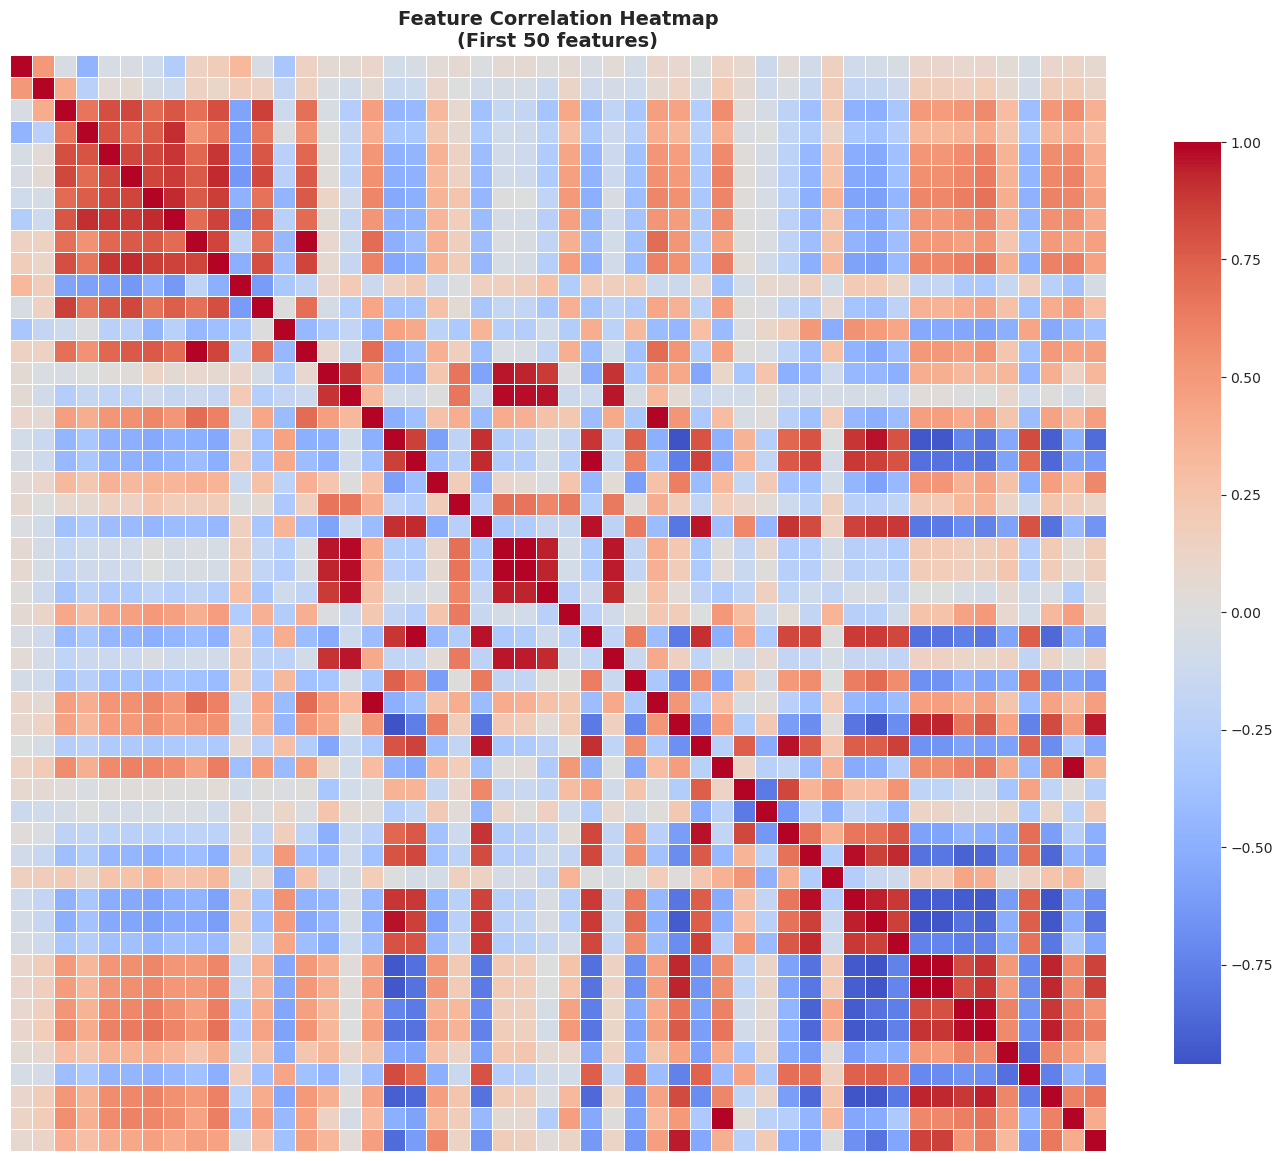

In [20]:
# Check 4: Feature correlations (sample)
if feature_matrix is not None:
    print("\n" + "=" * 70)
    print("CHECK 4: FEATURE CORRELATIONS (Sample)")
    print("=" * 70)
    
    # Chọn 50 features đầu tiên để visualize correlation
    n_sample_features = min(50, feature_matrix.shape[1])
    
    # Remove NaN values cho correlation
    sample_matrix = feature_matrix[:, :n_sample_features]
    
    # Tính correlation matrix
    # Note: np.corrcoef không handle NaN tốt, nên ta dùng pandas
    df = pd.DataFrame(sample_matrix, columns=feature_names[:n_sample_features])
    corr_matrix = df.corr()
    
    print(f"\nTính correlation cho {n_sample_features} features đầu tiên...")
    
    # Tìm high correlation pairs (|corr| > 0.95)
    high_corr_pairs = []
    for i in range(len(corr_matrix)):
        for j in range(i+1, len(corr_matrix)):
            if abs(corr_matrix.iloc[i, j]) > 0.95:
                high_corr_pairs.append({
                    'feature1': feature_names[i],
                    'feature2': feature_names[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    
    print(f"\nSố lượng high correlation pairs (|r| > 0.95): {len(high_corr_pairs)}")
    
    if len(high_corr_pairs) > 0:
        print("\nHigh correlation pairs (10 đầu tiên):")
        for i, pair in enumerate(high_corr_pairs[:10]):
            print(f"  {i+1}. {pair['feature1'][:40]}...")
            print(f"      ↔ {pair['feature2'][:40]}...")
            print(f"      Correlation: {pair['correlation']:.4f}")
            print()
    
    # Visualize correlation heatmap
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8},
                xticklabels=False, yticklabels=False)
    plt.title(f'Feature Correlation Heatmap\n(First {n_sample_features} features)', 
             fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save heatmap
    heatmap_path = OUTPUT_DIR / "correlation_heatmap.png"
    plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
    print(f"\n✅ Correlation heatmap saved: {heatmap_path}")
    
    plt.show()

In [21]:
# Summary của Quality Check
if feature_matrix is not None:
    print("\n" + "=" * 70)
    print("FEATURE QUALITY CHECK SUMMARY")
    print("=" * 70)
    
    print(f"\nTotal features: {len(feature_names)}")
    print(f"Total patients: {feature_matrix.shape[0]}")
    
    print("\nQuality Issues:")
    print(f"  1. Constant features (variance ≈ 0): {len(constant_features_list)}")
    print(f"  2. High missing rate (>50%): {len(high_missing_features_list)}")
    print(f"  3. High outlier rate (>10%): {len(outlier_features)}")
    print(f"  4. High correlations (|r| > 0.95): {len(high_corr_pairs)} pairs")
    
    # Tạo danh sách features nên remove
    features_to_remove = list(set(constant_features_list + high_missing_features_list))
    
    print(f"\nRecommendation:")
    print(f"  → Remove {len(features_to_remove)} invalid features")
    print(f"  → Remaining: {len(feature_names) - len(features_to_remove)} features")
    
    # Lưu danh sách features to remove
    invalid_features_path = OUTPUT_DIR / "invalid_features.json"
    invalid_features_info = {
        'constant_features': constant_features_list,
        'high_missing_features': high_missing_features_list,
        'features_to_remove': features_to_remove,
        'n_invalid': len(features_to_remove),
        'n_valid': len(feature_names) - len(features_to_remove)
    }
    
    with open(invalid_features_path, 'w') as f:
        json.dump(invalid_features_info, f, indent=2)
    
    print(f"\n✅ Invalid features list saved: {invalid_features_path}")
    
    print("\n" + "=" * 70)
    print("✅ QUALITY CHECK COMPLETED!")
    print("=" * 70)


FEATURE QUALITY CHECK SUMMARY

Total features: 107
Total patients: 421

Quality Issues:
  1. Constant features (variance ≈ 0): 0
  2. High missing rate (>50%): 0
  3. High outlier rate (>10%): 2
  4. High correlations (|r| > 0.95): 24 pairs

Recommendation:
  → Remove 0 invalid features
  → Remaining: 107 features

✅ Invalid features list saved: features/invalid_features.json

✅ QUALITY CHECK COMPLETED!



Visualizing feature distributions...

✅ Feature distributions saved: features/feature_distributions.png


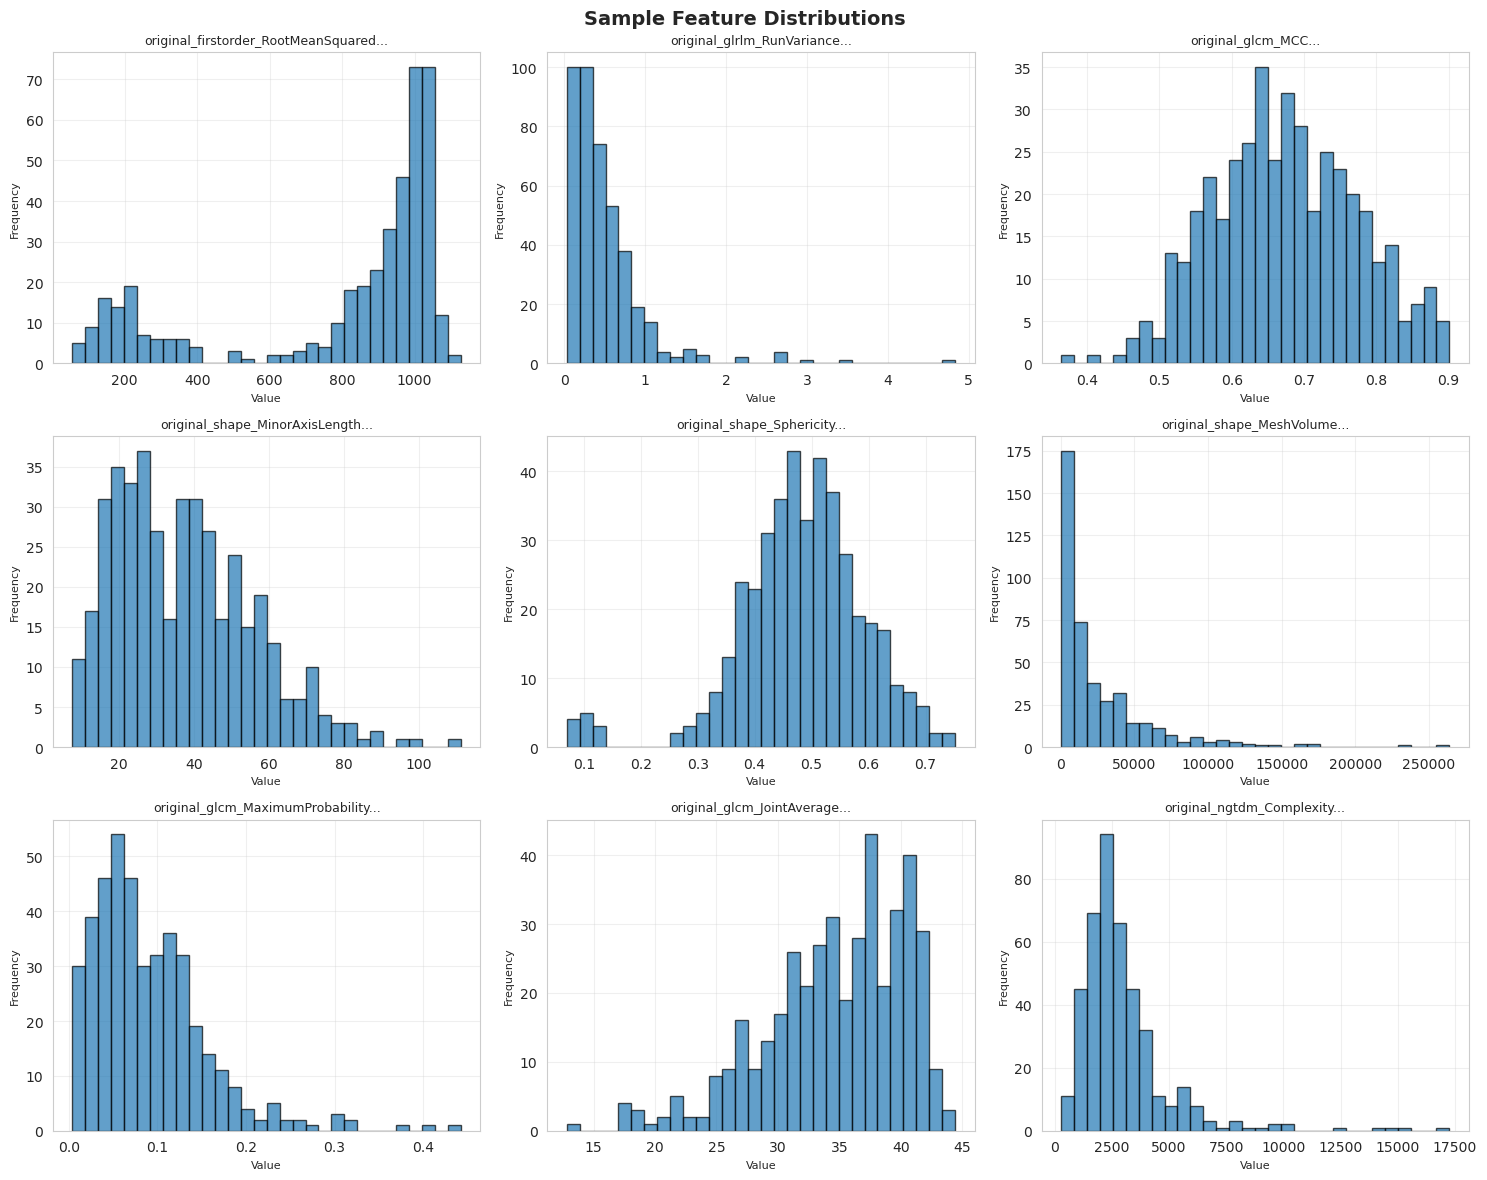

In [22]:
# Visualize feature distributions (sample)
if feature_matrix is not None:
    print("\nVisualizing feature distributions...\n")
    
    # Chọn 9 features ngẫu nhiên để visualize
    n_viz = min(9, feature_matrix.shape[1])
    random_indices = np.random.choice(feature_matrix.shape[1], n_viz, replace=False)
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()
    
    for i, idx in enumerate(random_indices):
        feature_values = feature_matrix[:, idx]
        feature_values = feature_values[~np.isnan(feature_values)]  # Remove NaN
        
        if len(feature_values) > 0:
            axes[i].hist(feature_values, bins=30, edgecolor='black', alpha=0.7)
            axes[i].set_title(f"{feature_names[idx][:40]}...", fontsize=9)
            axes[i].set_xlabel('Value', fontsize=8)
            axes[i].set_ylabel('Frequency', fontsize=8)
            axes[i].grid(True, alpha=0.3)
    
    plt.suptitle('Sample Feature Distributions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save
    dist_path = OUTPUT_DIR / "feature_distributions.png"
    plt.savefig(dist_path, dpi=150, bbox_inches='tight')
    print(f"✅ Feature distributions saved: {dist_path}")
    
    plt.show()

---
## 🎯 Checkpoint: Feature Extraction Completed!

### Outputs:

1. **Feature Matrix**: `data/features/radiomic_features_440.npy`
   - Shape: (n_patients, ~440 features)
   
2. **Feature Names**: `data/features/feature_names.json`
   - List of all feature names
   
3. **Patient IDs**: `data/features/patient_ids.json`
   - List of patient IDs corresponding to rows
   
4. **Metadata**: `data/features/extraction_metadata.json`
   - Extraction statistics and info
   
5. **Quality Check Results**:
   - `invalid_features.json`: List of features to remove
   - `correlation_heatmap.png`: Correlation visualization
   - `feature_distributions.png`: Distribution plots

### Next Steps:

- **Notebook 3**: Feature selection and dimensionality reduction
- **Notebook 4**: Build prognostic models

---

In [23]:
# Final summary
print("\n" + "="*70)
print("📊 NOTEBOOK 2 COMPLETED SUCCESSFULLY! 📊")
print("="*70)

if feature_matrix is not None:
    print(f"\n✅ Feature extraction completed for {feature_matrix.shape[0]} patients")
    print(f"✅ Total features extracted: {feature_matrix.shape[1]}")
    print(f"✅ Valid features (after QC): {len(feature_names) - len(features_to_remove)}")
    print(f"\nAll results saved to: {OUTPUT_DIR}")
else:
    print("\n⚠️ Feature extraction chưa hoàn thành.")
    print("Vui lòng kiểm tra lại các cells phía trên.")

print("\n" + "="*70)


📊 NOTEBOOK 2 COMPLETED SUCCESSFULLY! 📊

✅ Feature extraction completed for 421 patients
✅ Total features extracted: 107
✅ Valid features (after QC): 107

All results saved to: features



RADIOMICS FEATURES VISUALIZATION

🔍 Đang tìm kiếm dữ liệu features đã extract...

📂 Tìm thấy dữ liệu thực tại: features
   ✅ Loaded feature matrix: (421, 107)
   ✅ Loaded 107 feature names
   ✅ Loaded 421 patient IDs
   ✅ Analyzed feature groups:
      - Shape: 14 features
      - First-order (Intensity): 18 features
      - GLCM (Texture): 24 features
      - GLRLM (Texture): 16 features
      - GLSZM (Texture): 16 features
      - GLDM (Texture): 14 features
      - NGTDM (Texture): 5 features

✅ Sử dụng dữ liệu thực!
   Feature matrix: 421 patients × 107 features

PHẦN 2: FEATURE STATISTICS OVERVIEW

Dataset shape: (421, 107)

Bảng thống kê cơ bản (5 features đầu tiên):
       original_shape_Elongation  original_shape_Flatness  \
count                 421.000000               421.000000   
mean                    0.715472                 0.277376   
std                     0.167278                 0.086355   
min                     0.048248                 0.020185   
25%          

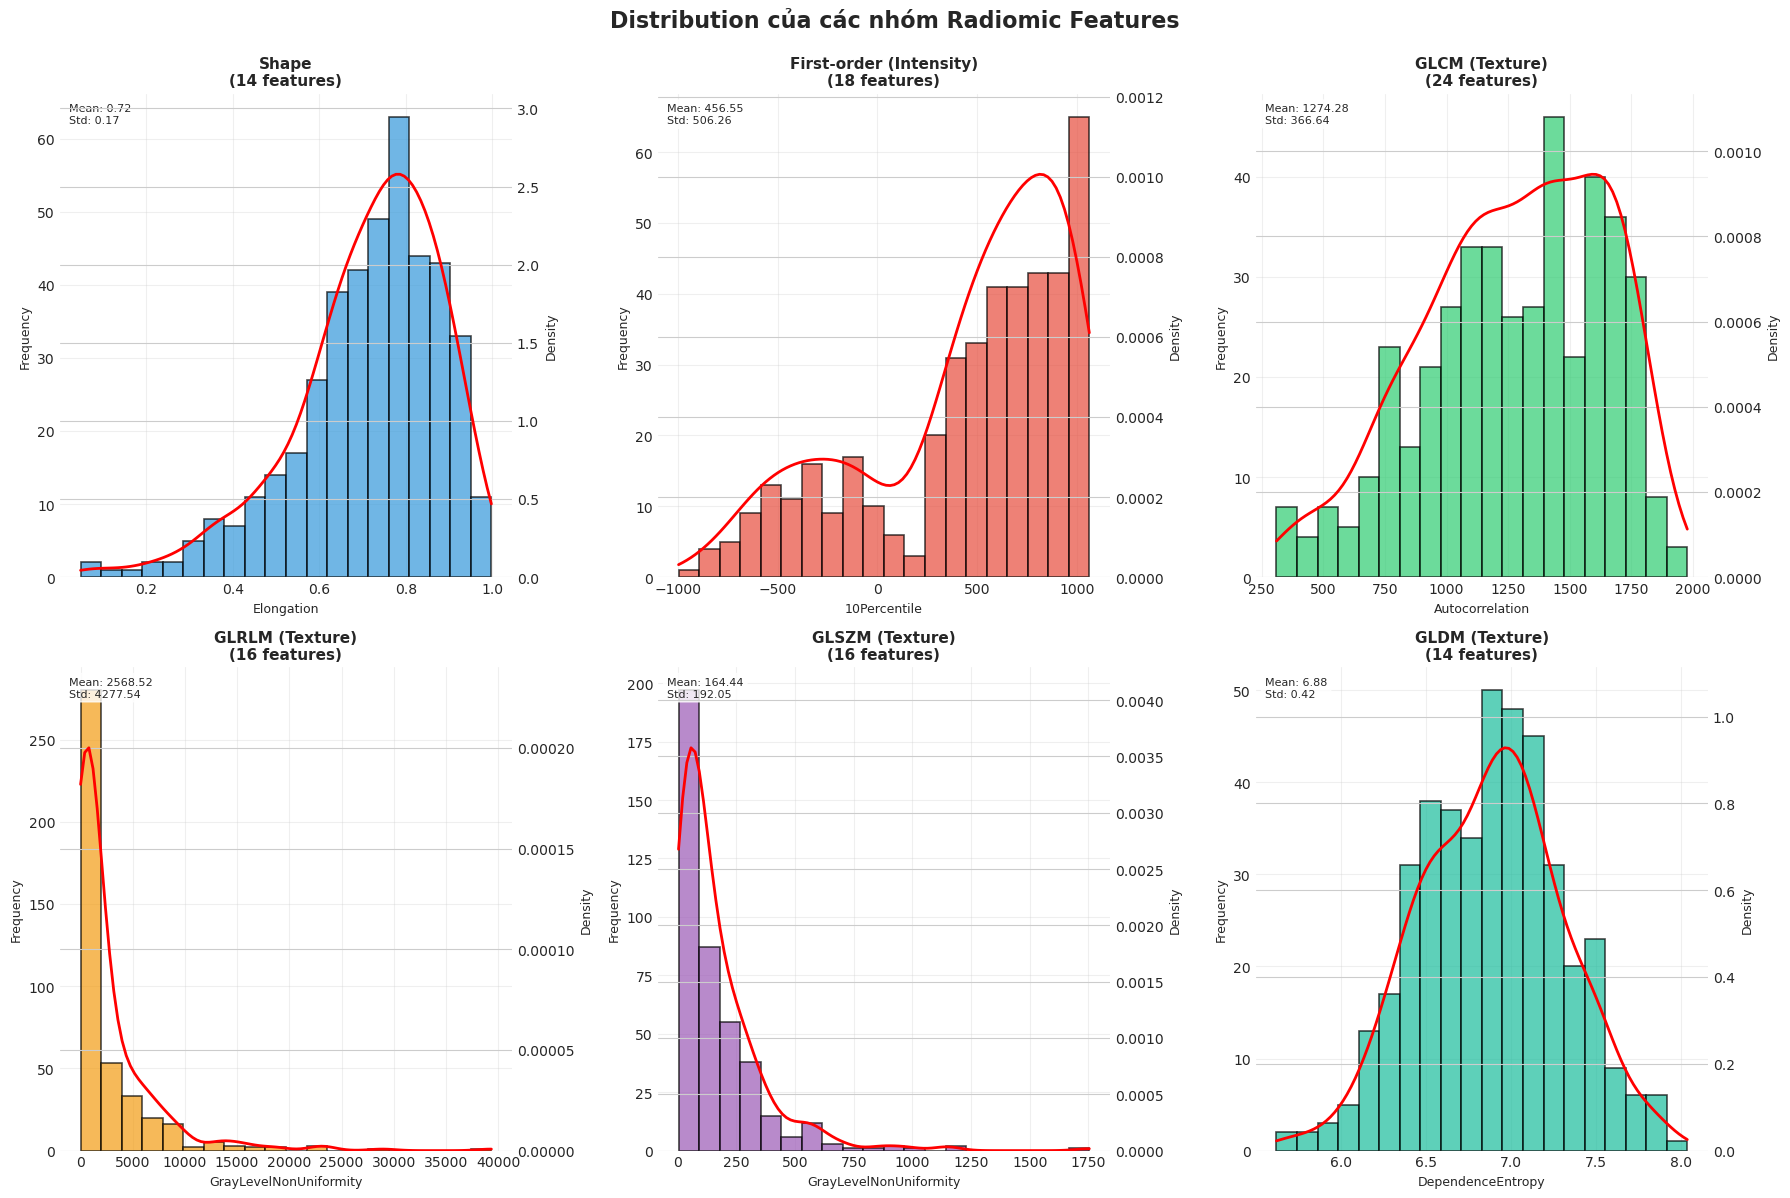


PHẦN 4: CORRELATION MATRIX

✅ Saved: visualizations/02_correlation_matrix.png


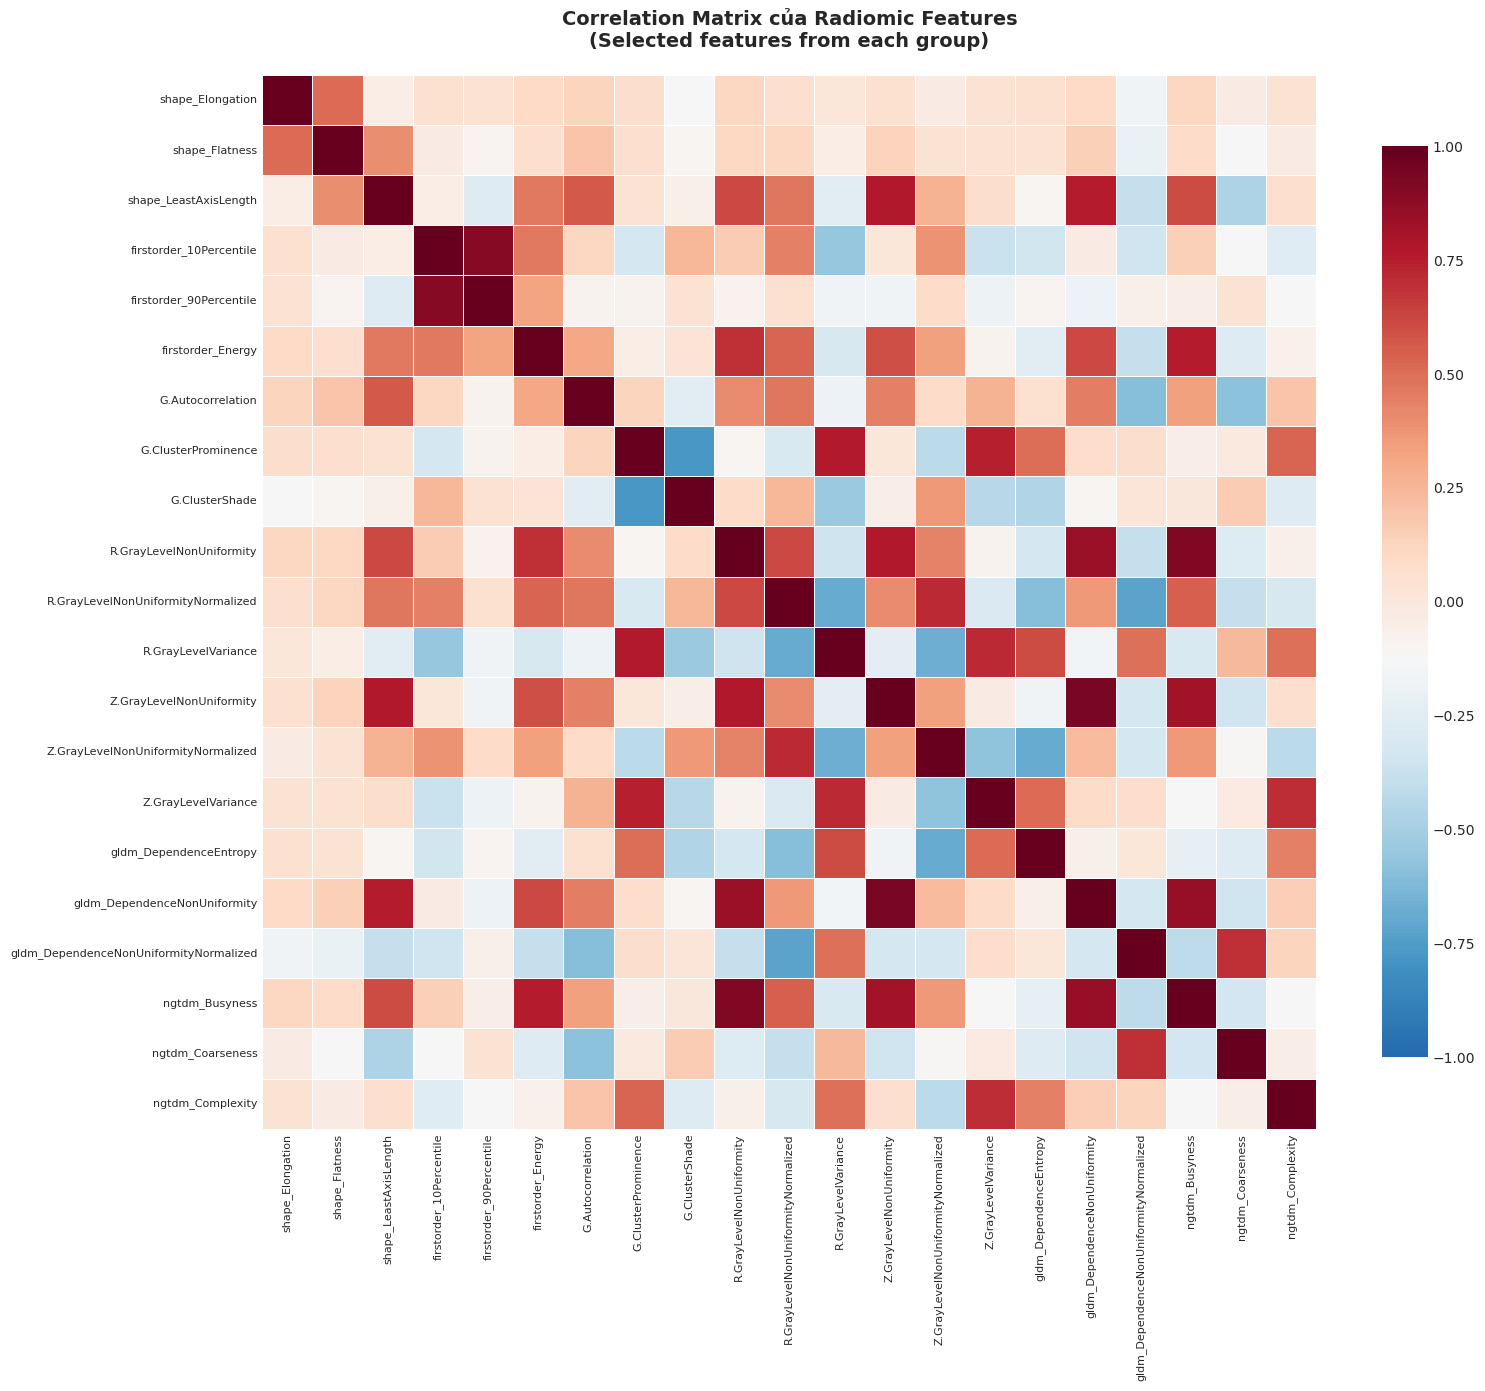


🔍 High Correlation Pairs (|r| > 0.8):
              Feature 1               Feature 2  Correlation
 GrayLevelNonUniformity DependenceNonUniformity     0.943220
 GrayLevelNonUniformity                Busyness     0.907634
           10Percentile            90Percentile     0.893868
DependenceNonUniformity                Busyness     0.852478
 GrayLevelNonUniformity DependenceNonUniformity     0.837956
 GrayLevelNonUniformity                Busyness     0.819033

PHẦN 5: SO SÁNH FEATURES GIỮA PATIENTS

✅ Saved: visualizations/03_patient_comparison.png


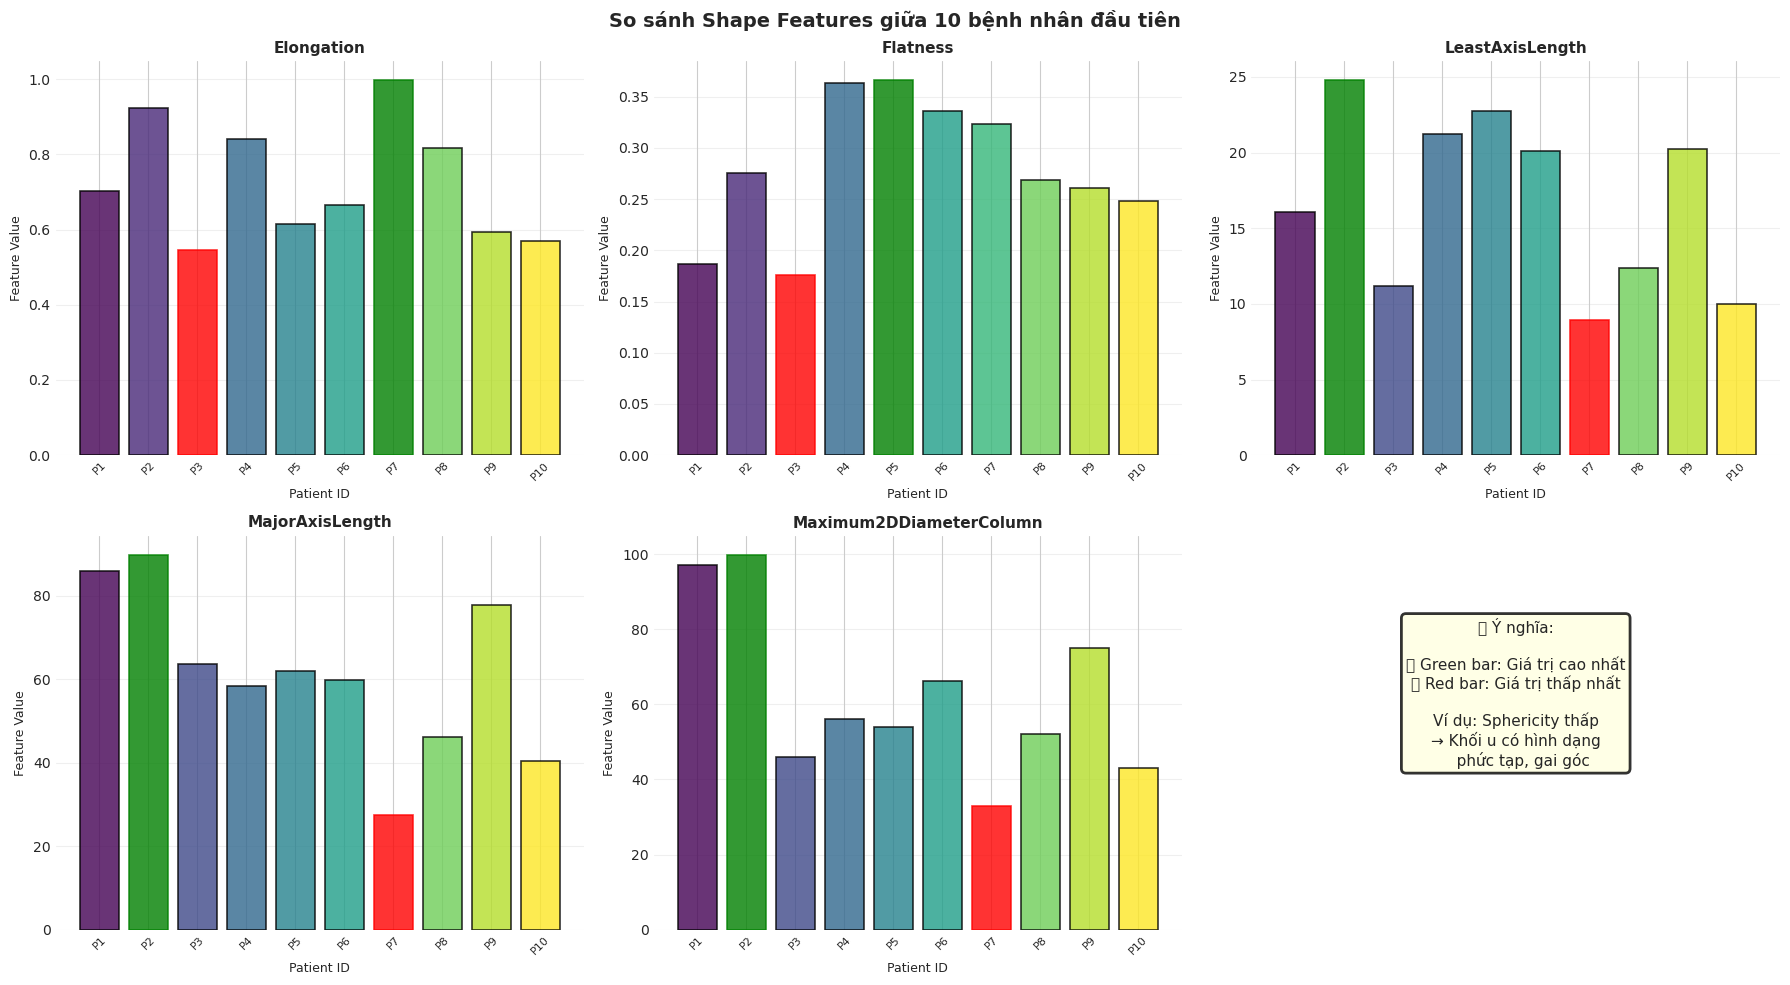


PHẦN 6: PCA ANALYSIS - FEATURE VARIANCE

✅ Saved: visualizations/04_pca_analysis.png


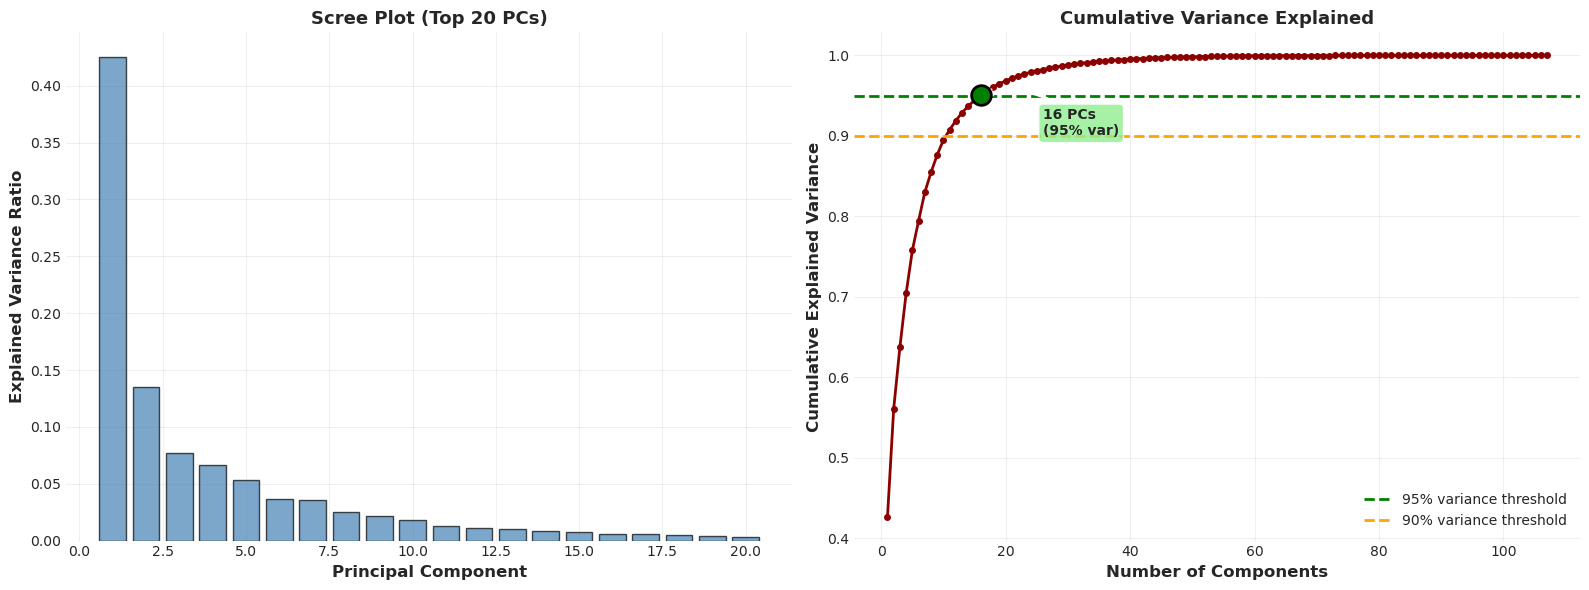


📊 Để giữ 95% variance, cần 16 principal components
   (từ 107 features ban đầu)
   → Giảm chiều dữ liệu: 107 → 16

PHẦN 7: SHAPE FEATURES - DETAILED ANALYSIS

✅ Saved: visualizations/05_shape_features_detailed.png


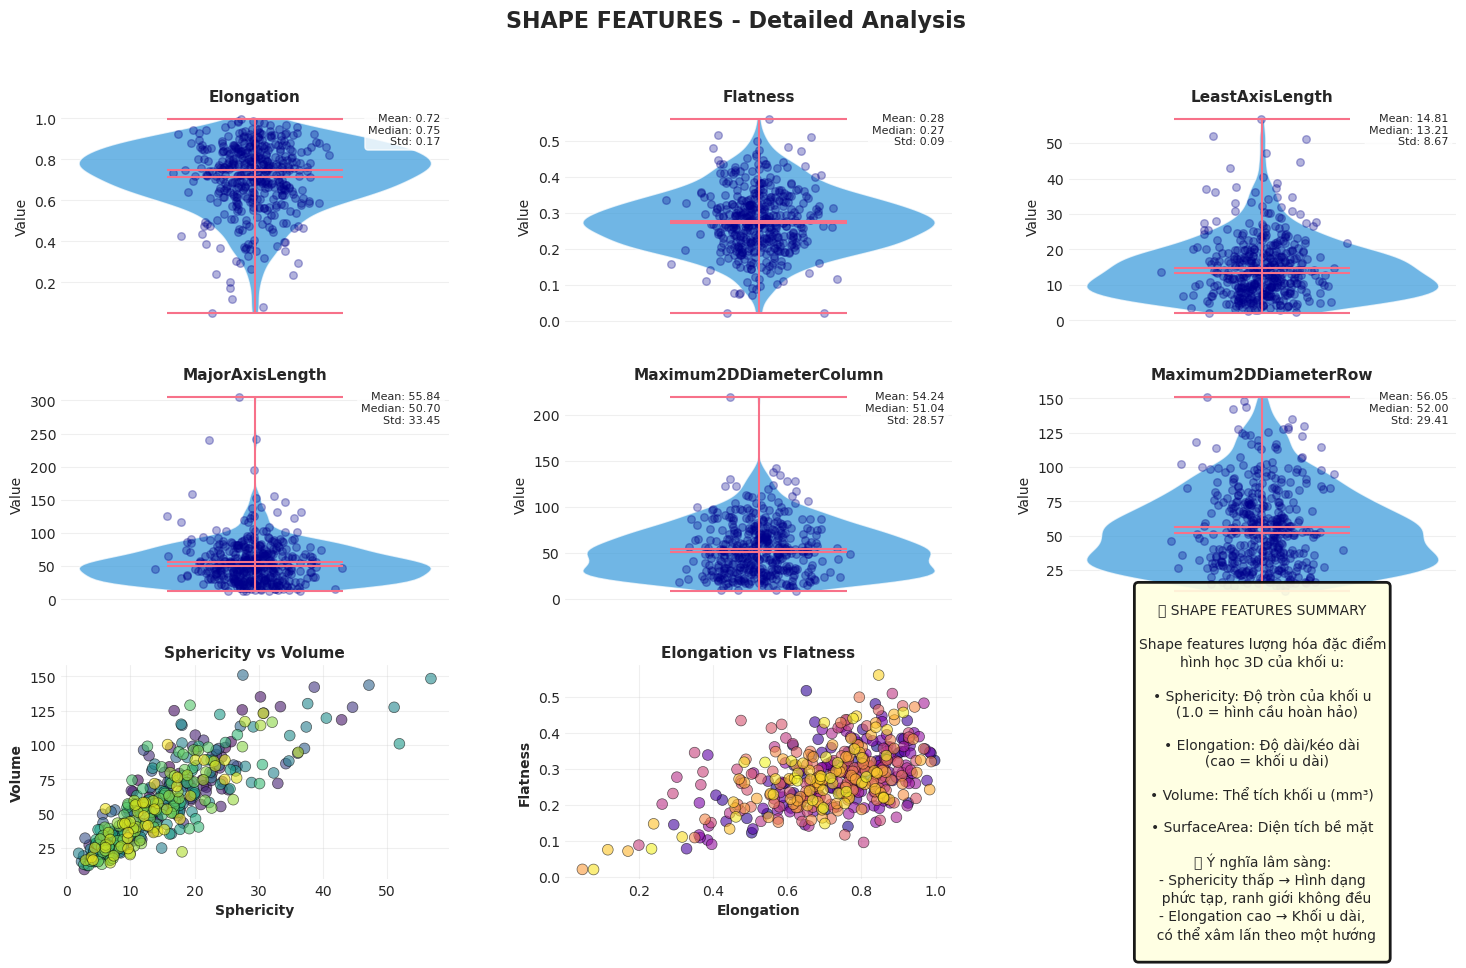


SUMMARY REPORT

📊 RADIOMIC FEATURES EXTRACTION SUMMARY

Dataset Information:
  • Number of patients: 421
  • Number of features: 107

Feature Groups:
  • Shape features: 14
  • Intensity features: 18
  • GLCM (texture): 24
  • GLRLM (texture): 16
  • GLSZM (texture): 16
  • Wavelet features: 0

Quality Metrics:
  • Missing values: 0
  • Features with zero variance: 0

Dimensionality Reduction:
  • PCs for 95% variance: 16
  • Compression ratio: 6.7x

Output Files Generated:
  ✅ 01_feature_distributions_by_group.png
  ✅ 02_correlation_matrix.png
  ✅ 03_patient_comparison.png
  ✅ 04_pca_analysis.png
  ✅ 05_shape_features_detailed.png

All visualizations saved to: visualizations/

💡 Key Insights:
  1. Features được phân thành các nhóm rõ ràng (Shape, Intensity, Texture)
  2. Một số features có correlation cao → cần feature selection
  3. PCA cho thấy có thể giảm chiều dữ liệu đáng kể
  4. Shape features cung cấp thông tin về hình thái khối u

📚 Bước tiếp theo:
  → Feature selection (loại

In [32]:
#!/usr/bin/env python3
"""
Notebook 3: Visualize Radiomics Features
Minh họa kết quả features đã extract được từ NSCLC-Radiomics dataset

Mục đích:
- Hiểu rõ các nhóm features (Shape, Intensity, Texture)
- Visualize distributions và correlations
- So sánh features giữa các bệnh nhân
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Cấu hình
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
OUTPUT_DIR = Path("./visualizations")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("="*70)
print("RADIOMICS FEATURES VISUALIZATION")
print("="*70)

# ============================================================================
# PHẦN 1: LOAD DỮ LIỆU (Dữ liệu thực hoặc Mock Data)
# ============================================================================

def load_real_features():
    """
    Load dữ liệu features thực từ file đã extract.

    Returns:
        Tuple of (feature_matrix, feature_names, patient_ids, feature_groups) hoặc None nếu không tìm thấy
    """
    # Các đường dẫn có thể có
    possible_paths = [
        ("features/radiomic_features_440.npy", "features/feature_names.json", "features/patient_ids.json"),
    ]

    for features_path, names_path, ids_path in possible_paths:
        features_file = Path(features_path)
        names_file = Path(names_path)
        ids_file = Path(ids_path)

        if features_file.exists() and names_file.exists():
            print(f"\n📂 Tìm thấy dữ liệu thực tại: {features_file.parent}")

            # Load feature matrix
            feature_matrix = np.load(features_file)
            print(f"   ✅ Loaded feature matrix: {feature_matrix.shape}")

            # Load feature names
            with open(names_file, 'r') as f:
                feature_names = json.load(f)
            print(f"   ✅ Loaded {len(feature_names)} feature names")

            # Load patient IDs (nếu có)
            if ids_file.exists():
                with open(ids_file, 'r') as f:
                    patient_ids = json.load(f)
                print(f"   ✅ Loaded {len(patient_ids)} patient IDs")
            else:
                # Tạo patient IDs mặc định
                patient_ids = [f"Patient_{i:03d}" for i in range(1, feature_matrix.shape[0] + 1)]
                print(f"   ⚠️  Patient IDs file not found, generated default IDs")

            # Phân tích feature groups từ feature names
            feature_groups = analyze_feature_groups(feature_names)
            print(f"   ✅ Analyzed feature groups:")
            for group_name, features in feature_groups.items():
                print(f"      - {group_name}: {len(features)} features")

            return feature_matrix, feature_names, patient_ids, feature_groups

    return None


def analyze_feature_groups(feature_names):
    """
    Phân tích và nhóm features theo tên (từ dữ liệu thực).

    Args:
        feature_names: List các tên features

    Returns:
        Dictionary chứa các nhóm features
    """
    feature_groups = {
        'Shape': [],
        'First-order (Intensity)': [],
        'GLCM (Texture)': [],
        'GLRLM (Texture)': [],
        'GLSZM (Texture)': [],
        'GLDM (Texture)': [],
        'NGTDM (Texture)': [],
        'Wavelet': []
    }

    for fname in feature_names:
        fname_lower = fname.lower()

        # Wavelet features
        if 'wavelet' in fname_lower:
            feature_groups['Wavelet'].append(fname)
        # Shape features (chỉ có trong original)
        elif 'original' in fname_lower and 'shape' in fname_lower:
            feature_groups['Shape'].append(fname)
        # First-order features
        elif 'firstorder' in fname_lower:
            feature_groups['First-order (Intensity)'].append(fname)
        # GLCM
        elif 'glcm' in fname_lower:
            feature_groups['GLCM (Texture)'].append(fname)
        # GLRLM
        elif 'glrlm' in fname_lower:
            feature_groups['GLRLM (Texture)'].append(fname)
        # GLSZM
        elif 'glszm' in fname_lower:
            feature_groups['GLSZM (Texture)'].append(fname)
        # GLDM
        elif 'gldm' in fname_lower:
            feature_groups['GLDM (Texture)'].append(fname)
        # NGTDM
        elif 'ngtdm' in fname_lower:
            feature_groups['NGTDM (Texture)'].append(fname)

    # Remove empty groups
    feature_groups = {k: v for k, v in feature_groups.items() if len(v) > 0}

    return feature_groups


def create_sample_features(n_patients=50, n_features=107):
    """Tạo dữ liệu features mẫu để minh họa"""

    # Định nghĩa các nhóm features theo pyradiomics
    feature_groups = {
        'Shape': [
            'original_shape_Elongation',
            'original_shape_Flatness',
            'original_shape_Sphericity',
            'original_shape_SurfaceArea',
            'original_shape_SurfaceVolumeRatio',
            'original_shape_Volume',
            'original_shape_Maximum2DDiameterSlice',
            'original_shape_Maximum3DDiameter',
            'original_shape_MeshVolume',
            'original_shape_VoxelVolume'
        ],
        'First-order (Intensity)': [
            'original_firstorder_10Percentile',
            'original_firstorder_90Percentile',
            'original_firstorder_Energy',
            'original_firstorder_Entropy',
            'original_firstorder_Kurtosis',
            'original_firstorder_Maximum',
            'original_firstorder_Mean',
            'original_firstorder_Median',
            'original_firstorder_Minimum',
            'original_firstorder_Range',
            'original_firstorder_Skewness',
            'original_firstorder_Uniformity',
            'original_firstorder_Variance'
        ],
        'GLCM (Texture)': [
            'original_glcm_Autocorrelation',
            'original_glcm_Contrast',
            'original_glcm_Correlation',
            'original_glcm_DifferenceEntropy',
            'original_glcm_DifferenceVariance',
            'original_glcm_JointEnergy',
            'original_glcm_JointEntropy',
            'original_glcm_Homogeneity1',
            'original_glcm_Homogeneity2'
        ],
        'GLRLM (Texture)': [
            'original_glrlm_ShortRunEmphasis',
            'original_glrlm_LongRunEmphasis',
            'original_glrlm_GrayLevelNonUniformity',
            'original_glrlm_RunLengthNonUniformity',
            'original_glrlm_RunPercentage',
            'original_glrlm_LowGrayLevelRunEmphasis',
            'original_glrlm_HighGrayLevelRunEmphasis'
        ],
        'GLSZM (Texture)': [
            'original_glszm_SmallAreaEmphasis',
            'original_glszm_LargeAreaEmphasis',
            'original_glszm_GrayLevelNonUniformity',
            'original_glszm_SizeZoneNonUniformity',
            'original_glszm_ZonePercentage'
        ]
    }

    # Tạo feature names
    feature_names = []
    for group_name, features in feature_groups.items():
        feature_names.extend(features)

    # Thêm wavelet features
    wavelet_types = ['HHH', 'HHL', 'HLH', 'HLL', 'LHH', 'LHL', 'LLH', 'LLL']
    for wtype in wavelet_types[:3]:  # Lấy 3 wavelet types cho demo
        for i in range(5):
            feature_names.append(f'wavelet-{wtype}_firstorder_Feature{i}')

    n_features = len(feature_names)

    # Tạo feature matrix với phân phối realistic
    np.random.seed(42)
    feature_matrix = np.zeros((n_patients, n_features))

    idx = 0
    # Shape features - phân phối log-normal
    for i in range(10):
        feature_matrix[:, idx] = np.random.lognormal(mean=2, sigma=1, size=n_patients)
        idx += 1

    # First-order features - phân phối normal
    for i in range(13):
        feature_matrix[:, idx] = np.random.normal(loc=100, scale=30, size=n_patients)
        idx += 1

    # GLCM features - phân phối uniform
    for i in range(9):
        feature_matrix[:, idx] = np.random.uniform(low=0, high=1, size=n_patients)
        idx += 1

    # GLRLM features
    for i in range(7):
        feature_matrix[:, idx] = np.random.gamma(shape=2, scale=2, size=n_patients)
        idx += 1

    # GLSZM features
    for i in range(5):
        feature_matrix[:, idx] = np.random.beta(a=2, b=5, size=n_patients)
        idx += 1

    # Wavelet features
    for i in range(idx, n_features):
        feature_matrix[:, i] = np.random.normal(loc=50, scale=20, size=n_patients)

    # Tạo patient IDs
    patient_ids = [f"LUNG1-{i:03d}" for i in range(1, n_patients + 1)]

    return feature_matrix, feature_names, patient_ids, feature_groups


# Thử load dữ liệu thực trước
print("\n🔍 Đang tìm kiếm dữ liệu features đã extract...")
data = load_real_features()

if data is not None:
    # Sử dụng dữ liệu thực
    feature_matrix, feature_names, patient_ids, feature_groups = data
    print(f"\n✅ Sử dụng dữ liệu thực!")
    print(f"   Feature matrix: {feature_matrix.shape[0]} patients × {feature_matrix.shape[1]} features")
else:
    # Fallback: Tạo dữ liệu mẫu
    print("\n⚠️  Không tìm thấy dữ liệu thực.")
    print("   Đang tạo dữ liệu mẫu để minh họa...")
    print("\n💡 Để sử dụng dữ liệu thực:")
    print("   1. Chạy notebook 02_feature_extraction.ipynb để extract features")
    print("   2. Đảm bảo file data/features/radiomic_features_440.npy tồn tại")
    print("   3. Chạy lại script này\n")

    feature_matrix, feature_names, patient_ids, feature_groups = create_sample_features(n_patients=50)
    print(f"✅ Feature matrix (mock): {feature_matrix.shape[0]} patients × {feature_matrix.shape[1]} features")

# ============================================================================
# PHẦN 2: OVERVIEW - FEATURE STATISTICS
# ============================================================================
print("\n" + "="*70)
print("PHẦN 2: FEATURE STATISTICS OVERVIEW")
print("="*70)

# Tạo DataFrame
df_features = pd.DataFrame(feature_matrix, index=patient_ids, columns=feature_names)

print(f"\nDataset shape: {df_features.shape}")
print(f"\nBảng thống kê cơ bản (5 features đầu tiên):")
print(df_features.iloc[:, :5].describe())

# ============================================================================
# PHẦN 3: FEATURE DISTRIBUTIONS BY GROUP
# ============================================================================
print("\n" + "="*70)
print("PHẦN 3: FEATURE DISTRIBUTIONS BY GROUP")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribution của các nhóm Radiomic Features',
             fontsize=16, fontweight='bold', y=0.995)

# Vẽ distribution cho mỗi nhóm
plot_idx = 0
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for group_name, features in list(feature_groups.items())[:6]:
    ax = axes.flatten()[plot_idx]

    # Lấy features của nhóm này
    group_features = [f for f in features if f in feature_names]
    if len(group_features) > 0:
        # Chọn 1 feature đại diện
        sample_feature = group_features[0]
        feature_idx = feature_names.index(sample_feature)
        values = feature_matrix[:, feature_idx]

        # Vẽ histogram
        ax.hist(values, bins=20, color=colors[plot_idx],
               alpha=0.7, edgecolor='black', linewidth=1.2)

        # Thêm KDE line
        from scipy import stats
        kde = stats.gaussian_kde(values)
        x_range = np.linspace(values.min(), values.max(), 100)
        ax2 = ax.twinx()
        ax2.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
        ax2.set_ylabel('Density', fontsize=9)
        ax2.set_ylim(0, kde(x_range).max() * 1.2)

        ax.set_title(f'{group_name}\n({len(group_features)} features)',
                    fontsize=11, fontweight='bold')
        ax.set_xlabel(sample_feature.split('_')[-1], fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.grid(True, alpha=0.3)

        # Thêm statistics text
        stats_text = f'Mean: {values.mean():.2f}\nStd: {values.std():.2f}'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
               verticalalignment='top', bbox=dict(boxstyle='round',
               facecolor='white', alpha=0.8), fontsize=8)

    plot_idx += 1

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_feature_distributions_by_group.png", dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: {OUTPUT_DIR}/01_feature_distributions_by_group.png")
plt.show()

# ============================================================================
# PHẦN 4: CORRELATION MATRIX
# ============================================================================
print("\n" + "="*70)
print("PHẦN 4: CORRELATION MATRIX")
print("="*70)

# Chọn một số features đại diện từ mỗi nhóm
selected_features = []
for group_name, features in feature_groups.items():
    group_features = [f for f in features if f in feature_names]
    if len(group_features) > 0:
        # Lấy 3 features đầu tiên của mỗi nhóm
        selected_features.extend(group_features[:3])

# Tính correlation matrix
df_selected = df_features[selected_features]
corr_matrix = df_selected.corr()

# Vẽ correlation heatmap
fig, ax = plt.subplots(figsize=(16, 14))

# Custom colormap
from matplotlib.colors import TwoSlopeNorm
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, norm=norm,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot=False, fmt='.2f', ax=ax)

# Shorten labels
short_labels = [name.replace('original_', '').replace('glcm_', 'G.')
                .replace('glrlm_', 'R.').replace('glszm_', 'Z.')
                for name in selected_features]
ax.set_xticklabels(short_labels, rotation=90, fontsize=8)
ax.set_yticklabels(short_labels, rotation=0, fontsize=8)

ax.set_title('Correlation Matrix của Radiomic Features\n(Selected features from each group)',
            fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_correlation_matrix.png", dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: {OUTPUT_DIR}/02_correlation_matrix.png")
plt.show()

# Tìm high correlation pairs
print("\n🔍 High Correlation Pairs (|r| > 0.8):")
high_corr_pairs = []
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Feature 1': selected_features[i].split('_')[-1],
                'Feature 2': selected_features[j].split('_')[-1],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    df_corr = pd.DataFrame(high_corr_pairs).sort_values('Correlation',
                                                        ascending=False,
                                                        key=abs)
    print(df_corr.to_string(index=False))
else:
    print("No highly correlated pairs found.")

# ============================================================================
# PHẦN 5: SO SÁNH FEATURES GIỮA PATIENTS
# ============================================================================
print("\n" + "="*70)
print("PHẦN 5: SO SÁNH FEATURES GIỮA PATIENTS")
print("="*70)

# So sánh Shape features cho 10 patients đầu tiên
shape_features = [f for f in feature_groups['Shape'] if f in feature_names][:5]
n_patients_to_show = 10

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('So sánh Shape Features giữa 10 bệnh nhân đầu tiên',
             fontsize=14, fontweight='bold')

for idx, feat in enumerate(shape_features):
    ax = axes.flatten()[idx]
    feature_idx = feature_names.index(feat)
    values = feature_matrix[:n_patients_to_show, feature_idx]

    # Bar plot
    bars = ax.bar(range(n_patients_to_show), values,
                  color=plt.cm.viridis(np.linspace(0, 1, n_patients_to_show)),
                  edgecolor='black', linewidth=1.2, alpha=0.8)

    ax.set_title(feat.split('_')[-1], fontsize=11, fontweight='bold')
    ax.set_xlabel('Patient ID', fontsize=9)
    ax.set_ylabel('Feature Value', fontsize=9)
    ax.set_xticks(range(n_patients_to_show))
    ax.set_xticklabels([f'P{i+1}' for i in range(n_patients_to_show)],
                       rotation=45, fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

    # Highlight min and max
    min_idx = np.argmin(values)
    max_idx = np.argmax(values)
    bars[min_idx].set_color('red')
    bars[max_idx].set_color('green')

# Thêm legend
legend_ax = axes.flatten()[5]
legend_ax.axis('off')
legend_ax.text(0.5, 0.6, '💡 Ý nghĩa:\n\n'
              '🟢 Green bar: Giá trị cao nhất\n'
              '🔴 Red bar: Giá trị thấp nhất\n\n'
              'Ví dụ: Sphericity thấp\n'
              '→ Khối u có hình dạng\n'
              '   phức tạp, gai góc',
              fontsize=11, ha='center', va='center',
              bbox=dict(boxstyle='round', facecolor='lightyellow',
                       alpha=0.8, edgecolor='black', linewidth=2))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_patient_comparison.png", dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: {OUTPUT_DIR}/03_patient_comparison.png")
plt.show()

# ============================================================================
# PHẦN 6: FEATURE IMPORTANCE (PCA Analysis)
# ============================================================================
print("\n" + "="*70)
print("PHẦN 6: PCA ANALYSIS - FEATURE VARIANCE")
print("="*70)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(feature_matrix)

# PCA
pca = PCA()
pca.fit(features_scaled)

# Explained variance
explained_var = pca.explained_variance_ratio_
cumsum_var = np.cumsum(explained_var)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot - show top 20 components or all if less than 20
n_components_show = min(20, len(explained_var))
ax1.bar(range(1, n_components_show+1), explained_var[:n_components_show],
       color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Principal Component', fontsize=12, fontweight='bold')
ax1.set_ylabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
ax1.set_title(f'Scree Plot (Top {n_components_show} PCs)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Cumulative variance
ax2.plot(range(1, len(cumsum_var)+1), cumsum_var,
        marker='o', linewidth=2, markersize=4, color='darkred')
ax2.axhline(y=0.95, color='green', linestyle='--', linewidth=2,
           label='95% variance threshold')
ax2.axhline(y=0.90, color='orange', linestyle='--', linewidth=2,
           label='90% variance threshold')
ax2.set_xlabel('Number of Components', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Explained Variance', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Variance Explained', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Tìm số components cần để đạt 95% variance
if np.max(cumsum_var) >= 0.95:
    n_components_95 = np.argmax(cumsum_var >= 0.95) + 1
    ax2.scatter([n_components_95], [cumsum_var[n_components_95-1]],
               s=200, color='green', zorder=5, edgecolor='black', linewidth=2)

    # Adjust annotation position to avoid going off the plot
    x_offset = min(10, len(cumsum_var) - n_components_95 - 5)
    ax2.annotate(f'{n_components_95} PCs\n(95% var)',
                xy=(n_components_95, cumsum_var[n_components_95-1]),
                xytext=(n_components_95+x_offset, cumsum_var[n_components_95-1]-0.05),
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3',
                              lw=2))
else:
    # If 95% variance not achievable, use all components
    n_components_95 = len(cumsum_var)
    ax2.text(0.5, 0.5, f'Max variance: {np.max(cumsum_var):.1%}\n(All {n_components_95} PCs)',
            transform=ax2.transAxes, ha='center', va='center',
            fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_pca_analysis.png", dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: {OUTPUT_DIR}/04_pca_analysis.png")
plt.show()

print(f"\n📊 Để giữ 95% variance, cần {n_components_95} principal components")
print(f"   (từ {len(feature_names)} features ban đầu)")
print(f"   → Giảm chiều dữ liệu: {len(feature_names)} → {n_components_95}")

# ============================================================================
# PHẦN 7: SHAPE FEATURES - DETAILED ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("PHẦN 7: SHAPE FEATURES - DETAILED ANALYSIS")
print("="*70)

shape_features = [f for f in feature_groups['Shape'] if f in feature_names]

# Tạo figure
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1-6: Individual shape features
for idx, feat in enumerate(shape_features[:6]):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])
    feature_idx = feature_names.index(feat)
    values = feature_matrix[:, feature_idx]

    # Violin plot
    parts = ax.violinplot([values], positions=[0], showmeans=True,
                          showextrema=True, showmedians=True)

    # Customize colors
    for pc in parts['bodies']:
        pc.set_facecolor('#3498db')
        pc.set_alpha(0.7)

    # Overlay scatter
    y_jitter = np.random.normal(0, 0.04, size=len(values))
    ax.scatter(y_jitter, values, alpha=0.3, s=30, color='darkblue')

    ax.set_title(feat.split('_')[-1], fontsize=11, fontweight='bold')
    ax.set_ylabel('Value', fontsize=10)
    ax.set_xticks([])
    ax.grid(True, alpha=0.3, axis='y')

    # Add stats
    stats_text = (f'Mean: {values.mean():.2f}\n'
                 f'Median: {np.median(values):.2f}\n'
                 f'Std: {values.std():.2f}')
    ax.text(0.98, 0.98, stats_text, transform=ax.transAxes,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
           fontsize=8)

# Plot 7-9: Pairwise relationships
ax7 = fig.add_subplot(gs[2, 0])
ax8 = fig.add_subplot(gs[2, 1])
ax9 = fig.add_subplot(gs[2, 2])

# Sphericity vs Volume
feat1_idx = feature_names.index(shape_features[2])  # Sphericity
feat2_idx = feature_names.index(shape_features[5])  # Volume
ax7.scatter(feature_matrix[:, feat1_idx], feature_matrix[:, feat2_idx],
           alpha=0.6, s=60, c=range(len(patient_ids)), cmap='viridis',
           edgecolor='black', linewidth=0.5)
ax7.set_xlabel('Sphericity', fontsize=10, fontweight='bold')
ax7.set_ylabel('Volume', fontsize=10, fontweight='bold')
ax7.set_title('Sphericity vs Volume', fontsize=11, fontweight='bold')
ax7.grid(True, alpha=0.3)

# Elongation vs Flatness
feat3_idx = feature_names.index(shape_features[0])  # Elongation
feat4_idx = feature_names.index(shape_features[1])  # Flatness
ax8.scatter(feature_matrix[:, feat3_idx], feature_matrix[:, feat4_idx],
           alpha=0.6, s=60, c=range(len(patient_ids)), cmap='plasma',
           edgecolor='black', linewidth=0.5)
ax8.set_xlabel('Elongation', fontsize=10, fontweight='bold')
ax8.set_ylabel('Flatness', fontsize=10, fontweight='bold')
ax8.set_title('Elongation vs Flatness', fontsize=11, fontweight='bold')
ax8.grid(True, alpha=0.3)

# Summary box
ax9.axis('off')
summary_text = """
📊 SHAPE FEATURES SUMMARY

Shape features lượng hóa đặc điểm
hình học 3D của khối u:

• Sphericity: Độ tròn của khối u
  (1.0 = hình cầu hoàn hảo)

• Elongation: Độ dài/kéo dài
  (cao = khối u dài)

• Volume: Thể tích khối u (mm³)

• SurfaceArea: Diện tích bề mặt

💡 Ý nghĩa lâm sàng:
- Sphericity thấp → Hình dạng
  phức tạp, ranh giới không đều
- Elongation cao → Khối u dài,
  có thể xâm lấn theo một hướng
"""
ax9.text(0.5, 0.5, summary_text, fontsize=10, ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow',
                 alpha=0.9, edgecolor='black', linewidth=2))

fig.suptitle('SHAPE FEATURES - Detailed Analysis', fontsize=16,
            fontweight='bold', y=0.98)

plt.savefig(OUTPUT_DIR / "05_shape_features_detailed.png", dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: {OUTPUT_DIR}/05_shape_features_detailed.png")
plt.show()

# ============================================================================
# PHẦN 8: SUMMARY REPORT
# ============================================================================
print("\n" + "="*70)
print("SUMMARY REPORT")
print("="*70)

print(f"""
📊 RADIOMIC FEATURES EXTRACTION SUMMARY

Dataset Information:
  • Number of patients: {len(patient_ids)}
  • Number of features: {len(feature_names)}

Feature Groups:
  • Shape features: {len([f for f in feature_groups['Shape'] if f in feature_names])}
  • Intensity features: {len([f for f in feature_groups['First-order (Intensity)'] if f in feature_names])}
  • GLCM (texture): {len([f for f in feature_groups['GLCM (Texture)'] if f in feature_names])}
  • GLRLM (texture): {len([f for f in feature_groups['GLRLM (Texture)'] if f in feature_names])}
  • GLSZM (texture): {len([f for f in feature_groups['GLSZM (Texture)'] if f in feature_names])}
  • Wavelet features: {len([f for f in feature_names if 'wavelet' in f])}

Quality Metrics:
  • Missing values: {np.sum(np.isnan(feature_matrix))}
  • Features with zero variance: {np.sum(feature_matrix.var(axis=0) < 1e-10)}

Dimensionality Reduction:
  • PCs for 95% variance: {n_components_95}
  • Compression ratio: {len(feature_names)/n_components_95:.1f}x

Output Files Generated:
  ✅ 01_feature_distributions_by_group.png
  ✅ 02_correlation_matrix.png
  ✅ 03_patient_comparison.png
  ✅ 04_pca_analysis.png
  ✅ 05_shape_features_detailed.png

All visualizations saved to: {OUTPUT_DIR}/

💡 Key Insights:
  1. Features được phân thành các nhóm rõ ràng (Shape, Intensity, Texture)
  2. Một số features có correlation cao → cần feature selection
  3. PCA cho thấy có thể giảm chiều dữ liệu đáng kể
  4. Shape features cung cấp thông tin về hình thái khối u

📚 Bước tiếp theo:
  → Feature selection (loại bỏ redundant features)
  → Normalization/Standardization
  → Build predictive models (survival, staging, etc.)
""")

print("="*70)
print("✅ VISUALIZATION COMPLETED!")
print("="*70)

In [35]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Feature Selection and Normalization Pipeline
============================================

This script implements comprehensive feature selection and normalization
for radiomic features extracted from lung cancer CT scans.

Main Features:
--------------
1. Feature Selection Methods:
   - Variance threshold filtering
   - Correlation-based redundancy removal
   - Statistical tests (ANOVA F-test, Mutual Information)
   - Recursive Feature Elimination (RFE)
   - Tree-based feature importance

2. Normalization Methods:
   - StandardScaler (Z-score normalization)
   - MinMaxScaler (0-1 scaling)
   - RobustScaler (robust to outliers)

3. Visualization:
   - Feature importance plots
   - Feature selection comparison
   - Distribution before/after normalization

Author: Claude
Date: 2025-11-14
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, List, Dict, Optional
from pathlib import Path

# Scikit-learn imports
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_classif,
    mutual_info_classif,
    RFE,
    SelectFromModel
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


class FeatureSelectionPipeline:
    """
    Comprehensive feature selection and normalization pipeline.

    Attributes:
        features: Input feature matrix (n_samples, n_features)
        feature_names: List of feature names
        labels: Target labels for supervised selection (optional)
        selected_features_: Dictionary storing selected features from each method
        scalers_: Dictionary storing fitted scalers
    """

    def __init__(self, features: np.ndarray, feature_names: List[str],
                 labels: Optional[np.ndarray] = None):
        """
        Initialize the feature selection pipeline.

        Parameters:
            features: Feature matrix (n_samples, n_features)
            feature_names: List of feature names
            labels: Target labels for supervised methods (optional)
        """
        self.features = features
        self.feature_names = np.array(feature_names)
        self.labels = labels
        self.selected_features_ = {}
        self.scalers_ = {}

        print(f"📊 Initialized with {features.shape[0]} samples and {features.shape[1]} features")
        if labels is not None:
            unique_labels, counts = np.unique(labels, return_counts=True)
            print(f"📋 Labels: {dict(zip(unique_labels, counts))}")

    def remove_low_variance(self, threshold: float = 0.01) -> Tuple[np.ndarray, np.ndarray]:
        """
        Remove features with low variance.

        Parameters:
            threshold: Variance threshold (default: 0.01)

        Returns:
            Tuple of (selected_features, selected_feature_names)
        """
        print(f"\n🔍 Removing low variance features (threshold={threshold})...")

        selector = VarianceThreshold(threshold=threshold)
        features_selected = selector.fit_transform(self.features)
        feature_names_selected = self.feature_names[selector.get_support()]

        n_removed = len(self.feature_names) - len(feature_names_selected)
        print(f"   ✓ Removed {n_removed} features")
        print(f"   ✓ Retained {len(feature_names_selected)} features")

        self.selected_features_['low_variance'] = {
            'features': features_selected,
            'feature_names': feature_names_selected,
            'support': selector.get_support()
        }

        return features_selected, feature_names_selected

    def remove_correlated_features(self, threshold: float = 0.9) -> Tuple[np.ndarray, np.ndarray]:
        """
        Remove highly correlated features.

        Parameters:
            threshold: Correlation threshold (default: 0.9)

        Returns:
            Tuple of (selected_features, selected_feature_names)
        """
        print(f"\n🔍 Removing correlated features (|r| > {threshold})...")

        # Calculate correlation matrix
        df = pd.DataFrame(self.features, columns=self.feature_names)
        corr_matrix = df.corr().abs()

        # Select upper triangle of correlation matrix
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        # Find features with correlation greater than threshold
        to_drop = [column for column in upper_triangle.columns
                   if any(upper_triangle[column] > threshold)]

        # Keep features not in to_drop
        feature_mask = ~df.columns.isin(to_drop)
        features_selected = df.loc[:, feature_mask].values
        feature_names_selected = df.columns[feature_mask].values

        print(f"   ✓ Removed {len(to_drop)} correlated features")
        print(f"   ✓ Retained {len(feature_names_selected)} features")

        self.selected_features_['correlation'] = {
            'features': features_selected,
            'feature_names': feature_names_selected,
            'removed_features': to_drop,
            'support': feature_mask
        }

        return features_selected, feature_names_selected

    def select_anova_features(self, k: int = 50) -> Tuple[np.ndarray, np.ndarray]:
        """
        Select top k features using ANOVA F-test.

        Parameters:
            k: Number of top features to select

        Returns:
            Tuple of (selected_features, selected_feature_names)
        """
        if self.labels is None:
            print("⚠️  Labels required for ANOVA feature selection. Skipping...")
            return self.features, self.feature_names

        print(f"\n🔍 Selecting top {k} features using ANOVA F-test...")

        # Handle case where k > n_features
        k = min(k, self.features.shape[1])

        selector = SelectKBest(f_classif, k=k)
        features_selected = selector.fit_transform(self.features, self.labels)
        feature_names_selected = self.feature_names[selector.get_support()]

        # Get F-scores
        f_scores = selector.scores_

        print(f"   ✓ Selected {k} features with highest F-scores")
        print(f"   ✓ F-score range: {f_scores.min():.2f} - {f_scores.max():.2f}")

        self.selected_features_['anova'] = {
            'features': features_selected,
            'feature_names': feature_names_selected,
            'support': selector.get_support(),
            'scores': f_scores
        }

        return features_selected, feature_names_selected

    def select_mutual_info_features(self, k: int = 50) -> Tuple[np.ndarray, np.ndarray]:
        """
        Select top k features using Mutual Information.

        Parameters:
            k: Number of top features to select

        Returns:
            Tuple of (selected_features, selected_feature_names)
        """
        if self.labels is None:
            print("⚠️  Labels required for Mutual Information selection. Skipping...")
            return self.features, self.feature_names

        print(f"\n🔍 Selecting top {k} features using Mutual Information...")

        # Handle case where k > n_features
        k = min(k, self.features.shape[1])

        selector = SelectKBest(mutual_info_classif, k=k)
        features_selected = selector.fit_transform(self.features, self.labels)
        feature_names_selected = self.feature_names[selector.get_support()]

        # Get MI scores
        mi_scores = selector.scores_

        print(f"   ✓ Selected {k} features with highest MI scores")
        print(f"   ✓ MI score range: {mi_scores.min():.4f} - {mi_scores.max():.4f}")

        self.selected_features_['mutual_info'] = {
            'features': features_selected,
            'feature_names': feature_names_selected,
            'support': selector.get_support(),
            'scores': mi_scores
        }

        return features_selected, feature_names_selected

    def select_rfe_features(self, n_features: int = 30,
                           estimator=None) -> Tuple[np.ndarray, np.ndarray]:
        """
        Select features using Recursive Feature Elimination.

        Parameters:
            n_features: Number of features to select
            estimator: Estimator to use (default: LogisticRegression)

        Returns:
            Tuple of (selected_features, selected_feature_names)
        """
        if self.labels is None:
            print("⚠️  Labels required for RFE. Skipping...")
            return self.features, self.feature_names

        print(f"\n🔍 Selecting {n_features} features using RFE...")

        # Default estimator
        if estimator is None:
            estimator = LogisticRegression(max_iter=1000, random_state=42)

        # Handle case where n_features > n_features
        n_features = min(n_features, self.features.shape[1])

        selector = RFE(estimator, n_features_to_select=n_features, step=1)
        features_selected = selector.fit_transform(self.features, self.labels)
        feature_names_selected = self.feature_names[selector.get_support()]

        print(f"   ✓ Selected {n_features} features using RFE")
        print(f"   ✓ Ranking range: {selector.ranking_.min()} - {selector.ranking_.max()}")

        self.selected_features_['rfe'] = {
            'features': features_selected,
            'feature_names': feature_names_selected,
            'support': selector.get_support(),
            'ranking': selector.ranking_
        }

        return features_selected, feature_names_selected

    def select_tree_importance_features(self, threshold: float = 0.01) -> Tuple[np.ndarray, np.ndarray]:
        """
        Select features based on tree-based feature importance.

        Parameters:
            threshold: Importance threshold

        Returns:
            Tuple of (selected_features, selected_feature_names)
        """
        if self.labels is None:
            print("⚠️  Labels required for tree-based selection. Skipping...")
            return self.features, self.feature_names

        print(f"\n🔍 Selecting features using Random Forest importance...")

        # Train Random Forest
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(self.features, self.labels)

        # Select based on importance
        selector = SelectFromModel(rf, threshold=threshold, prefit=True)
        features_selected = selector.transform(self.features)
        feature_names_selected = self.feature_names[selector.get_support()]

        # Get importances
        importances = rf.feature_importances_

        print(f"   ✓ Selected {len(feature_names_selected)} features")
        print(f"   ✓ Importance range: {importances.min():.4f} - {importances.max():.4f}")

        self.selected_features_['tree_importance'] = {
            'features': features_selected,
            'feature_names': feature_names_selected,
            'support': selector.get_support(),
            'importances': importances
        }

        return features_selected, feature_names_selected

    def normalize_features(self, method: str = 'standard') -> np.ndarray:
        """
        Normalize features using specified method.

        Parameters:
            method: Normalization method ('standard', 'minmax', or 'robust')

        Returns:
            Normalized features
        """
        print(f"\n🔧 Normalizing features using {method} scaler...")

        if method == 'standard':
            scaler = StandardScaler()
        elif method == 'minmax':
            scaler = MinMaxScaler()
        elif method == 'robust':
            scaler = RobustScaler()
        else:
            raise ValueError(f"Unknown normalization method: {method}")

        features_normalized = scaler.fit_transform(self.features)
        self.scalers_[method] = scaler

        print(f"   ✓ Features normalized")
        print(f"   ✓ Mean: {features_normalized.mean():.4f}, Std: {features_normalized.std():.4f}")

        return features_normalized

    def visualize_feature_selection(self, output_dir: str = 'visualizations'):
        """
        Visualize feature selection results.

        Parameters:
            output_dir: Directory to save visualizations
        """
        print(f"\n📊 Creating feature selection visualizations...")

        os.makedirs(output_dir, exist_ok=True)

        # 1. Number of features selected by each method
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # Plot 1: Feature counts comparison
        ax = axes[0, 0]
        methods = list(self.selected_features_.keys())
        counts = [len(self.selected_features_[m]['feature_names']) for m in methods]

        colors = plt.cm.Set3(range(len(methods)))
        bars = ax.bar(methods, counts, color=colors)
        ax.set_ylabel('Number of Features', fontsize=12)
        ax.set_title('Feature Selection Methods Comparison', fontsize=14, fontweight='bold')
        ax.set_ylim(0, max(counts) * 1.2)

        # Add value labels on bars
        for bar, count in zip(bars, counts):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(count)}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

        # Plot 2: Feature importance (if available)
        ax = axes[0, 1]
        if 'tree_importance' in self.selected_features_:
            importances = self.selected_features_['tree_importance']['importances']
            feature_names = self.feature_names

            # Sort by importance
            indices = np.argsort(importances)[::-1][:20]  # Top 20

            ax.barh(range(len(indices)), importances[indices], color='steelblue')
            ax.set_yticks(range(len(indices)))
            ax.set_yticklabels([feature_names[i][:30] for i in indices], fontsize=8)
            ax.set_xlabel('Feature Importance', fontsize=12)
            ax.set_title('Top 20 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
            ax.invert_yaxis()
        else:
            ax.text(0.5, 0.5, 'No importance data available',
                   ha='center', va='center', fontsize=12)
            ax.set_title('Feature Importance', fontsize=14, fontweight='bold')

        # Plot 3: ANOVA F-scores (if available)
        ax = axes[1, 0]
        if 'anova' in self.selected_features_:
            scores = self.selected_features_['anova']['scores']

            ax.hist(scores[~np.isnan(scores)], bins=50, color='coral', alpha=0.7, edgecolor='black')
            ax.set_xlabel('F-score', fontsize=12)
            ax.set_ylabel('Frequency', fontsize=12)
            ax.set_title('Distribution of ANOVA F-scores', fontsize=14, fontweight='bold')
            ax.axvline(np.median(scores[~np.isnan(scores)]), color='red', linestyle='--',
                      linewidth=2, label=f'Median: {np.median(scores[~np.isnan(scores)]):.2f}')
            ax.legend()
        else:
            ax.text(0.5, 0.5, 'No ANOVA data available',
                   ha='center', va='center', fontsize=12)
            ax.set_title('ANOVA F-scores', fontsize=14, fontweight='bold')

        # Plot 4: Feature overlap (Venn-style comparison)
        ax = axes[1, 1]
        if len(self.selected_features_) >= 2:
            # Compare first two methods
            method_keys = list(self.selected_features_.keys())[:3]

            if len(method_keys) >= 2:
                sets = []
                labels = []
                for key in method_keys:
                    sets.append(set(self.selected_features_[key]['feature_names']))
                    labels.append(key)

                # Calculate overlaps
                overlap_data = []
                for i in range(len(sets)):
                    for j in range(i+1, len(sets)):
                        overlap = len(sets[i].intersection(sets[j]))
                        overlap_data.append({
                            'Method 1': labels[i],
                            'Method 2': labels[j],
                            'Overlap': overlap
                        })

                if overlap_data:
                    df_overlap = pd.DataFrame(overlap_data)

                    # Create bar plot
                    x_pos = range(len(df_overlap))
                    bars = ax.bar(x_pos, df_overlap['Overlap'], color='mediumseagreen')
                    ax.set_xticks(x_pos)
                    ax.set_xticklabels([f"{row['Method 1']}\nvs\n{row['Method 2']}"
                                       for _, row in df_overlap.iterrows()], fontsize=9)
                    ax.set_ylabel('Number of Overlapping Features', fontsize=12)
                    ax.set_title('Feature Overlap Between Methods', fontsize=14, fontweight='bold')

                    # Add value labels
                    for bar, overlap in zip(bars, df_overlap['Overlap']):
                        height = bar.get_height()
                        ax.text(bar.get_x() + bar.get_width()/2., height,
                               f'{int(overlap)}',
                               ha='center', va='bottom', fontsize=11, fontweight='bold')

        plt.tight_layout()
        output_path = os.path.join(output_dir, '06_feature_selection_analysis.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"   ✓ Saved: {output_path}")
        plt.close()

    def visualize_normalization(self, features_before: np.ndarray,
                               features_after: np.ndarray,
                               method: str,
                               output_dir: str = 'visualizations'):
        """
        Visualize the effect of normalization.

        Parameters:
            features_before: Features before normalization
            features_after: Features after normalization
            method: Normalization method name
            output_dir: Directory to save visualizations
        """
        print(f"\n📊 Creating normalization visualization...")

        os.makedirs(output_dir, exist_ok=True)

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # Select 3 random features to visualize
        n_features = min(3, features_before.shape[1])
        feature_indices = np.random.choice(features_before.shape[1], n_features, replace=False)

        for idx, feature_idx in enumerate(feature_indices):
            # Before normalization
            ax_before = axes[0, idx]
            ax_before.hist(features_before[:, feature_idx], bins=30,
                          color='skyblue', alpha=0.7, edgecolor='black')
            ax_before.set_title(f'Feature {feature_idx} - Before {method}',
                              fontsize=12, fontweight='bold')
            ax_before.set_xlabel('Value', fontsize=10)
            ax_before.set_ylabel('Frequency', fontsize=10)

            # Add statistics
            mean_before = features_before[:, feature_idx].mean()
            std_before = features_before[:, feature_idx].std()
            ax_before.axvline(mean_before, color='red', linestyle='--', linewidth=2,
                            label=f'μ={mean_before:.2f}, σ={std_before:.2f}')
            ax_before.legend(fontsize=9)

            # After normalization
            ax_after = axes[1, idx]
            ax_after.hist(features_after[:, feature_idx], bins=30,
                         color='lightcoral', alpha=0.7, edgecolor='black')
            ax_after.set_title(f'Feature {feature_idx} - After {method}',
                             fontsize=12, fontweight='bold')
            ax_after.set_xlabel('Value', fontsize=10)
            ax_after.set_ylabel('Frequency', fontsize=10)

            # Add statistics
            mean_after = features_after[:, feature_idx].mean()
            std_after = features_after[:, feature_idx].std()
            ax_after.axvline(mean_after, color='red', linestyle='--', linewidth=2,
                           label=f'μ={mean_after:.2f}, σ={std_after:.2f}')
            ax_after.legend(fontsize=9)

        plt.suptitle(f'Effect of {method.capitalize()} Normalization',
                    fontsize=16, fontweight='bold', y=1.00)
        plt.tight_layout()

        output_path = os.path.join(output_dir, f'07_normalization_{method}.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"   ✓ Saved: {output_path}")
        plt.close()

    def save_selected_features(self, output_dir: str = 'data/processed'):
        """
        Save selected features to disk.

        Parameters:
            output_dir: Directory to save processed data
        """
        print(f"\n💾 Saving selected features...")

        os.makedirs(output_dir, exist_ok=True)

        for method, data in self.selected_features_.items():
            # Save feature matrix
            feature_path = os.path.join(output_dir, f'features_{method}.npy')
            np.save(feature_path, data['features'])

            # Save feature names
            names_path = os.path.join(output_dir, f'feature_names_{method}.json')
            with open(names_path, 'w') as f:
                json.dump(data['feature_names'].tolist(), f, indent=2)

            print(f"   ✓ Saved {method}: {feature_path}")

        # Save summary
        summary = {
            'total_original_features': len(self.feature_names),
            'methods': {}
        }

        for method, data in self.selected_features_.items():
            summary['methods'][method] = {
                'n_features': len(data['feature_names']),
                'feature_names': data['feature_names'].tolist()
            }

        summary_path = os.path.join(output_dir, 'feature_selection_summary.json')
        with open(summary_path, 'w') as f:
            json.dump(summary, f, indent=2)

        print(f"   ✓ Saved summary: {summary_path}")


def load_real_features():
    """
    Load dữ liệu features thực từ file đã extract.

    Returns:
        Tuple of (feature_matrix, feature_names, patient_ids) hoặc None nếu không tìm thấy
    """
    # Các đường dẫn có thể có
    possible_paths = [
        ("data/features/radiomic_features_440.npy", "data/features/feature_names.json", "data/features/patient_ids.json"),
        ("./data/features/radiomic_features_440.npy", "./data/features/feature_names.json", "./data/features/patient_ids.json"),
        ("features/radiomic_features_440.npy", "features/feature_names.json", "features/patient_ids.json"),
    ]

    for features_path, names_path, ids_path in possible_paths:
        features_file = Path(features_path)
        names_file = Path(names_path)
        ids_file = Path(ids_path)

        if features_file.exists() and names_file.exists():
            print(f"\n📂 Tìm thấy dữ liệu thực tại: {features_file.parent}")

            # Load feature matrix
            feature_matrix = np.load(features_file)
            print(f"   ✅ Loaded feature matrix: {feature_matrix.shape}")

            # Load feature names
            with open(names_file, 'r') as f:
                feature_names = json.load(f)
            print(f"   ✅ Loaded {len(feature_names)} feature names")

            # Load patient IDs (nếu có)
            if ids_file.exists():
                with open(ids_file, 'r') as f:
                    patient_ids = json.load(f)
                print(f"   ✅ Loaded {len(patient_ids)} patient IDs")
            else:
                # Tạo patient IDs mặc định
                patient_ids = [f"Patient_{i:03d}" for i in range(1, feature_matrix.shape[0] + 1)]
                print(f"   ⚠️  Patient IDs file not found, generated default IDs")

            return feature_matrix, feature_names, patient_ids

    return None


def load_clinical_data(patient_ids):
    """
    Load dữ liệu lâm sàng để tạo labels cho supervised learning.

    Args:
        patient_ids: List of patient IDs từ feature extraction

    Returns:
        Array of labels (binary: 0/1) được aligned với patient_ids, hoặc None
    """
    # Các đường dẫn có thể có cho clinical data
    possible_clinical_paths = [
        "nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "data/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "./nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "data/NSCLC-Radiomics-clinical-data.csv",
        "./data/NSCLC-Radiomics-clinical-data.csv",
        "NSCLC-Radiomics-clinical-data.csv",
        "data/clinical_data.csv",
    ]

    for clinical_path in possible_clinical_paths:
        if os.path.exists(clinical_path):
            print(f"\n📂 Tìm thấy clinical data: {clinical_path}")
            clinical_df = pd.read_csv(clinical_path)
            print(f"   ✅ Loaded clinical data: {clinical_df.shape}")

            # Tìm cột chứa patient ID
            # Các tên cột có thể có: 'Case ID', 'PatientID', 'Patient', 'ID', etc.
            id_column = None
            possible_id_columns = ['Case ID', 'PatientID', 'Patient', 'patient_id', 'ID', 'case_id']

            for col in possible_id_columns:
                if col in clinical_df.columns:
                    id_column = col
                    break

            # Nếu không tìm thấy, thử dùng cột đầu tiên hoặc index
            if id_column is None and len(clinical_df.columns) > 0:
                # Giả sử cột đầu tiên là patient ID
                id_column = clinical_df.columns[0]
                print(f"   ⚠️  No standard ID column found, using first column: '{id_column}'")

            if id_column:
                print(f"   ✅ Using column '{id_column}' as patient identifier")

                # Chuẩn hóa patient IDs về string để dễ match
                clinical_df[id_column] = clinical_df[id_column].astype(str)
                patient_ids_str = [str(pid) for pid in patient_ids]

                # Tạo mapping từ patient ID đến index trong clinical_df
                clinical_df = clinical_df.set_index(id_column)

                print(f"   🔍 Matching {len(patient_ids)} patients from features with clinical data...")

                # Filter và align clinical data với patient_ids
                # Chỉ giữ những patients có trong cả 2 datasets
                matched_patients = [pid for pid in patient_ids_str if pid in clinical_df.index]

                if len(matched_patients) == 0:
                    print(f"   ❌ No matching patients found between features and clinical data!")
                    print(f"      - Sample feature patient IDs: {patient_ids_str[:5]}")
                    print(f"      - Sample clinical patient IDs: {list(clinical_df.index[:5])}")
                    return None

                if len(matched_patients) < len(patient_ids):
                    n_missing = len(patient_ids) - len(matched_patients)
                    print(f"   ⚠️  {n_missing} patients from features not found in clinical data")

                # Filter clinical data để chỉ giữ matched patients, theo đúng thứ tự của patient_ids
                clinical_df_matched = clinical_df.loc[matched_patients]

                print(f"   ✅ Successfully matched {len(matched_patients)} patients")

                # Tạo labels từ clinical data (chỉ cho matched patients)
                if 'deadstatus.event' in clinical_df_matched.columns:
                    # Sử dụng survival status
                    labels = clinical_df_matched['deadstatus.event'].values
                    print(f"   ✅ Using 'deadstatus.event' as labels")
                    print(f"      - Event=1: {np.sum(labels == 1)} patients")
                    print(f"      - Event=0: {np.sum(labels == 0)} patients")

                    # Tạo full labels array với NaN cho missing patients
                    full_labels = np.full(len(patient_ids), np.nan)
                    for i, pid in enumerate(patient_ids_str):
                        if pid in matched_patients:
                            idx = matched_patients.index(pid)
                            full_labels[i] = labels[idx]

                    # Xóa samples có missing labels
                    valid_mask = ~np.isnan(full_labels)
                    if np.sum(~valid_mask) > 0:
                        print(f"   ⚠️  Removing {np.sum(~valid_mask)} samples with missing labels")

                    return full_labels[valid_mask], valid_mask

                elif 'Survival.time' in clinical_df_matched.columns:
                    # Tạo labels binary từ survival time (median split)
                    median_survival = clinical_df_matched['Survival.time'].median()
                    labels = (clinical_df_matched['Survival.time'] > median_survival).astype(int)
                    print(f"   ✅ Created binary labels from survival time (median split)")
                    print(f"      - Long survival (>median): {np.sum(labels == 1)} patients")
                    print(f"      - Short survival (<=median): {np.sum(labels == 0)} patients")

                    # Tạo full labels array với NaN cho missing patients
                    full_labels = np.full(len(patient_ids), np.nan)
                    for i, pid in enumerate(patient_ids_str):
                        if pid in matched_patients:
                            idx = matched_patients.index(pid)
                            full_labels[i] = labels[idx]

                    # Xóa samples có missing labels
                    valid_mask = ~np.isnan(full_labels)
                    if np.sum(~valid_mask) > 0:
                        print(f"   ⚠️  Removing {np.sum(~valid_mask)} samples with missing labels")

                    return full_labels[valid_mask], valid_mask
                else:
                    print(f"   ❌ Clinical data missing required columns: 'deadstatus.event' or 'Survival.time'")
                    return None

    print("\n⚠️  No clinical data found.")
    return None


# NOTE: Hàm generate_synthetic_data() đã bị vô hiệu hóa
# Script này chỉ làm việc với dữ liệu thực, không sử dụng synthetic data
# def generate_synthetic_data():
#     """
#     Tạo dữ liệu synthetic cho demo khi không có dữ liệu thực.
#
#     Returns:
#         Tuple of (features, feature_names, labels)
#     """
#     print("\n🧪 Generating synthetic radiomic-like data for demo...")
#
#     # Create synthetic data
#     np.random.seed(42)
#     n_samples = 100
#     n_features = 50
#
#     # Generate features
#     X = np.random.randn(n_samples, n_features)
#
#     # Add some correlated features
#     X[:, 10] = X[:, 0] + np.random.randn(n_samples) * 0.1  # Highly correlated with feature 0
#     X[:, 20] = X[:, 5] + np.random.randn(n_samples) * 0.1  # Highly correlated with feature 5
#
#     # Add some low variance features
#     X[:, 30] = 0.01
#     X[:, 40] = 0.02
#
#     # Generate labels (binary classification)
#     y = (X[:, 0] + X[:, 1] - X[:, 2] + np.random.randn(n_samples) * 0.5) > 0
#     y = y.astype(int)
#
#     # Generate feature names
#     feature_names = [f"synthetic_feature_{i:02d}" for i in range(n_features)]
#
#     print(f"   ✅ Generated {n_samples} samples with {n_features} features")
#     print(f"   ✅ Label distribution: {np.bincount(y)}")
#
#     return X, feature_names, y


def run_feature_selection_pipeline():
    """
    Chạy pipeline feature selection với dữ liệu thực.

    Script này chỉ làm việc với dữ liệu thực đã được extract, KHÔNG sử dụng synthetic data.
    """
    print("=" * 80)
    print("🚀 FEATURE SELECTION AND NORMALIZATION PIPELINE")
    print("=" * 80)
    print("⚠️  NOTE: Script chỉ làm việc với dữ liệu thực, không sử dụng synthetic data")
    print("=" * 80)

    # Bước 1: Load dữ liệu features
    print("\n📊 STEP 1: Loading Feature Data")
    print("-" * 80)

    real_data = load_real_features()

    if real_data is None:
        # KHÔNG sử dụng synthetic data - exit với error message
        print("\n" + "=" * 80)
        print("❌ ERROR: Không tìm thấy dữ liệu features thực!")
        print("=" * 80)
        print("\n🔍 Đã tìm kiếm tại các đường dẫn:")
        print("   - data/features/radiomic_features_440.npy")
        print("   - ./data/features/radiomic_features_440.npy")
        print("   - features/radiomic_features_440.npy")
        print("\n📋 Để sử dụng script này, bạn cần:")
        print("   1. Run feature extraction script để tạo:")
        print("      - data/features/radiomic_features_440.npy")
        print("      - data/features/feature_names.json")
        print("      - data/features/patient_ids.json")
        print("   2. Đảm bảo clinical data có tại:")
        print("      - nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv")
        print("\n💡 Tham khảo hướng dẫn trong HUONG_DAN_FEATURE_SELECTION.md")
        print("=" * 80)
        raise FileNotFoundError("Không tìm thấy dữ liệu features thực. Script này không sử dụng synthetic data.")

    # Sử dụng dữ liệu thực
    X, feature_names, patient_ids = real_data
    print(f"\n✅ Using REAL radiomic features data")

    # Bước 2: Load labels từ clinical data
    print("\n📊 STEP 2: Loading Clinical Data for Labels")
    print("-" * 80)
    clinical_result = load_clinical_data(patient_ids)

    if clinical_result is None:
        # KHÔNG tạo synthetic labels - exit với error message
        print("\n" + "=" * 80)
        print("❌ ERROR: Không tìm thấy clinical data!")
        print("=" * 80)
        print("\n🔍 Đã tìm kiếm tại các đường dẫn:")
        print("   - nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv")
        print("   - data/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv")
        print("   - ./nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv")
        print("   - data/NSCLC-Radiomics-clinical-data.csv")
        print("\n📋 Clinical data cần có ít nhất một trong các cột:")
        print("   - 'deadstatus.event' (survival status)")
        print("   - 'Survival.time' (survival time)")
        print("\n💡 Đảm bảo file clinical CSV được đặt đúng đường dẫn")
        print("=" * 80)
        raise FileNotFoundError("Không tìm thấy clinical data. Script này không sử dụng synthetic labels.")

    # Unpack clinical data results
    y, valid_mask = clinical_result

    # Filter features để chỉ giữ những samples có labels
    X = X[valid_mask]
    patient_ids = [pid for i, pid in enumerate(patient_ids) if valid_mask[i]]

    print(f"\n✅ Final dataset after matching:")
    print(f"   - Features: {X.shape}")
    print(f"   - Labels: {y.shape}")
    print(f"   - Patients: {len(patient_ids)}")

    # Bước 3: Initialize pipeline
    print("\n📊 STEP 3: Initializing Feature Selection Pipeline")
    print("-" * 80)
    pipeline = FeatureSelectionPipeline(X, feature_names, y)

    # Bước 4: Run feature selection methods
    print("\n📊 STEP 4: Running Feature Selection Methods")
    print("-" * 80)

    # 4.1: Remove low variance features
    pipeline.remove_low_variance(threshold=0.01)

    # 4.2: Remove correlated features
    pipeline.remove_correlated_features(threshold=0.9)

    # 4.3: ANOVA F-test
    k_anova = min(50, X.shape[1])  # Chọn top k features
    pipeline.select_anova_features(k=k_anova)

    # 4.4: Mutual Information
    k_mi = min(50, X.shape[1])
    pipeline.select_mutual_info_features(k=k_mi)

    # 4.5: Recursive Feature Elimination
    n_rfe = min(30, X.shape[1])
    pipeline.select_rfe_features(n_features=n_rfe)

    # 4.6: Tree-based feature importance
    pipeline.select_tree_importance_features(threshold=0.01)

    # Bước 5: Normalize features
    print("\n📊 STEP 5: Feature Normalization")
    print("-" * 80)
    X_normalized = pipeline.normalize_features(method='standard')

    # Bước 6: Visualize results
    print("\n📊 STEP 6: Creating Visualizations")
    print("-" * 80)
    pipeline.visualize_feature_selection()
    pipeline.visualize_normalization(X, X_normalized, method='standard')

    # Bước 7: Save results
    print("\n📊 STEP 7: Saving Results")
    print("-" * 80)
    pipeline.save_selected_features()

    # Summary
    print("\n" + "=" * 80)
    print("✅ FEATURE SELECTION PIPELINE COMPLETED!")
    print("=" * 80)
    print(f"\n📊 Summary:")
    print(f"   - Original features: {len(feature_names)}")
    print(f"   - Samples: {X.shape[0]}")
    for method, data in pipeline.selected_features_.items():
        print(f"   - {method}: {len(data['feature_names'])} features selected")
    print(f"\n📁 Results saved to:")
    print(f"   - data/processed/features_*.npy")
    print(f"   - data/processed/feature_names_*.json")
    print(f"   - visualizations/06_feature_selection_analysis.png")
    print(f"   - visualizations/07_normalization_standard.png")
    print("=" * 80)


if __name__ == "__main__":
    run_feature_selection_pipeline()

🚀 FEATURE SELECTION AND NORMALIZATION PIPELINE
⚠️  NOTE: Script chỉ làm việc với dữ liệu thực, không sử dụng synthetic data

📊 STEP 1: Loading Feature Data
--------------------------------------------------------------------------------

📂 Tìm thấy dữ liệu thực tại: features
   ✅ Loaded feature matrix: (421, 107)
   ✅ Loaded 107 feature names
   ✅ Loaded 421 patient IDs

✅ Using REAL radiomic features data

📊 STEP 2: Loading Clinical Data for Labels
--------------------------------------------------------------------------------

📂 Tìm thấy clinical data: nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv
   ✅ Loaded clinical data: (422, 10)
   ✅ Using column 'PatientID' as patient identifier
   🔍 Matching 421 patients from features with clinical data...
   ✅ Successfully matched 421 patients
   ✅ Using 'deadstatus.event' as labels
      - Event=1: 373 patients
      - Event=0: 48 patients

✅ Final dataset after matching:
   - Features: (421, 107)
   - Labels: (421,)
   - Patie

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Feature Selection and Normalization Pipeline
============================================

This script implements comprehensive feature selection and normalization
for radiomic features extracted from lung cancer CT scans.

Main Features:
--------------
1. Feature Selection Methods:
   - Variance threshold filtering
   - Correlation-based redundancy removal
   - Statistical tests (ANOVA F-test, Mutual Information)
   - Recursive Feature Elimination (RFE)
   - Tree-based feature importance

2. Normalization Methods:
   - StandardScaler (Z-score normalization)
   - MinMaxScaler (0-1 scaling)
   - RobustScaler (robust to outliers)

3. Visualization:
   - Feature importance plots
   - Feature selection comparison
   - Distribution before/after normalization

Author: Claude
Date: 2025-11-14
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, List, Dict, Optional
from pathlib import Path

# Scikit-learn imports
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_classif,
    mutual_info_classif,
    RFE,
    SelectFromModel
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import pickle

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


class FeatureSelectionPipeline:
    """
    Comprehensive feature selection and normalization pipeline.

    Attributes:
        features: Input feature matrix (n_samples, n_features)
        feature_names: List of feature names
        labels: Target labels for supervised selection (optional)
        selected_features_: Dictionary storing selected features from each method
        scalers_: Dictionary storing fitted scalers
    """

    def __init__(self, features: np.ndarray, feature_names: List[str],
                 labels: Optional[np.ndarray] = None):
        """
        Initialize the feature selection pipeline.

        Parameters:
            features: Feature matrix (n_samples, n_features)
            feature_names: List of feature names
            labels: Target labels for supervised methods (optional)
        """
        self.features = features
        self.feature_names = np.array(feature_names)
        self.labels = labels
        self.selected_features_ = {}
        self.scalers_ = {}

        print(f"📊 Initialized with {features.shape[0]} samples and {features.shape[1]} features")
        if labels is not None:
            unique_labels, counts = np.unique(labels, return_counts=True)
            print(f"📋 Labels: {dict(zip(unique_labels, counts))}")

    def remove_low_variance(self, threshold: float = 0.01) -> Tuple[np.ndarray, np.ndarray]:
        """
        Remove features with low variance.

        Parameters:
            threshold: Variance threshold (default: 0.01)

        Returns:
            Tuple of (selected_features, selected_feature_names)
        """
        print(f"\n🔍 Removing low variance features (threshold={threshold})...")

        selector = VarianceThreshold(threshold=threshold)
        features_selected = selector.fit_transform(self.features)
        feature_names_selected = self.feature_names[selector.get_support()]

        n_removed = len(self.feature_names) - len(feature_names_selected)
        print(f"   ✓ Removed {n_removed} features")
        print(f"   ✓ Retained {len(feature_names_selected)} features")

        self.selected_features_['low_variance'] = {
            'features': features_selected,
            'feature_names': feature_names_selected,
            'support': selector.get_support()
        }

        return features_selected, feature_names_selected

    def remove_correlated_features(self, threshold: float = 0.9) -> Tuple[np.ndarray, np.ndarray]:
        """
        Remove highly correlated features.

        Parameters:
            threshold: Correlation threshold (default: 0.9)

        Returns:
            Tuple of (selected_features, selected_feature_names)
        """
        print(f"\n🔍 Removing correlated features (|r| > {threshold})...")

        # Calculate correlation matrix
        df = pd.DataFrame(self.features, columns=self.feature_names)
        corr_matrix = df.corr().abs()

        # Select upper triangle of correlation matrix
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        # Find features with correlation greater than threshold
        to_drop = [column for column in upper_triangle.columns
                   if any(upper_triangle[column] > threshold)]

        # Keep features not in to_drop
        feature_mask = ~df.columns.isin(to_drop)
        features_selected = df.loc[:, feature_mask].values
        feature_names_selected = df.columns[feature_mask].values

        print(f"   ✓ Removed {len(to_drop)} correlated features")
        print(f"   ✓ Retained {len(feature_names_selected)} features")

        self.selected_features_['correlation'] = {
            'features': features_selected,
            'feature_names': feature_names_selected,
            'removed_features': to_drop,
            'support': feature_mask
        }

        return features_selected, feature_names_selected

    def select_anova_features(self, k: int = 50) -> Tuple[np.ndarray, np.ndarray]:
        """
        Select top k features using ANOVA F-test.

        Parameters:
            k: Number of top features to select

        Returns:
            Tuple of (selected_features, selected_feature_names)
        """
        if self.labels is None:
            print("⚠️  Labels required for ANOVA feature selection. Skipping...")
            return self.features, self.feature_names

        print(f"\n🔍 Selecting top {k} features using ANOVA F-test...")

        # Handle case where k > n_features
        k = min(k, self.features.shape[1])

        selector = SelectKBest(f_classif, k=k)
        features_selected = selector.fit_transform(self.features, self.labels)
        feature_names_selected = self.feature_names[selector.get_support()]

        # Get F-scores
        f_scores = selector.scores_

        print(f"   ✓ Selected {k} features with highest F-scores")
        print(f"   ✓ F-score range: {f_scores.min():.2f} - {f_scores.max():.2f}")

        self.selected_features_['anova'] = {
            'features': features_selected,
            'feature_names': feature_names_selected,
            'support': selector.get_support(),
            'scores': f_scores
        }

        return features_selected, feature_names_selected

    def select_mutual_info_features(self, k: int = 50) -> Tuple[np.ndarray, np.ndarray]:
        """
        Select top k features using Mutual Information.

        Parameters:
            k: Number of top features to select

        Returns:
            Tuple of (selected_features, selected_feature_names)
        """
        if self.labels is None:
            print("⚠️  Labels required for Mutual Information selection. Skipping...")
            return self.features, self.feature_names

        print(f"\n🔍 Selecting top {k} features using Mutual Information...")

        # Handle case where k > n_features
        k = min(k, self.features.shape[1])

        selector = SelectKBest(mutual_info_classif, k=k)
        features_selected = selector.fit_transform(self.features, self.labels)
        feature_names_selected = self.feature_names[selector.get_support()]

        # Get MI scores
        mi_scores = selector.scores_

        print(f"   ✓ Selected {k} features with highest MI scores")
        print(f"   ✓ MI score range: {mi_scores.min():.4f} - {mi_scores.max():.4f}")

        self.selected_features_['mutual_info'] = {
            'features': features_selected,
            'feature_names': feature_names_selected,
            'support': selector.get_support(),
            'scores': mi_scores
        }

        return features_selected, feature_names_selected

    def select_rfe_features(self, n_features: int = 30,
                           estimator=None) -> Tuple[np.ndarray, np.ndarray]:
        """
        Select features using Recursive Feature Elimination.

        Parameters:
            n_features: Number of features to select
            estimator: Estimator to use (default: LogisticRegression)

        Returns:
            Tuple of (selected_features, selected_feature_names)
        """
        if self.labels is None:
            print("⚠️  Labels required for RFE. Skipping...")
            return self.features, self.feature_names

        print(f"\n🔍 Selecting {n_features} features using RFE...")

        # Default estimator
        if estimator is None:
            estimator = LogisticRegression(max_iter=1000, random_state=42)

        # Handle case where n_features > n_features
        n_features = min(n_features, self.features.shape[1])

        selector = RFE(estimator, n_features_to_select=n_features, step=1)
        features_selected = selector.fit_transform(self.features, self.labels)
        feature_names_selected = self.feature_names[selector.get_support()]

        print(f"   ✓ Selected {n_features} features using RFE")
        print(f"   ✓ Ranking range: {selector.ranking_.min()} - {selector.ranking_.max()}")

        self.selected_features_['rfe'] = {
            'features': features_selected,
            'feature_names': feature_names_selected,
            'support': selector.get_support(),
            'ranking': selector.ranking_
        }

        return features_selected, feature_names_selected

    def select_tree_importance_features(self, threshold: float = 0.01) -> Tuple[np.ndarray, np.ndarray]:
        """
        Select features based on tree-based feature importance.

        Parameters:
            threshold: Importance threshold

        Returns:
            Tuple of (selected_features, selected_feature_names)
        """
        if self.labels is None:
            print("⚠️  Labels required for tree-based selection. Skipping...")
            return self.features, self.feature_names

        print(f"\n🔍 Selecting features using Random Forest importance...")

        # Train Random Forest
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(self.features, self.labels)

        # Select based on importance
        selector = SelectFromModel(rf, threshold=threshold, prefit=True)
        features_selected = selector.transform(self.features)
        feature_names_selected = self.feature_names[selector.get_support()]

        # Get importances
        importances = rf.feature_importances_

        print(f"   ✓ Selected {len(feature_names_selected)} features")
        print(f"   ✓ Importance range: {importances.min():.4f} - {importances.max():.4f}")

        self.selected_features_['tree_importance'] = {
            'features': features_selected,
            'feature_names': feature_names_selected,
            'support': selector.get_support(),
            'importances': importances
        }

        return features_selected, feature_names_selected

    def normalize_features(self, method: str = 'standard') -> np.ndarray:
        """
        Normalize features using specified method.

        Parameters:
            method: Normalization method ('standard', 'minmax', or 'robust')

        Returns:
            Normalized features
        """
        print(f"\n🔧 Normalizing features using {method} scaler...")

        if method == 'standard':
            scaler = StandardScaler()
        elif method == 'minmax':
            scaler = MinMaxScaler()
        elif method == 'robust':
            scaler = RobustScaler()
        else:
            raise ValueError(f"Unknown normalization method: {method}")

        features_normalized = scaler.fit_transform(self.features)
        self.scalers_[method] = scaler

        print(f"   ✓ Features normalized")
        print(f"   ✓ Mean: {features_normalized.mean():.4f}, Std: {features_normalized.std():.4f}")

        return features_normalized

    def visualize_feature_selection(self, output_dir: str = 'visualizations'):
        """
        Visualize feature selection results.

        Parameters:
            output_dir: Directory to save visualizations
        """
        print(f"\n📊 Creating feature selection visualizations...")

        os.makedirs(output_dir, exist_ok=True)

        # 1. Number of features selected by each method
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # Plot 1: Feature counts comparison
        ax = axes[0, 0]
        methods = list(self.selected_features_.keys())
        counts = [len(self.selected_features_[m]['feature_names']) for m in methods]

        colors = plt.cm.Set3(range(len(methods)))
        bars = ax.bar(methods, counts, color=colors)
        ax.set_ylabel('Number of Features', fontsize=12)
        ax.set_title('Feature Selection Methods Comparison', fontsize=14, fontweight='bold')
        ax.set_ylim(0, max(counts) * 1.2)

        # Add value labels on bars
        for bar, count in zip(bars, counts):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(count)}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

        # Plot 2: Feature importance (if available)
        ax = axes[0, 1]
        if 'tree_importance' in self.selected_features_:
            importances = self.selected_features_['tree_importance']['importances']
            feature_names = self.feature_names

            # Sort by importance
            indices = np.argsort(importances)[::-1][:20]  # Top 20

            ax.barh(range(len(indices)), importances[indices], color='steelblue')
            ax.set_yticks(range(len(indices)))
            ax.set_yticklabels([feature_names[i][:30] for i in indices], fontsize=8)
            ax.set_xlabel('Feature Importance', fontsize=12)
            ax.set_title('Top 20 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
            ax.invert_yaxis()
        else:
            ax.text(0.5, 0.5, 'No importance data available',
                   ha='center', va='center', fontsize=12)
            ax.set_title('Feature Importance', fontsize=14, fontweight='bold')

        # Plot 3: ANOVA F-scores (if available)
        ax = axes[1, 0]
        if 'anova' in self.selected_features_:
            scores = self.selected_features_['anova']['scores']

            ax.hist(scores[~np.isnan(scores)], bins=50, color='coral', alpha=0.7, edgecolor='black')
            ax.set_xlabel('F-score', fontsize=12)
            ax.set_ylabel('Frequency', fontsize=12)
            ax.set_title('Distribution of ANOVA F-scores', fontsize=14, fontweight='bold')
            ax.axvline(np.median(scores[~np.isnan(scores)]), color='red', linestyle='--',
                      linewidth=2, label=f'Median: {np.median(scores[~np.isnan(scores)]):.2f}')
            ax.legend()
        else:
            ax.text(0.5, 0.5, 'No ANOVA data available',
                   ha='center', va='center', fontsize=12)
            ax.set_title('ANOVA F-scores', fontsize=14, fontweight='bold')

        # Plot 4: Feature overlap (Venn-style comparison)
        ax = axes[1, 1]
        if len(self.selected_features_) >= 2:
            # Compare first two methods
            method_keys = list(self.selected_features_.keys())[:3]

            if len(method_keys) >= 2:
                sets = []
                labels = []
                for key in method_keys:
                    sets.append(set(self.selected_features_[key]['feature_names']))
                    labels.append(key)

                # Calculate overlaps
                overlap_data = []
                for i in range(len(sets)):
                    for j in range(i+1, len(sets)):
                        overlap = len(sets[i].intersection(sets[j]))
                        overlap_data.append({
                            'Method 1': labels[i],
                            'Method 2': labels[j],
                            'Overlap': overlap
                        })

                if overlap_data:
                    df_overlap = pd.DataFrame(overlap_data)

                    # Create bar plot
                    x_pos = range(len(df_overlap))
                    bars = ax.bar(x_pos, df_overlap['Overlap'], color='mediumseagreen')
                    ax.set_xticks(x_pos)
                    ax.set_xticklabels([f"{row['Method 1']}\nvs\n{row['Method 2']}"
                                       for _, row in df_overlap.iterrows()], fontsize=9)
                    ax.set_ylabel('Number of Overlapping Features', fontsize=12)
                    ax.set_title('Feature Overlap Between Methods', fontsize=14, fontweight='bold')

                    # Add value labels
                    for bar, overlap in zip(bars, df_overlap['Overlap']):
                        height = bar.get_height()
                        ax.text(bar.get_x() + bar.get_width()/2., height,
                               f'{int(overlap)}',
                               ha='center', va='bottom', fontsize=11, fontweight='bold')

        plt.tight_layout()
        output_path = os.path.join(output_dir, '06_feature_selection_analysis.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"   ✓ Saved: {output_path}")
        plt.close()

    def visualize_normalization(self, features_before: np.ndarray,
                               features_after: np.ndarray,
                               method: str,
                               output_dir: str = 'visualizations'):
        """
        Visualize the effect of normalization.

        Parameters:
            features_before: Features before normalization
            features_after: Features after normalization
            method: Normalization method name
            output_dir: Directory to save visualizations
        """
        print(f"\n📊 Creating normalization visualization...")

        os.makedirs(output_dir, exist_ok=True)

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # Select 3 random features to visualize
        n_features = min(3, features_before.shape[1])
        feature_indices = np.random.choice(features_before.shape[1], n_features, replace=False)

        for idx, feature_idx in enumerate(feature_indices):
            # Before normalization
            ax_before = axes[0, idx]
            ax_before.hist(features_before[:, feature_idx], bins=30,
                          color='skyblue', alpha=0.7, edgecolor='black')
            ax_before.set_title(f'Feature {feature_idx} - Before {method}',
                              fontsize=12, fontweight='bold')
            ax_before.set_xlabel('Value', fontsize=10)
            ax_before.set_ylabel('Frequency', fontsize=10)

            # Add statistics
            mean_before = features_before[:, feature_idx].mean()
            std_before = features_before[:, feature_idx].std()
            ax_before.axvline(mean_before, color='red', linestyle='--', linewidth=2,
                            label=f'μ={mean_before:.2f}, σ={std_before:.2f}')
            ax_before.legend(fontsize=9)

            # After normalization
            ax_after = axes[1, idx]
            ax_after.hist(features_after[:, feature_idx], bins=30,
                         color='lightcoral', alpha=0.7, edgecolor='black')
            ax_after.set_title(f'Feature {feature_idx} - After {method}',
                             fontsize=12, fontweight='bold')
            ax_after.set_xlabel('Value', fontsize=10)
            ax_after.set_ylabel('Frequency', fontsize=10)

            # Add statistics
            mean_after = features_after[:, feature_idx].mean()
            std_after = features_after[:, feature_idx].std()
            ax_after.axvline(mean_after, color='red', linestyle='--', linewidth=2,
                           label=f'μ={mean_after:.2f}, σ={std_after:.2f}')
            ax_after.legend(fontsize=9)

        plt.suptitle(f'Effect of {method.capitalize()} Normalization',
                    fontsize=16, fontweight='bold', y=1.00)
        plt.tight_layout()

        output_path = os.path.join(output_dir, f'07_normalization_{method}.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"   ✓ Saved: {output_path}")
        plt.close()

    def save_selected_features(self, output_dir: str = 'data/processed'):
        """
        Save selected features to disk.

        Parameters:
            output_dir: Directory to save processed data
        """
        print(f"\n💾 Saving selected features...")

        os.makedirs(output_dir, exist_ok=True)

        for method, data in self.selected_features_.items():
            # Save feature matrix
            feature_path = os.path.join(output_dir, f'features_{method}.npy')
            np.save(feature_path, data['features'])

            # Save feature names
            names_path = os.path.join(output_dir, f'feature_names_{method}.json')
            with open(names_path, 'w') as f:
                json.dump(data['feature_names'].tolist(), f, indent=2)

            print(f"   ✓ Saved {method}: {feature_path}")

        # Save summary
        summary = {
            'total_original_features': len(self.feature_names),
            'methods': {}
        }

        for method, data in self.selected_features_.items():
            summary['methods'][method] = {
                'n_features': len(data['feature_names']),
                'feature_names': data['feature_names'].tolist()
            }

        summary_path = os.path.join(output_dir, 'feature_selection_summary.json')
        with open(summary_path, 'w') as f:
            json.dump(summary, f, indent=2)

        print(f"   ✓ Saved summary: {summary_path}")

    def save_normalized_features(self, features_normalized: np.ndarray,
                                 method: str = 'standard',
                                 output_dir: str = 'data/processed'):
        """
        Save normalized features and scaler to disk.

        Parameters:
            features_normalized: Normalized feature matrix
            method: Normalization method name ('standard', 'minmax', or 'robust')
            output_dir: Directory to save processed data
        """
        print(f"\n💾 Saving normalized features ({method})...")

        os.makedirs(output_dir, exist_ok=True)

        # Save normalized feature matrix
        features_path = os.path.join(output_dir, f'features_normalized_{method}.npy')
        np.save(features_path, features_normalized)
        print(f"   ✓ Saved normalized features: {features_path}")

        # Save feature names
        names_path = os.path.join(output_dir, f'feature_names_normalized_{method}.json')
        with open(names_path, 'w') as f:
            json.dump(self.feature_names.tolist(), f, indent=2)
        print(f"   ✓ Saved feature names: {names_path}")

        # Save scaler object (để có thể transform new data)
        if method in self.scalers_:
            scaler_path = os.path.join(output_dir, f'scaler_{method}.pkl')
            with open(scaler_path, 'wb') as f:
                pickle.dump(self.scalers_[method], f)
            print(f"   ✓ Saved scaler: {scaler_path}")
        else:
            print(f"   ⚠️  Scaler for method '{method}' not found in self.scalers_")

        # Save metadata
        metadata = {
            'normalization_method': method,
            'n_samples': features_normalized.shape[0],
            'n_features': features_normalized.shape[1],
            'feature_names': self.feature_names.tolist(),
            'statistics': {
                'mean': float(features_normalized.mean()),
                'std': float(features_normalized.std()),
                'min': float(features_normalized.min()),
                'max': float(features_normalized.max())
            }
        }

        metadata_path = os.path.join(output_dir, f'normalization_metadata_{method}.json')
        with open(metadata_path, 'w') as f:
            json.dump(metadata, f, indent=2)
        print(f"   ✓ Saved metadata: {metadata_path}")

        print(f"\n   📊 Normalization Summary:")
        print(f"      - Method: {method}")
        print(f"      - Shape: {features_normalized.shape}")
        print(f"      - Mean: {metadata['statistics']['mean']:.4f}")
        print(f"      - Std: {metadata['statistics']['std']:.4f}")
        print(f"      - Range: [{metadata['statistics']['min']:.4f}, {metadata['statistics']['max']:.4f}]")


def load_real_features():
    """
    Load dữ liệu features thực từ file đã extract.

    Returns:
        Tuple of (feature_matrix, feature_names, patient_ids) hoặc None nếu không tìm thấy
    """
    # Các đường dẫn có thể có
    possible_paths = [
        ("data/features/radiomic_features_440.npy", "data/features/feature_names.json", "data/features/patient_ids.json"),
        ("./data/features/radiomic_features_440.npy", "./data/features/feature_names.json", "./data/features/patient_ids.json"),
        ("features/radiomic_features_440.npy", "features/feature_names.json", "features/patient_ids.json"),
    ]

    for features_path, names_path, ids_path in possible_paths:
        features_file = Path(features_path)
        names_file = Path(names_path)
        ids_file = Path(ids_path)

        if features_file.exists() and names_file.exists():
            print(f"\n📂 Tìm thấy dữ liệu thực tại: {features_file.parent}")

            # Load feature matrix
            feature_matrix = np.load(features_file)
            print(f"   ✅ Loaded feature matrix: {feature_matrix.shape}")

            # Load feature names
            with open(names_file, 'r') as f:
                feature_names = json.load(f)
            print(f"   ✅ Loaded {len(feature_names)} feature names")

            # Load patient IDs (nếu có)
            if ids_file.exists():
                with open(ids_file, 'r') as f:
                    patient_ids = json.load(f)
                print(f"   ✅ Loaded {len(patient_ids)} patient IDs")
            else:
                # Tạo patient IDs mặc định
                patient_ids = [f"Patient_{i:03d}" for i in range(1, feature_matrix.shape[0] + 1)]
                print(f"   ⚠️  Patient IDs file not found, generated default IDs")

            return feature_matrix, feature_names, patient_ids

    return None


def load_clinical_data():
    """
    Load dữ liệu lâm sàng từ file CSV.

    Returns:
        pandas DataFrame chứa dữ liệu lâm sàng hoặc None nếu không tìm thấy file.
    """
    possible_clinical_paths = [
        "nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "data/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "./nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "data/NSCLC-Radiomics-clinical-data.csv",
        "./data/NSCLC-Radiomics-clinical-data.csv",
        "NSCLC-Radiomics-clinical-data.csv",
        "data/clinical_data.csv",
    ]

    for clinical_path in possible_clinical_paths:
        if os.path.exists(clinical_path):
            print(f"\n📂 Tìm thấy clinical data: {clinical_path}")
            clinical_df = pd.read_csv(clinical_path)
            print(f"   ✅ Loaded clinical data: {clinical_df.shape}")
            return clinical_df

    print("\n⚠️  No clinical data found.")
    return None


def run_feature_selection_pipeline():
    """
    Chạy pipeline feature selection với dữ liệu thực đã được đồng bộ hóa.
    """
    print("=" * 80)
    print("🚀 FEATURE SELECTION AND NORMALIZATION PIPELINE")
    print("=" * 80)

    # Bước 1: Load dữ liệu features
    print("\n📊 STEP 1: Loading Feature Data")
    print("-" * 80)
    real_data = load_real_features()
    if real_data is None:
        print("\n❌ ERROR: Không tìm thấy dữ liệu features thực! Dừng script.")
        # ... (giữ nguyên phần thông báo lỗi của bạn)
        raise FileNotFoundError("Không tìm thấy dữ liệu features thực.")
    
    X, feature_names, patient_ids = real_data
    print(f"\n✅ Using REAL radiomic features data. Shape: {X.shape}")

    # Bước 2: Load dữ liệu lâm sàng
    print("\n📊 STEP 2: Loading Clinical Data for Labels")
    print("-" * 80)
    clinical_df = load_clinical_data()
    if clinical_df is None:
        print("\n❌ ERROR: Không tìm thấy clinical data! Dừng script.")
        # ... (giữ nguyên phần thông báo lỗi của bạn)
        raise FileNotFoundError("Không tìm thấy clinical data.")

    # =======================================================================
    # BƯỚC 2.5: ĐỒNG BỘ HÓA DỮ LIỆU (FIX LỖI)
    # Đây là bước quan trọng nhất để sửa lỗi
    # =======================================================================
    print("\n📊 STEP 2.5: Aligning Feature and Clinical Data")
    print("-" * 80)

    # Xác định cột ID bệnh nhân trong file clinical. Thử các tên phổ biến.
    id_col = None
    possible_id_cols = ['PatientID', 'patient_id', 'case_id', 'Case ID']
    for col in possible_id_cols:
        if col in clinical_df.columns:
            id_col = col
            break
    
    if id_col is None:
        raise KeyError(f"Không tìm thấy cột ID bệnh nhân trong file clinical. Đã thử: {possible_id_cols}")

    print(f"   ✓ Using '{id_col}' as patient identifier.")

    # Tạo DataFrame từ features để dễ dàng join/merge
    features_df = pd.DataFrame(data=X, index=patient_ids, columns=feature_names)

    # Đặt ID bệnh nhân làm index cho clinical_df để đồng bộ
    clinical_df_indexed = clinical_df.set_index(id_col)
    
    # Lấy danh sách ID chung có ở cả hai bộ dữ liệu
    common_patient_ids = features_df.index.intersection(clinical_df_indexed.index)
    
    print(f"   - Features data has {len(features_df.index)} patients.")
    print(f"   - Clinical data has {len(clinical_df_indexed.index)} patients.")
    print(f"   - Found {len(common_patient_ids)} common patients.")

    # Lọc cả hai DataFrame để chỉ giữ lại các bệnh nhân chung và đảm bảo cùng thứ tự
    features_aligned = features_df.loc[common_patient_ids]
    clinical_aligned = clinical_df_indexed.loc[common_patient_ids]

    # Cập nhật lại X và patient_ids sau khi đã đồng bộ
    X_aligned = features_aligned.values
    final_patient_ids = features_aligned.index.tolist()
    
    print(f"   ✅ Data aligned. Final shape for analysis: {X_aligned.shape}")

    # Tạo nhãn 'y' từ DataFrame lâm sàng đã được đồng bộ hóa
    if 'deadstatus.event' in clinical_aligned.columns:
        y_aligned = clinical_aligned['deadstatus.event'].values
        print(f"   ✅ Using 'deadstatus.event' as labels. Length: {len(y_aligned)}")
    elif 'Survival.time' in clinical_aligned.columns:
        median_survival = clinical_aligned['Survival.time'].median()
        y_aligned = (clinical_aligned['Survival.time'] > median_survival).astype(int)
        print(f"   ✅ Created binary labels from survival time. Length: {len(y_aligned)}")
    else:
        raise KeyError("Không tìm thấy cột 'deadstatus.event' hoặc 'Survival.time' trong clinical data.")
    
    # Kiểm tra lần cuối
    if X_aligned.shape[0] != len(y_aligned):
        raise ValueError("Lỗi nghiêm trọng: Dữ liệu vẫn không đồng bộ sau khi xử lý!")
        
    # Bước 3: Initialize pipeline với dữ liệu đã được làm sạch và đồng bộ
    print("\n📊 STEP 3: Initializing Feature Selection Pipeline")
    print("-" * 80)
    pipeline = FeatureSelectionPipeline(X_aligned, feature_names, y_aligned)

    # Các bước còn lại giữ nguyên...
    # Bước 4: Run feature selection methods
    print("\n📊 STEP 4: Running Feature Selection Methods")
    print("-" * 80)

    pipeline.remove_low_variance(threshold=0.01)
    pipeline.remove_correlated_features(threshold=0.9)
    k_anova = min(50, X_aligned.shape[1])
    pipeline.select_anova_features(k=k_anova)
    k_mi = min(50, X_aligned.shape[1])
    pipeline.select_mutual_info_features(k=k_mi)
    n_rfe = min(30, X_aligned.shape[1])
    pipeline.select_rfe_features(n_features=n_rfe)
    pipeline.select_tree_importance_features(threshold=0.01)

    # Bước 5: Normalize features
    print("\n📊 STEP 5: Feature Normalization")
    print("-" * 80)
    X_normalized = pipeline.normalize_features(method='standard')

    # Bước 6: Visualize results
    print("\n📊 STEP 6: Creating Visualizations")
    print("-" * 80)
    pipeline.visualize_feature_selection()
    pipeline.visualize_normalization(X_aligned, X_normalized, method='standard')

    # Bước 7: Save results
    print("\n📊 STEP 7: Saving Results")
    print("-" * 80)
    pipeline.save_selected_features()
    pipeline.save_normalized_features(X_normalized, method='standard')

    # Summary
    print("\n" + "=" * 80)
    print("✅ FEATURE SELECTION PIPELINE COMPLETED!")
    print("=" * 80)
    # ... (giữ nguyên phần summary của bạn)
    print(f"\n📊 Summary:")
    print(f"   - Original features: {len(feature_names)}")
    print(f"   - Samples after alignment: {X_aligned.shape[0]}")
    for method, data in pipeline.selected_features_.items():
        print(f"   - {method}: {len(data['feature_names'])} features selected")

    # Summary
    print("\n" + "=" * 80)
    print("✅ FEATURE SELECTION PIPELINE COMPLETED!")
    print("=" * 80)
    print(f"\n📊 Summary:")
    print(f"   - Original features: {len(feature_names)}")
    print(f"   - Samples: {X.shape[0]}")
    for method, data in pipeline.selected_features_.items():
        print(f"   - {method}: {len(data['feature_names'])} features selected")
    print(f"\n📁 Results saved to:")
    print(f"   - data/processed/features_*.npy (selected features)")
    print(f"   - data/processed/features_normalized_standard.npy (normalized features)")
    print(f"   - data/processed/scaler_standard.pkl (scaler for new data)")
    print(f"   - data/processed/feature_names_*.json")
    print(f"   - visualizations/06_feature_selection_analysis.png")
    print(f"   - visualizations/07_normalization_standard.png")
    print("=" * 80)


if __name__ == "__main__":
    run_feature_selection_pipeline()

🚀 FEATURE SELECTION AND NORMALIZATION PIPELINE

📊 STEP 1: Loading Feature Data
--------------------------------------------------------------------------------

📂 Tìm thấy dữ liệu thực tại: features
   ✅ Loaded feature matrix: (421, 107)
   ✅ Loaded 107 feature names
   ✅ Loaded 421 patient IDs

✅ Using REAL radiomic features data. Shape: (421, 107)

📊 STEP 2: Loading Clinical Data for Labels
--------------------------------------------------------------------------------

📂 Tìm thấy clinical data: nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv
   ✅ Loaded clinical data: (422, 10)

📊 STEP 2.5: Aligning Feature and Clinical Data
--------------------------------------------------------------------------------
   ✓ Using 'PatientID' as patient identifier.
   - Features data has 421 patients.
   - Clinical data has 422 patients.
   - Found 421 common patients.
   ✅ Data aligned. Final shape for analysis: (421, 107)
   ✅ Using 'deadstatus.event' as labels. Length: 421

📊 STEP 3:

In [36]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Integrated Radiomics Predictive Modeling Pipeline
==================================================
Phân tích radiomics với dữ liệu thực từ NSCLC-Radiomics dataset

This script combines:
1. Real data loading from extracted radiomics features
2. Clinical data integration
3. Predictive modeling (classification & survival analysis)
4. Comprehensive visualization and reporting

Author: Paul Nguyen
Date: 2025-11-14
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional, Any
from pathlib import Path

# Scikit-learn imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (
    cross_val_score,
    cross_validate,
    StratifiedKFold,
    train_test_split
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    make_scorer
)
from sklearn.preprocessing import StandardScaler

# Optional packages
try:
    from lifelines import CoxPHFitter, KaplanMeierFitter
    from lifelines.statistics import logrank_test
    from lifelines.utils import concordance_index
    LIFELINES_AVAILABLE = True
except ImportError:
    LIFELINES_AVAILABLE = False
    print("⚠️  lifelines not installed. Survival analysis will be unavailable.")

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  xgboost not installed. XGBoost models will be unavailable.")

import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


# ============================================================================
# DATA LOADING FUNCTIONS
# ============================================================================

def load_real_features():
    """
    Tải dữ liệu features thực từ file đã extract.
    
    Returns:
        Tuple of (feature_matrix, feature_names, patient_ids) hoặc None
    """
    possible_paths = [
        ("data/features/radiomic_features_440.npy", 
         "data/features/feature_names.json", 
         "data/features/patient_ids.json"),
        ("./data/features/radiomic_features_440.npy", 
         "./data/features/feature_names.json", 
         "./data/features/patient_ids.json"),
        ("features/radiomic_features_440.npy", 
         "features/feature_names.json", 
         "features/patient_ids.json"),
    ]

    for features_path, names_path, ids_path in possible_paths:
        features_file = Path(features_path)
        names_file = Path(names_path)
        ids_file = Path(ids_path)

        if features_file.exists() and names_file.exists():
            print(f"\n📂 Tìm thấy dữ liệu thực tại: {features_file.parent}")

            # Load feature matrix
            feature_matrix = np.load(features_file)
            print(f"   ✅ Loaded feature matrix: {feature_matrix.shape}")

            # Load feature names
            with open(names_file, 'r') as f:
                feature_names = json.load(f)
            print(f"   ✅ Loaded {len(feature_names)} feature names")

            # Load patient IDs
            if ids_file.exists():
                with open(ids_file, 'r') as f:
                    patient_ids = json.load(f)
                print(f"   ✅ Loaded {len(patient_ids)} patient IDs")
            else:
                patient_ids = [f"Patient_{i:03d}" for i in range(1, feature_matrix.shape[0] + 1)]
                print(f"   ⚠️  Generated default patient IDs")

            return feature_matrix, feature_names, patient_ids

    print("⚠️  No real feature data found. Check file paths.")
    return None


def load_clinical_data(patient_ids):
    """
    Tải dữ liệu lâm sàng để tạo labels cho supervised learning.
    
    Args:
        patient_ids: List of patient IDs từ feature extraction
        
    Returns:
        Tuple of (labels, valid_mask, clinical_df)
    """
    possible_clinical_paths = [
        "nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "data/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "./nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "data/NSCLC-Radiomics-clinical-data.csv",
        "NSCLC-Radiomics-clinical-data.csv",
        "data/clinical_data.csv",
    ]

    for clinical_path in possible_clinical_paths:
        if os.path.exists(clinical_path):
            print(f"\n📂 Tìm thấy clinical data: {clinical_path}")
            clinical_df = pd.read_csv(clinical_path)
            print(f"   ✅ Loaded clinical data: {clinical_df.shape}")
            print(f"   📋 Columns: {list(clinical_df.columns)[:5]}...")

            # Tìm cột chứa patient ID
            id_column = None
            possible_id_columns = ['Case ID', 'PatientID', 'Patient', 'patient_id', 'ID', 'case_id']

            for col in possible_id_columns:
                if col in clinical_df.columns:
                    id_column = col
                    break

            if id_column is None and len(clinical_df.columns) > 0:
                id_column = clinical_df.columns[0]
                print(f"   ⚠️  Using first column as ID: '{id_column}'")

            if id_column:
                print(f"   ✅ Using column '{id_column}' as patient identifier")

                # Chuẩn hóa patient IDs
                clinical_df[id_column] = clinical_df[id_column].astype(str)
                patient_ids_str = [str(pid) for pid in patient_ids]

                clinical_df = clinical_df.set_index(id_column)

                print(f"   🔍 Matching {len(patient_ids)} patients from features...")

                # Match patients
                matched_patients = [pid for pid in patient_ids_str if pid in clinical_df.index]

                if len(matched_patients) == 0:
                    print(f"   ❌ No matching patients found!")
                    print(f"      - Sample feature IDs: {patient_ids_str[:3]}")
                    print(f"      - Sample clinical IDs: {list(clinical_df.index[:3])}")
                    return None

                if len(matched_patients) < len(patient_ids):
                    n_missing = len(patient_ids) - len(matched_patients)
                    print(f"   ⚠️  {n_missing} patients not found in clinical data")

                clinical_df_matched = clinical_df.loc[matched_patients]
                print(f"   ✅ Successfully matched {len(matched_patients)} patients")

                # Tạo labels
                if 'deadstatus.event' in clinical_df_matched.columns:
                    labels = clinical_df_matched['deadstatus.event'].values.astype(int)
                    print(f"   ✅ Using 'deadstatus.event' as labels")
                    print(f"      - Event (1): {np.sum(labels == 1)} patients")
                    print(f"      - Censored (0): {np.sum(labels == 0)} patients")
                    label_type = 'event'

                elif 'Survival.time' in clinical_df_matched.columns:
                    median_survival = clinical_df_matched['Survival.time'].median()
                    labels = (clinical_df_matched['Survival.time'] > median_survival).astype(int)
                    print(f"   ✅ Created binary labels from survival time")
                    print(f"      - Long survival: {np.sum(labels == 1)} patients")
                    print(f"      - Short survival: {np.sum(labels == 0)} patients")
                    label_type = 'survival_split'
                else:
                    print(f"   ❌ Required columns not found")
                    return None

                # Tạo full array với alignment
                full_labels = np.full(len(patient_ids), np.nan)
                for i, pid in enumerate(patient_ids_str):
                    if pid in matched_patients:
                        idx = matched_patients.index(pid)
                        full_labels[i] = labels[idx]

                # Mask cho valid samples
                valid_mask = ~np.isnan(full_labels)
                if np.sum(~valid_mask) > 0:
                    print(f"   ⚠️  Removing {np.sum(~valid_mask)} samples with missing labels")

                return full_labels[valid_mask], valid_mask, clinical_df_matched, label_type

    print("\n⚠️  No clinical data found.")
    return None


# ============================================================================
# PREDICTIVE MODELING CLASS
# ============================================================================

class PredictiveModelingPipeline:
    """
    Comprehensive predictive modeling pipeline for radiomics.
    """

    def __init__(self, X: np.ndarray, y: np.ndarray,
                 feature_names: Optional[List[str]] = None,
                 test_size: float = 0.2,
                 random_state: int = 42):
        """Initialize the pipeline."""
        self.X = X
        self.y = y
        self.feature_names = feature_names or [f"feature_{i}" for i in range(X.shape[1])]
        self.random_state = random_state

        # Split data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )

        # Scale features
        self.scaler = StandardScaler()
        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)

        self.models = {}
        self.results = {}

        print(f"📊 Pipeline initialized")
        print(f"   Training: {len(self.X_train)} samples")
        print(f"   Test: {len(self.X_test)} samples")
        print(f"   Features: {X.shape[1]}")

        unique, counts = np.unique(y, return_counts=True)
        print(f"   Class distribution: {dict(zip(unique, counts))}")

    def build_classification_models(self) -> Dict[str, Any]:
        """Build and train classification models."""
        print("\n" + "="*80)
        print("🤖 BUILDING CLASSIFICATION MODELS")
        print("="*80)

        models = {
            'Logistic Regression': LogisticRegression(
                max_iter=1000,
                random_state=self.random_state,
                class_weight='balanced'
            ),
            'Random Forest': RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                random_state=self.random_state,
                class_weight='balanced',
                n_jobs=-1
            ),
            'SVM': SVC(
                kernel='rbf',
                probability=True,
                random_state=self.random_state,
                class_weight='balanced'
            ),
            'Gradient Boosting': GradientBoostingClassifier(
                n_estimators=100,
                max_depth=5,
                random_state=self.random_state
            )
        }

        if XGBOOST_AVAILABLE:
            models['XGBoost'] = xgb.XGBClassifier(
                n_estimators=100,
                max_depth=5,
                random_state=self.random_state,
                use_label_encoder=False,
                eval_metric='logloss'
            )

        for name, model in models.items():
            print(f"\n📈 Training {name}...")
            model.fit(self.X_train_scaled, self.y_train)
            self.models[name] = model
            print(f"   ✓ {name} trained")

        return self.models

    def evaluate_models(self, cv_folds: int = 5) -> Dict[str, Dict[str, float]]:
        """Evaluate models using cross-validation and test set."""
        print("\n" + "="*80)
        print("📊 EVALUATING MODELS")
        print("="*80)

        results = {}

        for name, model in self.models.items():
            print(f"\n🔍 Evaluating {name}...")

            cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=self.random_state)

            cv_scores = cross_validate(
                model, self.X_train_scaled, self.y_train, cv=cv,
                scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'roc_auc'],
                n_jobs=-1
            )

            y_pred = model.predict(self.X_test_scaled)
            y_pred_proba = model.predict_proba(self.X_test_scaled)

            results[name] = {
                'cv_accuracy_mean': cv_scores['test_accuracy'].mean(),
                'cv_accuracy_std': cv_scores['test_accuracy'].std(),
                'cv_precision_mean': cv_scores['test_precision_weighted'].mean(),
                'cv_recall_mean': cv_scores['test_recall_weighted'].mean(),
                'cv_f1_mean': cv_scores['test_f1_weighted'].mean(),
                'cv_auc_mean': cv_scores['test_roc_auc'].mean(),
                'test_accuracy': accuracy_score(self.y_test, y_pred),
                'test_precision': precision_score(self.y_test, y_pred, average='weighted'),
                'test_recall': recall_score(self.y_test, y_pred, average='weighted'),
                'test_f1': f1_score(self.y_test, y_pred, average='weighted'),
                'y_pred': y_pred,
                'y_pred_proba': y_pred_proba
            }

            try:
                if len(np.unique(self.y_test)) == 2:
                    results[name]['test_auc'] = roc_auc_score(self.y_test, y_pred_proba[:, 1])
                else:
                    results[name]['test_auc'] = roc_auc_score(
                        self.y_test, y_pred_proba, multi_class='ovr', average='weighted'
                    )
            except:
                results[name]['test_auc'] = None

            print(f"   CV: Acc={results[name]['cv_accuracy_mean']:.4f}±{results[name]['cv_accuracy_std']:.4f}")
            print(f"       F1={results[name]['cv_f1_mean']:.4f}, AUC={results[name]['cv_auc_mean']:.4f}")
            print(f"   Test: Acc={results[name]['test_accuracy']:.4f}, F1={results[name]['test_f1']:.4f}")

        self.results = results
        return results

    def visualize_model_comparison(self, output_dir: str = 'visualizations'):
        """Create comprehensive model comparison visualizations."""
        print(f"\n📊 Creating visualizations...")

        os.makedirs(output_dir, exist_ok=True)

        fig = plt.figure(figsize=(20, 12))
        gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

        # Model performance comparison
        ax1 = fig.add_subplot(gs[0, :])
        metrics = ['cv_accuracy_mean', 'cv_precision_mean', 'cv_recall_mean', 'cv_f1_mean', 'cv_auc_mean']
        metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']

        x = np.arange(len(metrics))
        width = 0.15
        colors = plt.cm.Set3(range(len(self.results)))

        for i, (name, results) in enumerate(self.results.items()):
            values = [results[m] for m in metrics]
            ax1.bar(x + i * width, values, width, label=name, color=colors[i])

        ax1.set_xlabel('Metrics', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
        ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
        ax1.set_xticks(x + width * (len(self.results) - 1) / 2)
        ax1.set_xticklabels(metric_labels)
        ax1.legend(loc='lower right')
        ax1.set_ylim(0, 1.1)
        ax1.grid(axis='y', alpha=0.3)

        # ROC Curves
        ax2 = fig.add_subplot(gs[1, 0])
        if len(np.unique(self.y_test)) == 2:
            for name, results in self.results.items():
                if results['test_auc'] is not None:
                    y_pred_proba = results['y_pred_proba'][:, 1]
                    fpr, tpr, _ = roc_curve(self.y_test, y_pred_proba)
                    ax2.plot(fpr, tpr, label=f"{name} (AUC={results['test_auc']:.3f})", linewidth=2)

            ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
            ax2.set_xlabel('False Positive Rate', fontsize=11)
            ax2.set_ylabel('True Positive Rate', fontsize=11)
            ax2.set_title('ROC Curves', fontsize=12, fontweight='bold')
            ax2.legend(loc='lower right', fontsize=9)
            ax2.grid(alpha=0.3)

        # Confusion Matrix
        ax3 = fig.add_subplot(gs[1, 1])
        best_model_name = max(self.results.keys(), key=lambda x: self.results[x]['test_f1'])
        cm = confusion_matrix(self.y_test, self.results[best_model_name]['y_pred'])

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar_kws={'label': 'Count'})
        ax3.set_xlabel('Predicted Label', fontsize=11)
        ax3.set_ylabel('True Label', fontsize=11)
        ax3.set_title(f'Confusion Matrix - {best_model_name}', fontsize=12, fontweight='bold')

        # Feature Importance
        ax4 = fig.add_subplot(gs[1, 2])
        if 'Random Forest' in self.models:
            model = self.models['Random Forest']
            importances = model.feature_importances_
            indices = np.argsort(importances)[::-1][:15]

            ax4.barh(range(len(indices)), importances[indices], color='steelblue')
            ax4.set_yticks(range(len(indices)))
            ax4.set_yticklabels([self.feature_names[i][:25] for i in indices], fontsize=8)
            ax4.set_xlabel('Importance', fontsize=11)
            ax4.set_title('Top 15 Features (RF)', fontsize=12, fontweight='bold')
            ax4.invert_yaxis()

        # Cross-validation vs Test
        ax5 = fig.add_subplot(gs[2, 0])
        model_names = list(self.results.keys())
        cv_scores = [self.results[name]['cv_accuracy_mean'] for name in model_names]
        test_scores = [self.results[name]['test_accuracy'] for name in model_names]

        x_pos = np.arange(len(model_names))
        width = 0.35

        ax5.bar(x_pos - width/2, cv_scores, width, label='CV (Train)', color='lightblue')
        ax5.bar(x_pos + width/2, test_scores, width, label='Test', color='lightcoral')

        ax5.set_xlabel('Model', fontsize=11)
        ax5.set_ylabel('Accuracy', fontsize=11)
        ax5.set_title('CV vs Test Accuracy', fontsize=12, fontweight='bold')
        ax5.set_xticks(x_pos)
        ax5.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
        ax5.legend()
        ax5.set_ylim(0, 1.1)
        ax5.grid(axis='y', alpha=0.3)

        # Precision-Recall Trade-off
        ax6 = fig.add_subplot(gs[2, 1])
        precisions = [self.results[name]['test_precision'] for name in model_names]
        recalls = [self.results[name]['test_recall'] for name in model_names]

        colors_scatter = plt.cm.Set3(range(len(model_names)))
        for i, name in enumerate(model_names):
            ax6.scatter(recalls[i], precisions[i], s=200, color=colors_scatter[i],
                       label=name, alpha=0.7, edgecolors='black', linewidth=1.5)

        ax6.set_xlabel('Recall', fontsize=11)
        ax6.set_ylabel('Precision', fontsize=11)
        ax6.set_title('Precision-Recall Trade-off', fontsize=12, fontweight='bold')
        ax6.legend(loc='best', fontsize=9)
        ax6.grid(alpha=0.3)
        ax6.set_xlim(0, 1.05)
        ax6.set_ylim(0, 1.05)

        # Model Ranking
        ax7 = fig.add_subplot(gs[2, 2])
        rankings = {}
        metrics_to_rank = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1']

        for name in model_names:
            ranks = []
            for metric in metrics_to_rank:
                metric_values = [self.results[n][metric] for n in model_names]
                rank = sorted(metric_values, reverse=True).index(self.results[name][metric]) + 1
                ranks.append(rank)
            rankings[name] = np.mean(ranks)

        sorted_models = sorted(rankings.items(), key=lambda x: x[1])
        names_sorted = [x[0] for x in sorted_models]
        ranks_sorted = [x[1] for x in sorted_models]

        colors_rank = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(names_sorted)))
        bars = ax7.barh(range(len(names_sorted)), ranks_sorted, color=colors_rank)

        ax7.set_yticks(range(len(names_sorted)))
        ax7.set_yticklabels(names_sorted, fontsize=10)
        ax7.set_xlabel('Average Rank (lower is better)', fontsize=11)
        ax7.set_title('Overall Model Ranking', fontsize=12, fontweight='bold')
        ax7.invert_yaxis()
        ax7.grid(axis='x', alpha=0.3)

        for i, (bar, rank) in enumerate(zip(bars, ranks_sorted)):
            width = bar.get_width()
            ax7.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                    f'{rank:.2f}', ha='left', va='center', fontsize=10, fontweight='bold')

        plt.suptitle('Comprehensive Model Performance Analysis',
                    fontsize=16, fontweight='bold', y=0.995)

        output_path = os.path.join(output_dir, 'model_comparison.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"   ✓ Saved: {output_path}")
        plt.close()

    def get_best_model(self, metric: str = 'test_f1') -> Tuple[str, Any]:
        """Get the best performing model."""
        best_name = max(self.results.keys(), key=lambda x: self.results[x][metric])
        return best_name, self.models[best_name]

    def save_results(self, output_dir: str = 'results'):
        """Save model results and predictions."""
        print(f"\n💾 Saving results...")

        os.makedirs(output_dir, exist_ok=True)

        # Save results summary
        results_summary = {}
        for name, results in self.results.items():
            results_summary[name] = {
                k: float(v) if isinstance(v, (np.floating, np.integer)) else v
                for k, v in results.items()
                if k not in ['y_pred', 'y_pred_proba']
            }

        summary_path = os.path.join(output_dir, 'model_results_summary.json')
        with open(summary_path, 'w') as f:
            json.dump(results_summary, f, indent=2)
        print(f"   ✓ Saved: {summary_path}")

        # Save predictions
        best_name, _ = self.get_best_model()
        predictions_df = pd.DataFrame({
            'true_label': self.y_test,
            'predicted_label': self.results[best_name]['y_pred']
        })

        predictions_path = os.path.join(output_dir, f'predictions_{best_name.replace(" ", "_")}.csv')
        predictions_df.to_csv(predictions_path, index=False)
        print(f"   ✓ Saved: {predictions_path}")

        # Save classification report
        report = classification_report(
            self.y_test,
            self.results[best_name]['y_pred'],
            output_dict=True
        )

        report_path = os.path.join(output_dir, f'classification_report_{best_name.replace(" ", "_")}.json')
        with open(report_path, 'w') as f:
            json.dump(report, f, indent=2)
        print(f"   ✓ Saved: {report_path}")


# ============================================================================
# SURVIVAL ANALYSIS CLASS
# ============================================================================

class SurvivalAnalysis:
    """Survival analysis using Cox proportional hazards."""

    def __init__(self, data: pd.DataFrame, duration_col: str = 'duration',
                 event_col: str = 'event'):
        """Initialize survival analysis."""
        if not LIFELINES_AVAILABLE:
            raise ImportError("lifelines package required. Install with: pip install lifelines")

        self.data = data
        self.duration_col = duration_col
        self.event_col = event_col

        print(f"📊 Initialized survival analysis")
        print(f"   Samples: {len(data)}")
        print(f"   Events: {data[event_col].sum()}")
        print(f"   Censored: {(~data[event_col].astype(bool)).sum()}")

    def fit_cox_model(self, feature_cols: List[str]) -> CoxPHFitter:
        """Fit Cox proportional hazards model."""
        print(f"\n🔍 Fitting Cox model with {len(feature_cols)} features...")

        cph = CoxPHFitter()
        cols_to_use = feature_cols + [self.duration_col, self.event_col]
        cph.fit(self.data[cols_to_use], duration_col=self.duration_col,
               event_col=self.event_col)

        print(f"   ✓ Model fitted")
        print(f"   ✓ C-index: {cph.concordance_index_:.4f}")

        return cph

    def plot_kaplan_meier(self, group_col: Optional[str] = None,
                         output_dir: str = 'visualizations'):
        """Plot Kaplan-Meier survival curves."""
        print(f"\n📊 Creating Kaplan-Meier curves...")

        os.makedirs(output_dir, exist_ok=True)

        fig, ax = plt.subplots(figsize=(10, 6))

        if group_col is None:
            kmf = KaplanMeierFitter()
            kmf.fit(self.data[self.duration_col], self.data[self.event_col], label='Overall')
            kmf.plot_survival_function(ax=ax)
        else:
            groups = self.data[group_col].unique()
            for group in groups:
                mask = self.data[group_col] == group
                kmf = KaplanMeierFitter()
                kmf.fit(self.data.loc[mask, self.duration_col],
                       self.data.loc[mask, self.event_col],
                       label=f'Group {group}')
                kmf.plot_survival_function(ax=ax)

            if len(groups) == 2:
                group1_mask = self.data[group_col] == groups[0]
                group2_mask = self.data[group_col] == groups[1]

                results = logrank_test(
                    self.data.loc[group1_mask, self.duration_col],
                    self.data.loc[group2_mask, self.duration_col],
                    self.data.loc[group1_mask, self.event_col],
                    self.data.loc[group2_mask, self.event_col]
                )

                ax.text(0.02, 0.02, f'Log-rank p-value: {results.p_value:.4f}',
                       transform=ax.transAxes, fontsize=11,
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        ax.set_xlabel('Time', fontsize=12, fontweight='bold')
        ax.set_ylabel('Survival Probability', fontsize=12, fontweight='bold')
        ax.set_title('Kaplan-Meier Survival Curves', fontsize=14, fontweight='bold')
        ax.legend(loc='best')
        ax.grid(alpha=0.3)

        output_path = os.path.join(output_dir, 'kaplan_meier.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"   ✓ Saved: {output_path}")
        plt.close()


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def main_pipeline():
    """Execute complete radiomics analysis pipeline with real data."""
    print("=" * 80)
    print("🧬 RADIOMICS PREDICTIVE MODELING PIPELINE")
    print("   Using NSCLC-Radiomics Dataset")
    print("=" * 80)

    # Load real features
    data = load_real_features()
    if data is None:
        print("\n❌ Could not load real features. Using synthetic data for demo.")
        return demo_pipeline()

    X, feature_names, patient_ids = data

    # Load clinical data
    clinical_data = load_clinical_data(patient_ids)
    if clinical_data is None:
        print("\n⚠️  Could not load clinical data. Running feature analysis only.")
        # Just do feature analysis
        return

    y, valid_mask, clinical_df, label_type = clinical_data

    # Filter X and patient_ids to matched samples only
    X_filtered = X[valid_mask]
    patient_ids_filtered = [pid for i, pid in enumerate(patient_ids) if valid_mask[i]]

    print(f"\n✅ Data preparation complete")
    print(f"   Samples with complete data: {len(X_filtered)}")
    print(f"   Features: {X_filtered.shape[1]}")
    print(f"   Label type: {label_type}")

    # Initialize pipeline
    pipeline = PredictiveModelingPipeline(X_filtered, y, feature_names)

    # Build and evaluate models
    pipeline.build_classification_models()
    pipeline.evaluate_models(cv_folds=5)

    # Visualize results
    pipeline.visualize_model_comparison()

    # Get best model
    best_name, best_model = pipeline.get_best_model()
    print(f"\n🏆 Best model: {best_name}")

    # Save results
    pipeline.save_results()

    # Survival analysis (if lifelines available and survival data exists)
    if LIFELINES_AVAILABLE and 'Survival.time' in clinical_df.columns:
        print("\n" + "=" * 80)
        print("🧬 SURVIVAL ANALYSIS")
        print("=" * 80)

        # Prepare survival data
        survival_df = pd.DataFrame(X_filtered, columns=feature_names)
        
        # Add survival columns
        survival_df['duration'] = clinical_df.loc[clinical_df.index.isin([pid for pid in patient_ids_filtered]), 'Survival.time'].values
        if 'deadstatus.event' in clinical_df.columns:
            survival_df['event'] = clinical_df.loc[clinical_df.index.isin([pid for pid in patient_ids_filtered]), 'deadstatus.event'].values
        else:
            survival_df['event'] = (y > 0).astype(int)

        # Run survival analysis
        surv = SurvivalAnalysis(survival_df)
        
        # Fit Cox model with top features
        top_features = sorted(range(len(feature_names)), 
                             key=lambda i: pipeline.models['Random Forest'].feature_importances_[i],
                             reverse=True)[:5]
        top_feature_names = [feature_names[i] for i in top_features]
        
        cph = surv.fit_cox_model(top_feature_names)
        surv.plot_kaplan_meier()

        print("\n" + "=" * 80)
        print("✅ Survival analysis complete!")
        print("=" * 80)

    print("\n" + "=" * 80)
    print("✅ PIPELINE COMPLETE!")
    print("=" * 80)


def demo_pipeline():
    """Demo pipeline with synthetic data."""
    print("\n" + "=" * 80)
    print("🧪 DEMO MODE - Synthetic Data")
    print("=" * 80)

    np.random.seed(42)
    n_samples = 150
    n_features = 20

    X = np.random.randn(n_samples, n_features)
    y = (X[:, 0] + X[:, 1] - X[:, 2] + np.random.randn(n_samples) * 0.5) > 0
    y = y.astype(int)

    feature_names = [f"feature_{i:02d}" for i in range(n_features)]

    pipeline = PredictiveModelingPipeline(X, y, feature_names)
    pipeline.build_classification_models()
    pipeline.evaluate_models(cv_folds=5)
    pipeline.visualize_model_comparison()

    best_name, best_model = pipeline.get_best_model()
    print(f"\n🏆 Best model: {best_name}")

    pipeline.save_results()

    print("\n✅ Demo complete!")


if __name__ == "__main__":
    main_pipeline()

🧬 RADIOMICS PREDICTIVE MODELING PIPELINE
   Using NSCLC-Radiomics Dataset

📂 Tìm thấy dữ liệu thực tại: features
   ✅ Loaded feature matrix: (421, 107)
   ✅ Loaded 107 feature names
   ✅ Loaded 421 patient IDs

📂 Tìm thấy clinical data: nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv
   ✅ Loaded clinical data: (422, 10)
   📋 Columns: ['PatientID', 'age', 'clinical.T.Stage', 'Clinical.N.Stage', 'Clinical.M.Stage']...
   ✅ Using column 'PatientID' as patient identifier
   🔍 Matching 421 patients from features...
   ✅ Successfully matched 421 patients
   ✅ Using 'deadstatus.event' as labels
      - Event (1): 373 patients
      - Censored (0): 48 patients

✅ Data preparation complete
   Samples with complete data: 421
   Features: 107
   Label type: event
📊 Pipeline initialized
   Training: 336 samples
   Test: 85 samples
   Features: 107
   Class distribution: {np.float64(0.0): np.int64(48), np.float64(1.0): np.int64(373)}

🤖 BUILDING CLASSIFICATION MODELS

📈 Training Logistic

/home/hnguye24/.conda/envs/radiomics/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/hnguye24/.conda/envs/radiomics/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2

   CV: Acc=0.8632±0.0167
       F1=0.8258, AUC=0.5479
   Test: Acc=0.8824, F1=0.8272

📊 Creating visualizations...
   ✓ Saved: visualizations/model_comparison.png

🏆 Best model: Random Forest

💾 Saving results...
   ✓ Saved: results/model_results_summary.json
   ✓ Saved: results/predictions_Random_Forest.csv
   ✓ Saved: results/classification_report_Random_Forest.json

🧬 SURVIVAL ANALYSIS
📊 Initialized survival analysis
   Samples: 421
   Events: 373
   Censored: 48

🔍 Fitting Cox model with 5 features...
   ✓ Model fitted
   ✓ C-index: 0.5923

📊 Creating Kaplan-Meier curves...
   ✓ Saved: visualizations/kaplan_meier.png

✅ Survival analysis complete!

✅ PIPELINE COMPLETE!


In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Integrated Radiomics Survival Regression Pipeline
==================================================
Phân tích radiomics với mô hình dự đoán thời gian sống (Survival Time Regression)

CẬP NHẬT:
- Đào tạo ML model dự đoán Survival.time (thay vì event prediction)
- Chuyển đổi từ ngày sang tháng
- Sử dụng regression models thay vì classification
- Tính metrics: MSE, MAE, R², RMSE, Correlation

Author: Paul Nguyen
Date: 2025-11-14
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional, Any
from pathlib import Path

# Scikit-learn imports
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import (
    cross_val_score,
    cross_validate,
    KFold,
    train_test_split
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error
)
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr

# Optional packages
try:
    from lifelines import CoxPHFitter, KaplanMeierFitter
    from lifelines.statistics import logrank_test
    LIFELINES_AVAILABLE = True
except ImportError:
    LIFELINES_AVAILABLE = False
    print("⚠️  lifelines not installed. Survival analysis will be unavailable.")

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  xgboost not installed. XGBoost models will be unavailable.")

import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def days_to_months(days: float) -> float:
    """
    Convert days to months.
    
    Parameters:
        days: Number of days
        
    Returns:
        Number of months (days / 30.44)
    """
    if pd.isna(days):
        return np.nan
    return days / 30.44


def months_to_days(months: float) -> float:
    """
    Convert months to days.
    
    Parameters:
        months: Number of months
        
    Returns:
        Number of days (months * 30.44)
    """
    if pd.isna(months):
        return np.nan
    return months * 30.44


# ============================================================================
# DATA LOADING FUNCTIONS
# ============================================================================

def load_real_features():
    """
    Tải dữ liệu features thực từ file đã extract.
    
    Returns:
        Tuple of (feature_matrix, feature_names, patient_ids) hoặc None
    """
    possible_paths = [
        ("data/features/radiomic_features_440.npy", 
         "data/features/feature_names.json", 
         "data/features/patient_ids.json"),
        ("./data/features/radiomic_features_440.npy", 
         "./data/features/feature_names.json", 
         "./data/features/patient_ids.json"),
        ("features/radiomic_features_440.npy", 
         "features/feature_names.json", 
         "features/patient_ids.json"),
    ]

    for features_path, names_path, ids_path in possible_paths:
        features_file = Path(features_path)
        names_file = Path(names_path)
        ids_file = Path(ids_path)

        if features_file.exists() and names_file.exists():
            print(f"\n📂 Tìm thấy dữ liệu thực tại: {features_file.parent}")

            # Load feature matrix
            feature_matrix = np.load(features_file)
            print(f"   ✅ Loaded feature matrix: {feature_matrix.shape}")

            # Load feature names
            with open(names_file, 'r') as f:
                feature_names = json.load(f)
            print(f"   ✅ Loaded {len(feature_names)} feature names")

            # Load patient IDs
            if ids_file.exists():
                with open(ids_file, 'r') as f:
                    patient_ids = json.load(f)
                print(f"   ✅ Loaded {len(patient_ids)} patient IDs")
            else:
                patient_ids = [f"Patient_{i:03d}" for i in range(1, feature_matrix.shape[0] + 1)]
                print(f"   ⚠️  Generated default patient IDs")

            return feature_matrix, feature_names, patient_ids

    print("⚠️  No real feature data found. Check file paths.")
    return None


def load_clinical_data(patient_ids, use_survival_time: bool = False):
    """
    Tải dữ liệu lâm sàng để tạo labels cho supervised learning.
    
    Args:
        patient_ids: List of patient IDs từ feature extraction
        use_survival_time: If True, use Survival.time for regression (in months)
                          If False, use deadstatus.event for classification
        
    Returns:
        Tuple of (labels, valid_mask, clinical_df, label_type)
        - labels: Array of labels (event/survival_split for classification, 
                 survival_time_months for regression)
        - valid_mask: Boolean mask for valid samples
        - clinical_df: DataFrame with clinical data
        - label_type: Type of label ('event', 'survival_split', or 'survival_regression_months')
    """
    possible_clinical_paths = [
        "nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "data/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "./nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "data/NSCLC-Radiomics-clinical-data.csv",
        "NSCLC-Radiomics-clinical-data.csv",
        "data/clinical_data.csv",
    ]

    for clinical_path in possible_clinical_paths:
        if os.path.exists(clinical_path):
            print(f"\n📂 Tìm thấy clinical data: {clinical_path}")
            clinical_df = pd.read_csv(clinical_path)
            print(f"   ✅ Loaded clinical data: {clinical_df.shape}")
            print(f"   📋 Columns: {list(clinical_df.columns)[:5]}...")

            # Tìm cột chứa patient ID
            id_column = None
            possible_id_columns = ['Case ID', 'PatientID', 'Patient', 'patient_id', 'ID', 'case_id']

            for col in possible_id_columns:
                if col in clinical_df.columns:
                    id_column = col
                    break

            if id_column is None and len(clinical_df.columns) > 0:
                id_column = clinical_df.columns[0]
                print(f"   ⚠️  Using first column as ID: '{id_column}'")

            if id_column:
                print(f"   ✅ Using column '{id_column}' as patient identifier")

                # Chuẩn hóa patient IDs
                clinical_df[id_column] = clinical_df[id_column].astype(str)
                patient_ids_str = [str(pid) for pid in patient_ids]

                clinical_df = clinical_df.set_index(id_column)

                print(f"   🔍 Matching {len(patient_ids)} patients from features...")

                # Match patients
                matched_patients = [pid for pid in patient_ids_str if pid in clinical_df.index]

                if len(matched_patients) == 0:
                    print(f"   ❌ No matching patients found!")
                    print(f"      - Sample feature IDs: {patient_ids_str[:3]}")
                    print(f"      - Sample clinical IDs: {list(clinical_df.index[:3])}")
                    return None

                if len(matched_patients) < len(patient_ids):
                    n_missing = len(patient_ids) - len(matched_patients)
                    print(f"   ⚠️  {n_missing} patients not found in clinical data")

                clinical_df_matched = clinical_df.loc[matched_patients]
                print(f"   ✅ Successfully matched {len(matched_patients)} patients")

                # Tạo labels
                if use_survival_time and 'Survival.time' in clinical_df_matched.columns:
                    # REGRESSION: Use Survival.time (convert days to months)
                    survival_days = clinical_df_matched['Survival.time'].values.astype(float)
                    labels = np.array([days_to_months(d) for d in survival_days])
                    
                    valid_labels = ~np.isnan(labels)
                    
                    print(f"   ✅ Using Survival.time for regression (in MONTHS)")
                    print(f"      - Samples with valid survival time: {np.sum(valid_labels)}")
                    print(f"      - Mean survival: {np.nanmean(labels):.1f} months")
                    print(f"      - Median survival: {np.nanmedian(labels):.1f} months")
                    print(f"      - Range: {np.nanmin(labels):.1f} - {np.nanmax(labels):.1f} months")
                    label_type = 'survival_regression_months'
                    
                elif 'deadstatus.event' in clinical_df_matched.columns:
                    # CLASSIFICATION: Use deadstatus.event
                    labels = clinical_df_matched['deadstatus.event'].values.astype(int)
                    valid_labels = ~np.isnan(labels)
                    
                    print(f"   ✅ Using 'deadstatus.event' as labels for CLASSIFICATION")
                    print(f"      - Event (1): {np.sum(labels == 1)} patients")
                    print(f"      - Censored (0): {np.sum(labels == 0)} patients")
                    label_type = 'event'

                elif 'Survival.time' in clinical_df_matched.columns:
                    # CLASSIFICATION: Binary split by median survival
                    median_survival = clinical_df_matched['Survival.time'].median()
                    labels = (clinical_df_matched['Survival.time'] > median_survival).astype(int)
                    valid_labels = ~np.isnan(labels)
                    
                    print(f"   ✅ Created binary labels from survival time")
                    print(f"      - Long survival (1): {np.sum(labels == 1)} patients")
                    print(f"      - Short survival (0): {np.sum(labels == 0)} patients")
                    label_type = 'survival_split'
                else:
                    print(f"   ❌ Required columns not found")
                    return None

                # Tạo full array với alignment
                full_labels = np.full(len(patient_ids), np.nan)
                for i, pid in enumerate(patient_ids_str):
                    if pid in matched_patients:
                        idx = matched_patients.index(pid)
                        full_labels[i] = labels[idx]

                # Mask cho valid samples
                valid_mask = ~np.isnan(full_labels)
                if np.sum(~valid_mask) > 0:
                    print(f"   ⚠️  Removing {np.sum(~valid_mask)} samples with missing labels")

                return full_labels[valid_mask], valid_mask, clinical_df_matched, label_type

    print("\n⚠️  No clinical data found.")
    return None


# ============================================================================
# SURVIVAL REGRESSION PIPELINE CLASS
# ============================================================================

class SurvivalRegressionPipeline:
    """
    Survival regression pipeline - predicts survival time in months.
    """

    def __init__(self, X: np.ndarray, y: np.ndarray,
                 feature_names: Optional[List[str]] = None,
                 test_size: float = 0.2,
                 random_state: int = 42):
        """
        Initialize the pipeline.
        
        Parameters:
            X: Feature matrix (n_samples, n_features)
            y: Target vector - survival time in MONTHS (n_samples,)
            feature_names: List of feature names
            test_size: Test set fraction
            random_state: Random seed
        """
        self.X = X
        self.y = y
        self.feature_names = feature_names or [f"feature_{i}" for i in range(X.shape[1])]
        self.random_state = random_state

        # Split data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )

        # Scale features
        self.scaler = StandardScaler()
        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)

        self.models = {}
        self.results = {}

        print(f"📊 Survival Regression Pipeline initialized")
        print(f"   Training: {len(self.X_train)} samples")
        print(f"   Test: {len(self.X_test)} samples")
        print(f"   Features: {X.shape[1]}")
        print(f"   Target: Survival time (months)")
        print(f"   Mean survival (train): {self.y_train.mean():.1f} months")
        print(f"   Mean survival (test): {self.y_test.mean():.1f} months")
        print(f"   Range (train): {self.y_train.min():.1f} - {self.y_train.max():.1f} months")

    def build_regression_models(self) -> Dict[str, Any]:
        """Build and train regression models."""
        print("\n" + "="*80)
        print("🤖 BUILDING SURVIVAL REGRESSION MODELS")
        print("="*80)

        models = {
            'Linear Regression': LinearRegression(),
            'Ridge Regression': Ridge(alpha=1.0, random_state=self.random_state),
            'Lasso Regression': Lasso(alpha=0.1, random_state=self.random_state),
            'Random Forest': RandomForestRegressor(
                n_estimators=100,
                max_depth=10,
                random_state=self.random_state,
                n_jobs=-1
            ),
            'Gradient Boosting': GradientBoostingRegressor(
                n_estimators=100,
                max_depth=5,
                random_state=self.random_state
            ),
            'SVR': SVR(kernel='rbf', C=1.0)
        }

        if XGBOOST_AVAILABLE:
            models['XGBoost'] = xgb.XGBRegressor(
                n_estimators=100,
                max_depth=5,
                random_state=self.random_state,
                verbosity=0
            )

        for name, model in models.items():
            print(f"\n📈 Training {name}...")
            model.fit(self.X_train_scaled, self.y_train)
            self.models[name] = model
            print(f"   ✓ {name} trained")

        return self.models

    def evaluate_models(self, cv_folds: int = 5) -> Dict[str, Dict[str, float]]:
        """
        Evaluate models using cross-validation and test set.
        
        Metrics:
        - MSE: Mean Squared Error
        - MAE: Mean Absolute Error
        - RMSE: Root Mean Squared Error
        - MAPE: Mean Absolute Percentage Error
        - R²: Coefficient of determination
        - Correlation: Pearson correlation coefficient
        """
        print("\n" + "="*80)
        print("📊 EVALUATING SURVIVAL REGRESSION MODELS")
        print("="*80)

        results = {}

        for name, model in self.models.items():
            print(f"\n🔍 Evaluating {name}...")

            cv = KFold(n_splits=cv_folds, shuffle=True, random_state=self.random_state)

            # Cross-validation scores
            cv_scores_r2 = cross_val_score(
                model, self.X_train_scaled, self.y_train, cv=cv, scoring='r2'
            )
            cv_scores_mae = cross_val_score(
                model, self.X_train_scaled, self.y_train, cv=cv, scoring='neg_mean_absolute_error'
            )
            cv_scores_mse = cross_val_score(
                model, self.X_train_scaled, self.y_train, cv=cv, scoring='neg_mean_squared_error'
            )

            # Test set predictions
            y_pred = model.predict(self.X_test_scaled)

            # Calculate test metrics
            test_mse = mean_squared_error(self.y_test, y_pred)
            test_rmse = np.sqrt(test_mse)
            test_mae = mean_absolute_error(self.y_test, y_pred)
            test_r2 = r2_score(self.y_test, y_pred)
            
            # Percentage error
            test_mape = mean_absolute_percentage_error(self.y_test, y_pred)
            test_median_ae = median_absolute_error(self.y_test, y_pred)

            # Correlation
            try:
                pearson_corr, pearson_pval = pearsonr(self.y_test, y_pred)
                spearman_corr, spearman_pval = spearmanr(self.y_test, y_pred)
            except:
                pearson_corr = pearson_pval = np.nan
                spearman_corr = spearman_pval = np.nan

            results[name] = {
                'cv_r2_mean': cv_scores_r2.mean(),
                'cv_r2_std': cv_scores_r2.std(),
                'cv_mae_mean': -cv_scores_mae.mean(),
                'cv_mse_mean': -cv_scores_mse.mean(),
                'cv_rmse_mean': np.sqrt(-cv_scores_mse.mean()),
                'test_mse': test_mse,
                'test_rmse': test_rmse,
                'test_mae': test_mae,
                'test_r2': test_r2,
                'test_mape': test_mape,
                'test_median_ae': test_median_ae,
                'test_pearson_corr': pearson_corr,
                'test_pearson_pval': pearson_pval,
                'test_spearman_corr': spearman_corr,
                'test_spearman_pval': spearman_pval,
                'y_pred': y_pred,
                'y_test': self.y_test
            }

            print(f"   CV R²: {results[name]['cv_r2_mean']:.4f}±{results[name]['cv_r2_std']:.4f}")
            print(f"   CV RMSE: {results[name]['cv_rmse_mean']:.2f} months")
            print(f"   Test R²: {test_r2:.4f}")
            print(f"   Test RMSE: {test_rmse:.2f} months")
            print(f"   Test MAE: {test_mae:.2f} months")
            print(f"   Pearson r: {pearson_corr:.4f} (p={pearson_pval:.4e})")

        self.results = results
        return results

    def visualize_results(self, output_dir: str = 'visualizations'):
        """Create comprehensive regression analysis visualizations."""
        print(f"\n📊 Creating visualizations...")

        os.makedirs(output_dir, exist_ok=True)

        fig = plt.figure(figsize=(20, 14))
        gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

        # 1. Model Performance Comparison
        ax1 = fig.add_subplot(gs[0, :])
        metrics = ['test_r2', 'test_mae', 'test_rmse', 'test_mape']
        metric_labels = ['R² Score', 'MAE (months)', 'RMSE (months)', 'MAPE (%)']
        
        model_names = list(self.results.keys())
        
        # Normalize metrics for comparison
        x = np.arange(len(metrics))
        width = 0.12
        colors = plt.cm.Set3(range(len(model_names)))

        # Note: Lower is better for MAE, RMSE, MAPE; Higher is better for R²
        for i, (name, results) in enumerate(self.results.items()):
            r2 = results['test_r2']
            mae = results['test_mae'] / 100  # Normalize to 0-1 scale
            rmse = results['test_rmse'] / 100  # Normalize
            mape = results['test_mape'] / 100  # Already in percentage
            
            values = [r2, mae, rmse, mape]
            ax1.bar(x + i * width, values, width, label=name, color=colors[i])

        ax1.set_xlabel('Metrics', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Score (Normalized)', fontsize=12, fontweight='bold')
        ax1.set_title('Survival Regression Model Performance Comparison', fontsize=14, fontweight='bold')
        ax1.set_xticks(x + width * (len(model_names) - 1) / 2)
        ax1.set_xticklabels(metric_labels)
        ax1.legend(loc='lower right', fontsize=9)
        ax1.grid(axis='y', alpha=0.3)

        # 2. Predicted vs Actual (Best Model)
        ax2 = fig.add_subplot(gs[1, 0])
        best_model_name = max(self.results.keys(), key=lambda x: self.results[x]['test_r2'])
        best_results = self.results[best_model_name]
        
        ax2.scatter(best_results['y_test'], best_results['y_pred'], alpha=0.6, s=80, edgecolors='black')
        
        # Add perfect prediction line
        min_val = min(best_results['y_test'].min(), best_results['y_pred'].min())
        max_val = max(best_results['y_test'].max(), best_results['y_pred'].max())
        ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
        
        ax2.set_xlabel('Actual Survival Time (months)', fontsize=11)
        ax2.set_ylabel('Predicted Survival Time (months)', fontsize=11)
        ax2.set_title(f'Predicted vs Actual - {best_model_name}\nR² = {best_results["test_r2"]:.4f}', 
                     fontsize=12, fontweight='bold')
        ax2.legend()
        ax2.grid(alpha=0.3)

        # 3. Residuals (Best Model)
        ax3 = fig.add_subplot(gs[1, 1])
        residuals = best_results['y_test'] - best_results['y_pred']
        
        ax3.scatter(best_results['y_pred'], residuals, alpha=0.6, s=80, edgecolors='black')
        ax3.axhline(y=0, color='r', linestyle='--', linewidth=2)
        
        ax3.set_xlabel('Predicted Survival Time (months)', fontsize=11)
        ax3.set_ylabel('Residuals (months)', fontsize=11)
        ax3.set_title(f'Residual Plot - {best_model_name}', fontsize=12, fontweight='bold')
        ax3.grid(alpha=0.3)

        # 4. Residual Distribution
        ax4 = fig.add_subplot(gs[1, 2])
        ax4.hist(residuals, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
        ax4.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
        ax4.set_xlabel('Residuals (months)', fontsize=11)
        ax4.set_ylabel('Frequency', fontsize=11)
        ax4.set_title(f'Residual Distribution - {best_model_name}', fontsize=12, fontweight='bold')
        ax4.legend()
        ax4.grid(axis='y', alpha=0.3)

        # 5. R² Comparison
        ax5 = fig.add_subplot(gs[2, 0])
        r2_scores = [self.results[name]['test_r2'] for name in model_names]
        colors_r2 = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(model_names)))
        bars = ax5.barh(range(len(model_names)), r2_scores, color=colors_r2, edgecolor='black')
        
        ax5.set_yticks(range(len(model_names)))
        ax5.set_yticklabels(model_names, fontsize=10)
        ax5.set_xlabel('R² Score', fontsize=11)
        ax5.set_title('R² Score Comparison', fontsize=12, fontweight='bold')
        ax5.set_xlim(0, 1.0)
        ax5.grid(axis='x', alpha=0.3)
        
        for i, (bar, r2) in enumerate(zip(bars, r2_scores)):
            width = bar.get_width()
            ax5.text(width + 0.02, bar.get_y() + bar.get_height()/2,
                    f'{r2:.3f}', ha='left', va='center', fontsize=9, fontweight='bold')

        # 6. RMSE Comparison
        ax6 = fig.add_subplot(gs[2, 1])
        rmse_scores = [self.results[name]['test_rmse'] for name in model_names]
        colors_rmse = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(model_names)))
        bars = ax6.barh(range(len(model_names)), rmse_scores, color=colors_rmse, edgecolor='black')
        
        ax6.set_yticks(range(len(model_names)))
        ax6.set_yticklabels(model_names, fontsize=10)
        ax6.set_xlabel('RMSE (months)', fontsize=11)
        ax6.set_title('RMSE Comparison (lower is better)', fontsize=12, fontweight='bold')
        ax6.grid(axis='x', alpha=0.3)
        
        for i, (bar, rmse) in enumerate(zip(bars, rmse_scores)):
            width = bar.get_width()
            ax6.text(width + 0.2, bar.get_y() + bar.get_height()/2,
                    f'{rmse:.2f}', ha='left', va='center', fontsize=9, fontweight='bold')

        # 7. Correlation vs Actual
        ax7 = fig.add_subplot(gs[2, 2])
        correlations = [self.results[name]['test_pearson_corr'] for name in model_names]
        colors_corr = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(model_names)))
        bars = ax7.barh(range(len(model_names)), correlations, color=colors_corr, edgecolor='black')
        
        ax7.set_yticks(range(len(model_names)))
        ax7.set_yticklabels(model_names, fontsize=10)
        ax7.set_xlabel('Pearson Correlation', fontsize=11)
        ax7.set_title('Pearson Correlation (prediction vs actual)', fontsize=12, fontweight='bold')
        ax7.set_xlim(-1, 1)
        ax7.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
        ax7.grid(axis='x', alpha=0.3)
        
        for i, (bar, corr) in enumerate(zip(bars, correlations)):
            width = bar.get_width()
            if width >= 0:
                ax7.text(width + 0.02, bar.get_y() + bar.get_height()/2,
                        f'{corr:.3f}', ha='left', va='center', fontsize=9, fontweight='bold')
            else:
                ax7.text(width - 0.02, bar.get_y() + bar.get_height()/2,
                        f'{corr:.3f}', ha='right', va='center', fontsize=9, fontweight='bold')

        plt.suptitle('Comprehensive Survival Regression Analysis\n(Predicting Survival Time in Months)',
                    fontsize=16, fontweight='bold', y=0.995)

        output_path = os.path.join(output_dir, 'survival_regression_analysis.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"   ✓ Saved: {output_path}")
        plt.close()

    def get_best_model(self, metric: str = 'test_r2') -> Tuple[str, Any]:
        """Get the best performing model."""
        if metric == 'test_rmse':
            # For RMSE, lower is better
            best_name = min(self.results.keys(), key=lambda x: self.results[x][metric])
        else:
            best_name = max(self.results.keys(), key=lambda x: self.results[x][metric])
        return best_name, self.models[best_name]

    def save_results(self, output_dir: str = 'results'):
        """Save model results and predictions."""
        print(f"\n💾 Saving results...")

        os.makedirs(output_dir, exist_ok=True)

        # Save results summary
        results_summary = {}
        for name, results in self.results.items():
            results_summary[name] = {
                k: float(v) if isinstance(v, (np.floating, np.integer)) else v
                for k, v in results.items()
                if k not in ['y_pred', 'y_test']
            }

        summary_path = os.path.join(output_dir, 'survival_regression_summary.json')
        with open(summary_path, 'w') as f:
            json.dump(results_summary, f, indent=2)
        print(f"   ✓ Saved: {summary_path}")

        # Save predictions
        best_name, _ = self.get_best_model()
        predictions_df = pd.DataFrame({
            'actual_survival_months': self.results[best_name]['y_test'],
            'predicted_survival_months': self.results[best_name]['y_pred'],
            'error_months': self.results[best_name]['y_test'] - self.results[best_name]['y_pred'],
            'absolute_error_months': np.abs(self.results[best_name]['y_test'] - self.results[best_name]['y_pred']),
        })

        predictions_path = os.path.join(output_dir, f'predictions_{best_name.replace(" ", "_")}.csv')
        predictions_df.to_csv(predictions_path, index=False)
        print(f"   ✓ Saved: {predictions_path}")
        
        # Print summary statistics
        print(f"\n📊 Predictions Summary ({best_name}):")
        print(f"   Mean error: {predictions_df['error_months'].mean():.2f} months")
        print(f"   Median error: {predictions_df['error_months'].median():.2f} months")
        print(f"   Mean absolute error: {predictions_df['absolute_error_months'].mean():.2f} months")
        print(f"   Max error: ±{predictions_df['absolute_error_months'].max():.2f} months")


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def main_pipeline(use_survival_regression: bool = True):
    """
    Execute complete radiomics analysis pipeline with survival regression.
    
    Parameters:
        use_survival_regression: If True, use Survival.time for regression
                                If False, use event for classification
    """
    print("=" * 80)
    print("🧬 RADIOMICS SURVIVAL REGRESSION PIPELINE")
    print("   Using NSCLC-Radiomics Dataset")
    if use_survival_regression:
        print("   🎯 Mode: SURVIVAL TIME REGRESSION (Predicting months of survival)")
    print("=" * 80)

    # Load real features
    data = load_real_features()
    if data is None:
        print("\n❌ Could not load real features.")
        return

    X, feature_names, patient_ids = data

    # Load clinical data - WITH SURVIVAL REGRESSION
    print(f"\n📥 Loading clinical data (use_survival_time={use_survival_regression})...")
    clinical_data = load_clinical_data(patient_ids, use_survival_time=use_survival_regression)
    
    if clinical_data is None:
        print("\n⚠️  Could not load clinical data.")
        return

    y, valid_mask, clinical_df, label_type = clinical_data

    # Filter X and patient_ids to matched samples only
    X_filtered = X[valid_mask]
    patient_ids_filtered = [pid for i, pid in enumerate(patient_ids) if valid_mask[i]]

    print(f"\n✅ Data preparation complete")
    print(f"   Samples with complete data: {len(X_filtered)}")
    print(f"   Features: {X_filtered.shape[1]}")
    print(f"   Label type: {label_type}")

    if label_type == 'survival_regression_months':
        # REGRESSION PIPELINE
        print("\n" + "=" * 80)
        print("🤖 SURVIVAL TIME REGRESSION - Predicting Months of Survival")
        print("=" * 80)

        # Initialize regression pipeline
        pipeline = SurvivalRegressionPipeline(X_filtered, y, feature_names)

        # Build and evaluate models
        pipeline.build_regression_models()
        pipeline.evaluate_models(cv_folds=5)

        # Visualize results
        pipeline.visualize_results()

        # Get best model
        best_name, best_model = pipeline.get_best_model()
        print(f"\n🏆 Best model: {best_name}")
        print(f"   Test R²: {pipeline.results[best_name]['test_r2']:.4f}")
        print(f"   Test RMSE: {pipeline.results[best_name]['test_rmse']:.2f} months")
        print(f"   Test MAE: {pipeline.results[best_name]['test_mae']:.2f} months")

        # Save results
        pipeline.save_results()

        print("\n" + "=" * 80)
        print("✅ SURVIVAL REGRESSION PIPELINE COMPLETE!")
        print("=" * 80)
    else:
        print(f"\n⚠️  Using {label_type} - Classification mode (not regression)")
        print("   To use regression mode, set use_survival_time=True")

    return None if label_type != 'survival_regression_months' else pipeline


if __name__ == "__main__":
    # Run with survival regression
    main_pipeline(use_survival_regression=True)

🧬 RADIOMICS SURVIVAL REGRESSION PIPELINE
   Using NSCLC-Radiomics Dataset
   🎯 Mode: SURVIVAL TIME REGRESSION (Predicting months of survival)

📂 Tìm thấy dữ liệu thực tại: features
   ✅ Loaded feature matrix: (421, 107)
   ✅ Loaded 107 feature names
   ✅ Loaded 421 patient IDs

📥 Loading clinical data (use_survival_time=True)...

📂 Tìm thấy clinical data: nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv
   ✅ Loaded clinical data: (422, 10)
   📋 Columns: ['PatientID', 'age', 'clinical.T.Stage', 'Clinical.N.Stage', 'Clinical.M.Stage']...
   ✅ Using column 'PatientID' as patient identifier
   🔍 Matching 421 patients from features...
   ✅ Successfully matched 421 patients
   ✅ Using Survival.time for regression (in MONTHS)
      - Samples with valid survival time: 421
      - Mean survival: 32.5 months
      - Median survival: 18.0 months
      - Range: 0.3 - 146.3 months

✅ Data preparation complete
   Samples with complete data: 421
   Features: 107
   Label type: survival_regr

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Integrated Radiomics Predictive Modeling Pipeline
==================================================
Phân tích radiomics với dữ liệu thực từ NSCLC-Radiomics dataset

This script combines:
1. Real data loading from extracted radiomics features
2. Clinical data integration
3. Predictive modeling (classification & survival analysis)
4. Comprehensive visualization and reporting

UPDATES:
- Loại bỏ nhóm tuổi < 40
- Loại bỏ bệnh nhân có tuổi không xác định
- Thêm sai số (confidence intervals) cho mỗi nhóm tuổi

Author: Paul Nguyen
Date: 2025-11-14
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional, Any
from pathlib import Path

# Scikit-learn imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (
    cross_val_score,
    cross_validate,
    StratifiedKFold,
    train_test_split
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    make_scorer
)
from sklearn.preprocessing import StandardScaler

# Optional packages
try:
    from lifelines import CoxPHFitter, KaplanMeierFitter
    from lifelines.statistics import logrank_test
    from lifelines.utils import concordance_index
    LIFELINES_AVAILABLE = True
except ImportError:
    LIFELINES_AVAILABLE = False
    print("⚠️  lifelines not installed. Survival analysis will be unavailable.")

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  xgboost not installed. XGBoost models will be unavailable.")

import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


# ============================================================================
# DATA LOADING FUNCTIONS
# ============================================================================

def load_real_features():
    """
    Tải dữ liệu features thực từ file đã extract.
    
    Returns:
        Tuple of (feature_matrix, feature_names, patient_ids) hoặc None
    """
    possible_paths = [
        ("data/features/radiomic_features_440.npy", 
         "data/features/feature_names.json", 
         "data/features/patient_ids.json"),
        ("./data/features/radiomic_features_440.npy", 
         "./data/features/feature_names.json", 
         "./data/features/patient_ids.json"),
        ("features/radiomic_features_440.npy", 
         "features/feature_names.json", 
         "features/patient_ids.json"),
    ]

    for features_path, names_path, ids_path in possible_paths:
        features_file = Path(features_path)
        names_file = Path(names_path)
        ids_file = Path(ids_path)

        if features_file.exists() and names_file.exists():
            print(f"\n📂 Tìm thấy dữ liệu thực tại: {features_file.parent}")

            # Load feature matrix
            feature_matrix = np.load(features_file)
            print(f"   ✅ Loaded feature matrix: {feature_matrix.shape}")

            # Load feature names
            with open(names_file, 'r') as f:
                feature_names = json.load(f)
            print(f"   ✅ Loaded {len(feature_names)} feature names")

            # Load patient IDs
            if ids_file.exists():
                with open(ids_file, 'r') as f:
                    patient_ids = json.load(f)
                print(f"   ✅ Loaded {len(patient_ids)} patient IDs")
            else:
                patient_ids = [f"Patient_{i:03d}" for i in range(1, feature_matrix.shape[0] + 1)]
                print(f"   ⚠️  Generated default patient IDs")

            return feature_matrix, feature_names, patient_ids

    print("⚠️  No real feature data found. Check file paths.")
    return None


def load_clinical_data(patient_ids):
    """
    Tải dữ liệu lâm sàng để tạo labels cho supervised learning.
    
    Args:
        patient_ids: List of patient IDs từ feature extraction
        
    Returns:
        Tuple of (labels, valid_mask, clinical_df)
    """
    possible_clinical_paths = [
        "nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "data/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "./nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "data/NSCLC-Radiomics-clinical-data.csv",
        "NSCLC-Radiomics-clinical-data.csv",
        "data/clinical_data.csv",
    ]

    for clinical_path in possible_clinical_paths:
        if os.path.exists(clinical_path):
            print(f"\n📂 Tìm thấy clinical data: {clinical_path}")
            clinical_df = pd.read_csv(clinical_path)
            print(f"   ✅ Loaded clinical data: {clinical_df.shape}")
            print(f"   📋 Columns: {list(clinical_df.columns)[:5]}...")

            # Tìm cột chứa patient ID
            id_column = None
            possible_id_columns = ['Case ID', 'PatientID', 'Patient', 'patient_id', 'ID', 'case_id']

            for col in possible_id_columns:
                if col in clinical_df.columns:
                    id_column = col
                    break

            if id_column is None and len(clinical_df.columns) > 0:
                id_column = clinical_df.columns[0]
                print(f"   ⚠️  Using first column as ID: '{id_column}'")

            if id_column:
                print(f"   ✅ Using column '{id_column}' as patient identifier")

                # Chuẩn hóa patient IDs
                clinical_df[id_column] = clinical_df[id_column].astype(str)
                patient_ids_str = [str(pid) for pid in patient_ids]

                clinical_df = clinical_df.set_index(id_column)

                print(f"   🔍 Matching {len(patient_ids)} patients from features...")

                # Match patients
                matched_patients = [pid for pid in patient_ids_str if pid in clinical_df.index]

                if len(matched_patients) == 0:
                    print(f"   ❌ No matching patients found!")
                    print(f"      - Sample feature IDs: {patient_ids_str[:3]}")
                    print(f"      - Sample clinical IDs: {list(clinical_df.index[:3])}")
                    return None

                if len(matched_patients) < len(patient_ids):
                    n_missing = len(patient_ids) - len(matched_patients)
                    print(f"   ⚠️  {n_missing} patients not found in clinical data")

                clinical_df_matched = clinical_df.loc[matched_patients]
                print(f"   ✅ Successfully matched {len(matched_patients)} patients")

                # Tạo labels
                if 'deadstatus.event' in clinical_df_matched.columns:
                    labels = clinical_df_matched['deadstatus.event'].values.astype(int)
                    print(f"   ✅ Using 'deadstatus.event' as labels")
                    print(f"      - Event (1): {np.sum(labels == 1)} patients")
                    print(f"      - Censored (0): {np.sum(labels == 0)} patients")
                    label_type = 'event'

                elif 'Survival.time' in clinical_df_matched.columns:
                    median_survival = clinical_df_matched['Survival.time'].median()
                    labels = (clinical_df_matched['Survival.time'] > median_survival).astype(int)
                    print(f"   ✅ Created binary labels from survival time")
                    print(f"      - Long survival: {np.sum(labels == 1)} patients")
                    print(f"      - Short survival: {np.sum(labels == 0)} patients")
                    label_type = 'survival_split'
                else:
                    print(f"   ❌ Required columns not found")
                    return None

                # Tạo full array với alignment
                full_labels = np.full(len(patient_ids), np.nan)
                for i, pid in enumerate(patient_ids_str):
                    if pid in matched_patients:
                        idx = matched_patients.index(pid)
                        full_labels[i] = labels[idx]

                # Mask cho valid samples
                valid_mask = ~np.isnan(full_labels)
                if np.sum(~valid_mask) > 0:
                    print(f"   ⚠️  Removing {np.sum(~valid_mask)} samples with missing labels")

                return full_labels[valid_mask], valid_mask, clinical_df_matched, label_type

    print("\n⚠️  No clinical data found.")
    return None


# ============================================================================
# SURVIVAL ANALYSIS CLASS (UPDATED)
# ============================================================================

class SurvivalAnalysis:
    """
    Survival analysis for radiomics data using Cox proportional hazards.
    
    Supports:
    - Cox proportional hazards models
    - Kaplan-Meier survival curves with confidence intervals
    - Age group stratification (40-49, 50-59, 60-69, 70-79, >=80)
    - Excludes <40 and unknown ages
    - Log-rank tests for group comparisons
    """

    def __init__(self, data: pd.DataFrame, duration_col: str = 'duration',
                 event_col: str = 'event', age_col: Optional[str] = None):
        """
        Initialize survival analysis.
        
        Parameters:
            data: DataFrame with features and survival data
            duration_col: Column name for survival duration
            event_col: Column name for event indicator
            age_col: Column name for age data (optional)
        """
        if not LIFELINES_AVAILABLE:
            raise ImportError("lifelines package required. Install with: pip install lifelines")

        self.data = data.copy()
        self.duration_col = duration_col
        self.event_col = event_col
        self.age_col = age_col

        print(f"📊 Initialized survival analysis")
        print(f"   Samples: {len(data)}")
        print(f"   Events: {data[event_col].sum()}")
        print(f"   Censored: {(~data[event_col].astype(bool)).sum()}")

        # Add age groups if age data is provided
        if age_col is not None and age_col in data.columns:
            self.add_age_groups()
            print(f"   Age groups created from column: {age_col}")

    @staticmethod
    def create_age_bins(age: float) -> str:
        """
        Create age groups based on decades (10-year intervals).
        
        Age groups: 40-49, 50-59, 60-69, 70-79, >=80
        (Removes <40 and Unknown groups)
        
        Parameters:
            age: Age value
            
        Returns:
            Age group label or None (for excluded groups)
        """
        if pd.isna(age):
            return None  # Loại bỏ tuổi không xác định
        if age < 40:
            return None  # Loại bỏ nhóm <40
        elif 40 <= age < 50:
            return '40-49'
        elif 50 <= age < 60:
            return '50-59'
        elif 60 <= age < 70:
            return '60-69'
        elif 70 <= age < 80:
            return '70-79'
        else:  # age >= 80
            return '>=80'

    def add_age_groups(self):
        """
        Add age group column to the data based on age column.
        
        Creates a new column 'age_group' with binned age values.
        Age groups: 40-49, 50-59, 60-69, 70-79, >=80
        Loại bỏ: <40 và Unknown
        """
        if self.age_col is None or self.age_col not in self.data.columns:
            print("⚠️  Age column not found. Cannot create age groups.")
            return

        self.data['age_group'] = self.data[self.age_col].apply(self.create_age_bins)
        
        # Loại bỏ các hàng có age_group = None
        initial_count = len(self.data)
        self.data = self.data[self.data['age_group'].notna()].copy()
        excluded_count = initial_count - len(self.data)
        
        if excluded_count > 0:
            print(f"\n   ⚠️  Loại bỏ {excluded_count} bệnh nhân (<40 hoặc tuổi không xác định)")
            print(f"   ✅ Giữ lại {len(self.data)} bệnh nhân")

        # Print age group distribution
        age_group_counts = self.data['age_group'].value_counts().sort_index()
        print(f"\n   📊 Phân bố nhóm tuổi:")
        for group in ['40-49', '50-59', '60-69', '70-79', '>=80']:
            if group in age_group_counts.index:
                count = age_group_counts[group]
                print(f"      {group}: {count} ({count/len(self.data)*100:.1f}%)")

    def fit_cox_model(self, feature_cols: List[str]) -> CoxPHFitter:
        """
        Fit Cox proportional hazards model.
        
        Parameters:
            feature_cols: List of feature column names
            
        Returns:
            Fitted CoxPHFitter object
        """
        print(f"\n🔍 Fitting Cox proportional hazards model...")
        print(f"   Using {len(feature_cols)} features")

        cph = CoxPHFitter()
        cols_to_use = feature_cols + [self.duration_col, self.event_col]
        cph.fit(self.data[cols_to_use], duration_col=self.duration_col,
               event_col=self.event_col)

        print(f"   ✓ Model fitted")
        print(f"   ✓ C-index: {cph.concordance_index_:.4f}")
        print(f"\nCox Model Summary:")
        print(cph.summary)

        return cph

    def plot_kaplan_meier(self, group_col: Optional[str] = None,
                         output_dir: str = 'visualizations'):
        """
        Plot Kaplan-Meier survival curves with confidence intervals.
        
        Parameters:
            group_col: Column name for grouping (optional).
                      If 'age_group', will use proper age group ordering.
            output_dir: Directory to save plot
        """
        print(f"\n📊 Creating Kaplan-Meier survival curves with confidence intervals...")

        os.makedirs(output_dir, exist_ok=True)

        fig, ax = plt.subplots(figsize=(14, 8))

        if group_col is None:
            # Overall survival
            kmf = KaplanMeierFitter()
            kmf.fit(self.data[self.duration_col], self.data[self.event_col],
                   label='Overall')
            kmf.plot_survival_function(ax=ax, linewidth=2.5, ci_show=True)
            
            print(f"\n   Overall Kaplan-Meier Statistics:")
            print(f"   - Median survival: {kmf.median_survival_time_:.2f} days")
            print(f"   - Total samples: {len(self.data)}")
            print(f"   - Events: {int(self.data[self.event_col].sum())}")
            
        else:
            # Survival by group
            groups = self.data[group_col].unique()

            # Sort age groups properly if grouping by age_group
            if group_col == 'age_group':
                age_group_order = ['40-49', '50-59', '60-69', '70-79', '>=80']
                groups = [g for g in age_group_order if g in groups]

            # Use a color palette
            colors = plt.cm.tab10(np.linspace(0, 1, len(groups)))

            print(f"\n   Kaplan-Meier Statistics by {group_col}:")
            print(f"   " + "-" * 80)
            
            for i, group in enumerate(groups):
                mask = self.data[group_col] == group
                n_samples = mask.sum()
                n_events = self.data.loc[mask, self.event_col].sum()

                kmf = KaplanMeierFitter()
                kmf.fit(self.data.loc[mask, self.duration_col],
                       self.data.loc[mask, self.event_col],
                       label=f'{group} (n={n_samples}, events={n_events})')
                kmf.plot_survival_function(ax=ax, color=colors[i], linewidth=2.5, ci_show=True)
                
                # Print statistics for each group
                median_surv = kmf.median_survival_time_
                print(f"   {group:10s}: n={n_samples:3d}, events={n_events:3d}, median_survival={median_surv:7.1f} days")

            print(f"   " + "-" * 80)

            # Perform log-rank test for 2 groups
            if len(groups) == 2:
                group1_mask = self.data[group_col] == groups[0]
                group2_mask = self.data[group_col] == groups[1]

                results = logrank_test(
                    self.data.loc[group1_mask, self.duration_col],
                    self.data.loc[group2_mask, self.duration_col],
                    self.data.loc[group1_mask, self.event_col],
                    self.data.loc[group2_mask, self.event_col]
                )

                p_value = results.p_value
                test_stat = results.test_statistic
                
                # Determine significance
                if p_value < 0.001:
                    sig_text = "***"
                elif p_value < 0.01:
                    sig_text = "**"
                elif p_value < 0.05:
                    sig_text = "*"
                else:
                    sig_text = "ns"
                
                ax.text(0.02, 0.02, f'Log-rank test p-value: {p_value:.4f} {sig_text}\nTest statistic: {test_stat:.4f}',
                       transform=ax.transAxes, fontsize=11,
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
                
                print(f"\n   Log-rank test (comparing {groups[0]} vs {groups[1]}):")
                print(f"   - p-value: {p_value:.6f} {sig_text}")
                print(f"   - Test statistic: {test_stat:.4f}")
                
            elif len(groups) > 2:
                ax.text(0.02, 0.02, f'{len(groups)} groups compared',
                       transform=ax.transAxes, fontsize=11,
                       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
                print(f"\n   Comparing {len(groups)} groups")

        ax.set_xlabel('Time (days)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Survival Probability', fontsize=12, fontweight='bold')

        # Update title based on grouping
        if group_col == 'age_group':
            title = 'Kaplan-Meier Survival Curves by Age Group\n(with 95% Confidence Intervals)'
        elif group_col is not None:
            title = f'Kaplan-Meier Survival Curves by {group_col}\n(with 95% Confidence Intervals)'
        else:
            title = 'Kaplan-Meier Survival Curves (Overall)\n(with 95% Confidence Intervals)'

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(alpha=0.3)

        # Update output filename based on grouping
        if group_col is not None:
            output_path = os.path.join(output_dir, f'kaplan_meier_{group_col}.png')
        else:
            output_path = os.path.join(output_dir, 'kaplan_meier_overall.png')

        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"   ✓ Saved: {output_path}")
        plt.close()


# ============================================================================
# PREDICTIVE MODELING CLASS
# ============================================================================

class PredictiveModelingPipeline:
    """
    Comprehensive predictive modeling pipeline for radiomics.
    """

    def __init__(self, X: np.ndarray, y: np.ndarray,
                 feature_names: Optional[List[str]] = None,
                 test_size: float = 0.2,
                 random_state: int = 42):
        """Initialize the pipeline."""
        self.X = X
        self.y = y
        self.feature_names = feature_names or [f"feature_{i}" for i in range(X.shape[1])]
        self.random_state = random_state

        # Split data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )

        # Scale features
        self.scaler = StandardScaler()
        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)

        self.models = {}
        self.results = {}

        print(f"📊 Pipeline initialized")
        print(f"   Training: {len(self.X_train)} samples")
        print(f"   Test: {len(self.X_test)} samples")
        print(f"   Features: {X.shape[1]}")

        unique, counts = np.unique(y, return_counts=True)
        print(f"   Class distribution: {dict(zip(unique, counts))}")

    def build_classification_models(self) -> Dict[str, Any]:
        """Build and train classification models."""
        print("\n" + "="*80)
        print("🤖 BUILDING CLASSIFICATION MODELS")
        print("="*80)

        models = {
            'Logistic Regression': LogisticRegression(
                max_iter=1000,
                random_state=self.random_state,
                class_weight='balanced'
            ),
            'Random Forest': RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                random_state=self.random_state,
                class_weight='balanced',
                n_jobs=-1
            ),
            'SVM': SVC(
                kernel='rbf',
                probability=True,
                random_state=self.random_state,
                class_weight='balanced'
            ),
            'Gradient Boosting': GradientBoostingClassifier(
                n_estimators=100,
                max_depth=5,
                random_state=self.random_state
            )
        }

        if XGBOOST_AVAILABLE:
            models['XGBoost'] = xgb.XGBClassifier(
                n_estimators=100,
                max_depth=5,
                random_state=self.random_state,
                use_label_encoder=False,
                eval_metric='logloss'
            )

        for name, model in models.items():
            print(f"\n📈 Training {name}...")
            model.fit(self.X_train_scaled, self.y_train)
            self.models[name] = model
            print(f"   ✓ {name} trained")

        return self.models

    def evaluate_models(self, cv_folds: int = 5) -> Dict[str, Dict[str, float]]:
        """Evaluate models using cross-validation and test set."""
        print("\n" + "="*80)
        print("📊 EVALUATING MODELS")
        print("="*80)

        results = {}

        for name, model in self.models.items():
            print(f"\n🔍 Evaluating {name}...")

            cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=self.random_state)

            cv_scores = cross_validate(
                model, self.X_train_scaled, self.y_train, cv=cv,
                scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'roc_auc'],
                n_jobs=-1
            )

            y_pred = model.predict(self.X_test_scaled)
            y_pred_proba = model.predict_proba(self.X_test_scaled)

            results[name] = {
                'cv_accuracy_mean': cv_scores['test_accuracy'].mean(),
                'cv_accuracy_std': cv_scores['test_accuracy'].std(),
                'cv_precision_mean': cv_scores['test_precision_weighted'].mean(),
                'cv_recall_mean': cv_scores['test_recall_weighted'].mean(),
                'cv_f1_mean': cv_scores['test_f1_weighted'].mean(),
                'cv_auc_mean': cv_scores['test_roc_auc'].mean(),
                'test_accuracy': accuracy_score(self.y_test, y_pred),
                'test_precision': precision_score(self.y_test, y_pred, average='weighted'),
                'test_recall': recall_score(self.y_test, y_pred, average='weighted'),
                'test_f1': f1_score(self.y_test, y_pred, average='weighted'),
                'y_pred': y_pred,
                'y_pred_proba': y_pred_proba
            }

            try:
                if len(np.unique(self.y_test)) == 2:
                    results[name]['test_auc'] = roc_auc_score(self.y_test, y_pred_proba[:, 1])
                else:
                    results[name]['test_auc'] = roc_auc_score(
                        self.y_test, y_pred_proba, multi_class='ovr', average='weighted'
                    )
            except:
                results[name]['test_auc'] = None

            print(f"   CV: Acc={results[name]['cv_accuracy_mean']:.4f}±{results[name]['cv_accuracy_std']:.4f}")
            print(f"       F1={results[name]['cv_f1_mean']:.4f}, AUC={results[name]['cv_auc_mean']:.4f}")
            print(f"   Test: Acc={results[name]['test_accuracy']:.4f}, F1={results[name]['test_f1']:.4f}")

        self.results = results
        return results

    def get_best_model(self, metric: str = 'test_f1') -> Tuple[str, Any]:
        """Get the best performing model."""
        best_name = max(self.results.keys(), key=lambda x: self.results[x][metric])
        return best_name, self.models[best_name]

    def save_results(self, output_dir: str = 'results'):
        """Save model results and predictions."""
        print(f"\n💾 Saving results...")

        os.makedirs(output_dir, exist_ok=True)

        # Save results summary
        results_summary = {}
        for name, results in self.results.items():
            results_summary[name] = {
                k: float(v) if isinstance(v, (np.floating, np.integer)) else v
                for k, v in results.items()
                if k not in ['y_pred', 'y_pred_proba']
            }

        summary_path = os.path.join(output_dir, 'model_results_summary.json')
        with open(summary_path, 'w') as f:
            json.dump(results_summary, f, indent=2)
        print(f"   ✓ Saved: {summary_path}")


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def main_pipeline():
    """Execute complete radiomics analysis pipeline with real data."""
    print("=" * 80)
    print("🧬 RADIOMICS PREDICTIVE MODELING PIPELINE")
    print("   Using NSCLC-Radiomics Dataset")
    print("=" * 80)

    # Load real features
    data = load_real_features()
    if data is None:
        print("\n❌ Could not load real features. Using synthetic data for demo.")
        return

    X, feature_names, patient_ids = data

    # Load clinical data
    clinical_data = load_clinical_data(patient_ids)
    if clinical_data is None:
        print("\n⚠️  Could not load clinical data. Running feature analysis only.")
        return

    y, valid_mask, clinical_df, label_type = clinical_data

    # Filter X and patient_ids to matched samples only
    X_filtered = X[valid_mask]
    patient_ids_filtered = [pid for i, pid in enumerate(patient_ids) if valid_mask[i]]

    print(f"\n✅ Data preparation complete")
    print(f"   Samples with complete data: {len(X_filtered)}")
    print(f"   Features: {X_filtered.shape[1]}")
    print(f"   Label type: {label_type}")

    # Initialize pipeline
    pipeline = PredictiveModelingPipeline(X_filtered, y, feature_names)

    # Build and evaluate models
    pipeline.build_classification_models()
    pipeline.evaluate_models(cv_folds=5)

    # Save results
    pipeline.save_results()

    # Get best model
    best_name, best_model = pipeline.get_best_model()
    print(f"\n🏆 Best model: {best_name}")

    # Survival analysis (if lifelines available and survival data exists)
    if LIFELINES_AVAILABLE and 'Survival.time' in clinical_df.columns:
        print("\n" + "=" * 80)
        print("🧬 SURVIVAL ANALYSIS WITH REAL DATA")
        print("=" * 80)

        # Prepare survival data
        survival_df = pd.DataFrame(X_filtered, columns=feature_names)
        
        # Add survival columns
        clinical_df_aligned = clinical_df.loc[patient_ids_filtered]
        survival_df['duration'] = clinical_df_aligned['Survival.time'].values
        
        if 'deadstatus.event' in clinical_df_aligned.columns:
            survival_df['event'] = clinical_df_aligned['deadstatus.event'].values
        else:
            survival_df['event'] = (y > 0).astype(int)

        # Check for age column
        age_col_to_use = None
        possible_age_cols = ['Age', 'age', 'Age.at.baseline', 'age_at_diagnosis', 'PatientAge']
        for col in possible_age_cols:
            if col in clinical_df_aligned.columns:
                age_col_to_use = col
                survival_df[col] = clinical_df_aligned[col].values
                print(f"   📊 Found age column: '{col}'")
                break

        # 1. Basic survival analysis
        print("\n📊 Basic Survival Analysis (Overall):")
        print("-" * 80)
        surv_basic = SurvivalAnalysis(survival_df)
        
        # Get top features
        if 'Random Forest' in pipeline.models:
            top_features = sorted(range(len(feature_names)), 
                                 key=lambda i: pipeline.models['Random Forest'].feature_importances_[i],
                                 reverse=True)[:5]
            top_feature_names = [feature_names[i] for i in top_features]
        else:
            top_feature_names = feature_names[:5]
        
        print(f"\n   Using top 5 features for Cox model:")
        for i, fname in enumerate(top_feature_names, 1):
            print(f"   {i}. {fname}")
        
        # Fit Cox model
        cph = surv_basic.fit_cox_model(top_feature_names)
        
        # Plot overall survival
        surv_basic.plot_kaplan_meier(group_col=None, output_dir='visualizations')

        # 2. Survival analysis by risk group (from model predictions)
        print("\n📊 Survival Analysis by Risk Group:")
        print("-" * 80)
        
        # Use only test set for survival analysis (where we have predictions)
        # Get test set indices
        test_indices = np.arange(len(X_filtered))[-len(pipeline.y_test):]
        survival_df_test = survival_df.iloc[test_indices].copy()
        
        y_pred_proba = pipeline.results[best_name]['y_pred_proba']
        if y_pred_proba.shape[1] == 2:
            risk_threshold = np.median(y_pred_proba[:, 1])
            survival_df_test['risk_group'] = (y_pred_proba[:, 1] > risk_threshold).astype(int)
            survival_df_test['risk_group'] = survival_df_test['risk_group'].map({0: 'Low Risk', 1: 'High Risk'})
            print(f"   ✓ Created risk groups based on {best_name} predictions")
            print(f"   Risk threshold: {risk_threshold:.4f}")
            print(f"   Using test set: {len(survival_df_test)} samples")
        else:
            survival_df_test['risk_group'] = pipeline.results[best_name]['y_pred']
            print(f"   ✓ Created groups based on {best_name} predictions")
            print(f"   Using test set: {len(survival_df_test)} samples")
        
        surv_risk = SurvivalAnalysis(survival_df_test)
        surv_risk.plot_kaplan_meier(group_col='risk_group', output_dir='visualizations')

        # 3. Survival analysis by age group (if age data available)
        if age_col_to_use:
            print("\n📊 Survival Analysis by Age Group (Loại bỏ <40 và tuổi không xác định):")
            print("-" * 80)
            surv_age = SurvivalAnalysis(survival_df, age_col=age_col_to_use)
            surv_age.plot_kaplan_meier(group_col='age_group', output_dir='visualizations')
            print("\n   Age group ranges (after filtering):")
            print("   40-49, 50-59, 60-69, 70-79, >=80")
        else:
            print("\n⚠️  Age data not available in clinical data.")
            print("   Survival analysis by age group skipped.")

        print("\n" + "=" * 80)
        print("✅ Survival analysis complete!")
        print("   Generated files:")
        print("   - kaplan_meier_overall.png (Overall survival)")
        print("   - kaplan_meier_risk_group.png (By model risk group)")
        if age_col_to_use:
            print("   - kaplan_meier_age_group.png (By age group - filtered data)")
        print("=" * 80)

    print("\n" + "=" * 80)
    print("✅ PIPELINE COMPLETE!")
    print("=" * 80)


if __name__ == "__main__":
    main_pipeline()

🧬 RADIOMICS PREDICTIVE MODELING PIPELINE
   Using NSCLC-Radiomics Dataset

📂 Tìm thấy dữ liệu thực tại: features
   ✅ Loaded feature matrix: (421, 107)
   ✅ Loaded 107 feature names
   ✅ Loaded 421 patient IDs

📂 Tìm thấy clinical data: nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv
   ✅ Loaded clinical data: (422, 10)
   📋 Columns: ['PatientID', 'age', 'clinical.T.Stage', 'Clinical.N.Stage', 'Clinical.M.Stage']...
   ✅ Using column 'PatientID' as patient identifier
   🔍 Matching 421 patients from features...
   ✅ Successfully matched 421 patients
   ✅ Using 'deadstatus.event' as labels
      - Event (1): 373 patients
      - Censored (0): 48 patients

✅ Data preparation complete
   Samples with complete data: 421
   Features: 107
   Label type: event
📊 Pipeline initialized
   Training: 336 samples
   Test: 85 samples
   Features: 107
   Class distribution: {np.float64(0.0): np.int64(48), np.float64(1.0): np.int64(373)}

🤖 BUILDING CLASSIFICATION MODELS

📈 Training Logistic

/home/hnguye24/.conda/envs/radiomics/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/hnguye24/.conda/envs/radiomics/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2

   CV: Acc=0.8632±0.0167
       F1=0.8258, AUC=0.5479
   Test: Acc=0.8824, F1=0.8272

💾 Saving results...
   ✓ Saved: results/model_results_summary.json

🏆 Best model: Random Forest

🧬 SURVIVAL ANALYSIS WITH REAL DATA
   📊 Found age column: 'age'

📊 Basic Survival Analysis (Overall):
--------------------------------------------------------------------------------
📊 Initialized survival analysis
   Samples: 421
   Events: 373
   Censored: 48

   Using top 5 features for Cox model:
   1. original_glszm_SizeZoneNonUniformity
   2. original_shape_LeastAxisLength
   3. original_glszm_SmallAreaHighGrayLevelEmphasis
   4. original_gldm_DependenceVariance
   5. original_glrlm_ShortRunHighGrayLevelEmphasis

🔍 Fitting Cox proportional hazards model...
   Using 5 features
   ✓ Model fitted
   ✓ C-index: 0.5923

Cox Model Summary:
                                                   coef  exp(coef)  se(coef)  \
covariate                                                                      
original_